<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b>Citibank Gold Card — Default Prediction</b></div>

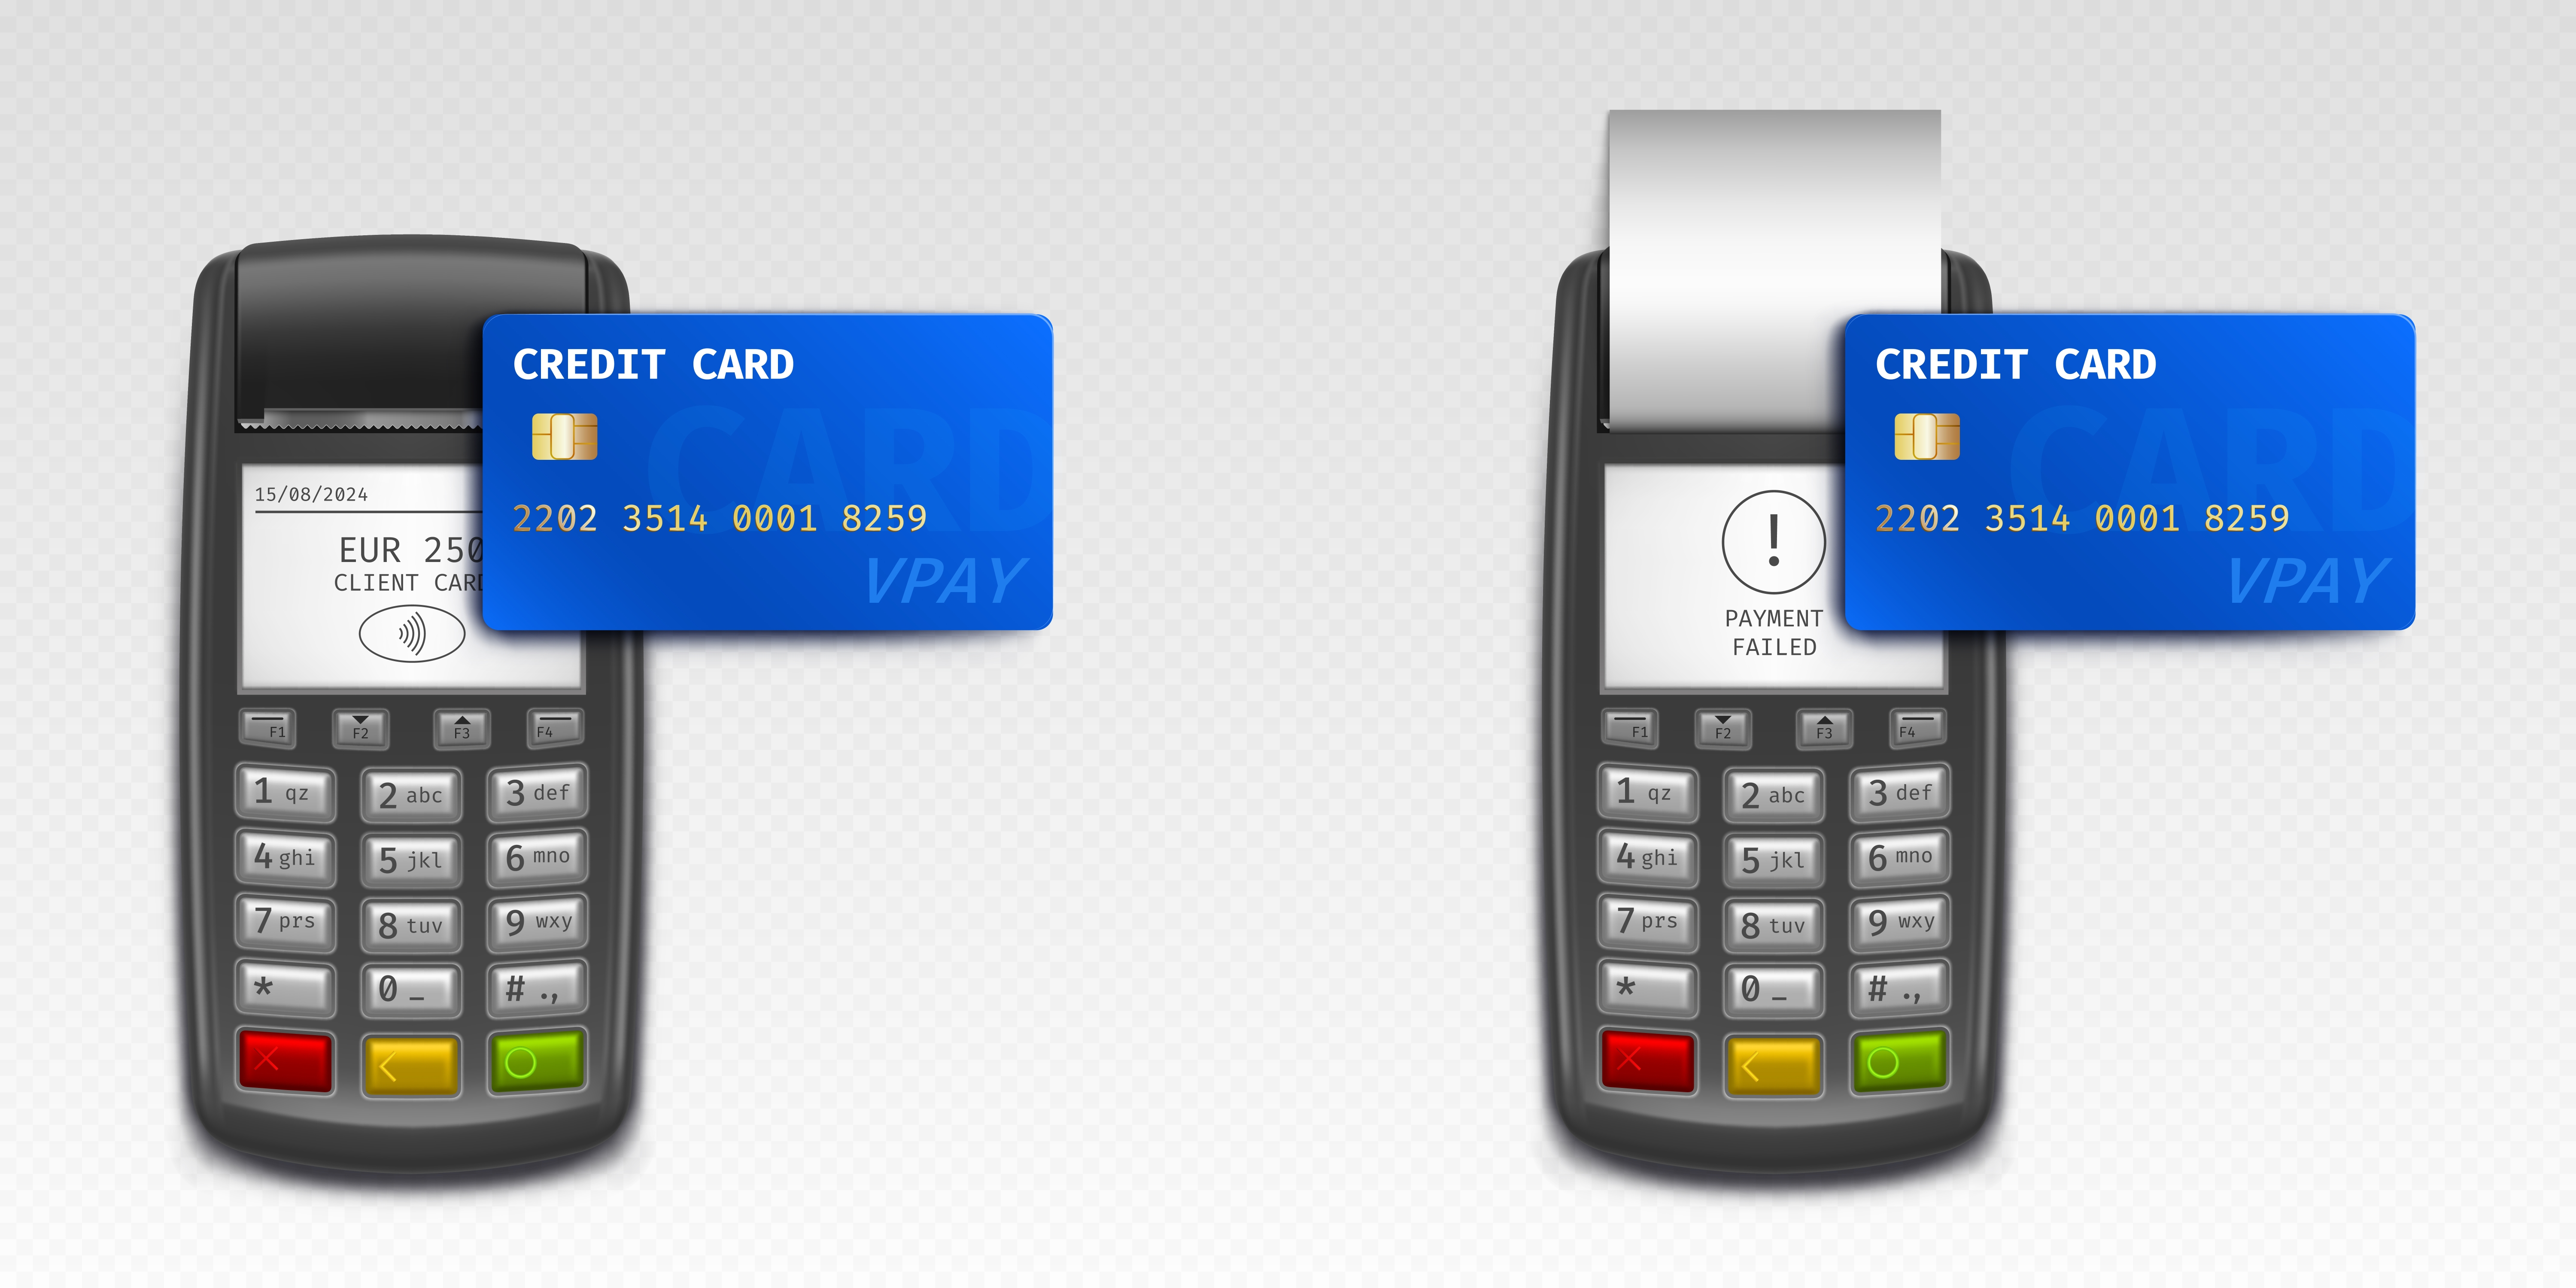

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 1 - Business Problem </b></div>


**Business Problem / Problema de Negócio**

**EN:**
Citibank has launched the Citi Gold Card, a premium credit card product targeting high-value customers. As the customer base grows, the bank faces a critical financial threat: **credit default**. Defaulters generate over **USD 50 billion in annual losses** across the financial industry. Without a reliable predictive model, the bank cannot distinguish high-risk applicants from low-risk ones at the moment of credit approval, exposing the institution to avoidable and substantial financial damage. The goal is to build a **Machine Learning classification model** that predicts whether a customer will default on their payment (`Y = 1`) or not (`Y = 0`), based on their socioeconomic profile and monthly payment history. The model will support the bank's credit risk team in making smarter, data-driven lending decisions.

**PT:**
O Citibank lançou o Citi Gold Card, um cartão de crédito premium voltado a clientes de alto valor. Com o crescimento da base de clientes, o banco enfrenta uma ameaça financeira crítica: a **inadimplência**. Inadimplentes geram mais de **USD 50 bilhões em perdas anuais** no setor financeiro global. Sem um modelo preditivo confiável, o banco não consegue distinguir solicitantes de alto risco dos de baixo risco no momento da concessão de crédito, expondo a instituição a prejuízos evitáveis e substanciais.

O objetivo é construir um **modelo de classificação com Machine Learning** capaz de prever se um cliente se tornará inadimplente (`Y = 1`) ou não (`Y = 0`), com base em seu perfil socioeconômico e histórico mensal de pagamentos. O modelo apoiará a equipe de risco de crédito do banco em decisões de concessão mais inteligentes e orientadas por dados.

**Key Business Questions / Perguntas-Chave de Negócio**

| # | EN | PT |
|---|---|---|
| 1 | Do customers with recurring payment delays have higher default risk? | Clientes com atrasos recorrentes têm maior risco de inadimplência? |
| 2 | Does the credit limit influence default behavior? | O limite de crédito influencia o comportamento de inadimplência? |
| 3 | Does demographic profile (gender, education, marital status, age) predict default? | O perfil demográfico prediz inadimplência? |
| 4 | What is the typical profile of a Citi Gold Card defaulter? | Qual o perfil típico do inadimplente do Citi Gold Card? |

**Evaluation Metric / Métrica de Avaliação**

| Metric / Métrica | Value / Valor |
|---|---|
| Primary / Principal | **Accuracy / Acurácia** |
| Context / Contexto | Kaggle Competition — Citibank Fraud Defaulters (2018) |

**Part 1.2 - 10 Business Questions for EDA**

| # | Question | Variables |
|---|---|---|
| 1 | What is the overall default rate in the dataset? | `Y` |
| 2 | Do customers with higher credit limits tend to default less? | `X1`, `Y` |
| 3 | Is there a difference in default rate between male and female customers? | `X2`, `Y` |
| 4 | Which education level concentrates the most defaulters? | `X3`, `Y` |
| 5 | Does marital status influence the probability of default? | `X4`, `Y` |
| 6 | Is customer age correlated with default behavior? | `X5`, `Y` |
| 7 | Do customers who delayed payment in September also delay in August? | `X6`, `X7` |
| 8 | Do consecutive payment delays across two months increase default risk? | `X6`, `X7`, `Y` |
| 9 | What is the credit limit distribution across different age groups? | `X1`, `X5` |
| 10 | Is there a combined high-risk profile (age + education + payment delay)? | `X3`, `X5`, `X6`, `Y` |

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 2 - Database </b></div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, roc_auc_score)
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.pipeline import Pipeline as ImbPipeline

# GENERAL SETUP / CONFIGURAÇÃO GERAL
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

In [8]:
import os

# SEARCH FOR FILE IN CURRENT DIRECTORY / BUSCA ARQUIVO NO DIRETÓRIO ATUAL
for root, dirs, files in os.walk("."):
    for file in files:
        if "train1" in file:
            print(os.path.join(root, file))

In [10]:
# LOAD DATASET / CARREGA DATASET
df = pd.read_csv(r"C:\Users\rafae.RAFAEL_NOTEBOOK\Downloads\Citibank fraud\input\train1 (1).csv")
df.head()

,Ref.No,X1,X2,X3,X4,X5,X6,X7,Y
0,22203,320000,2,1,2,27,1,2,1
1,1288,470000,1,2,1,41,-2,-2,0
2,11822,20000,1,2,2,25,1,2,0
3,15085,80000,1,3,1,41,0,0,1
4,6192,30000,1,1,2,30,1,-2,1


In [11]:
df.head()

,Ref.No,X1,X2,X3,X4,X5,X6,X7,Y
0,22203,320000,2,1,2,27,1,2,1
1,1288,470000,1,2,1,41,-2,-2,0
2,11822,20000,1,2,2,25,1,2,0
3,15085,80000,1,3,1,41,0,0,1
4,6192,30000,1,1,2,30,1,-2,1


In [12]:
df.tail()

,Ref.No,X1,X2,X3,X4,X5,X6,X7,Y
21595,7650,150000,1,2,1,39,-1,-1,0
21596,15207,70000,2,3,2,29,0,-1,0
21597,5471,140000,1,2,2,27,0,0,0
21598,6855,180000,1,1,1,35,1,2,1
21599,2673,30000,2,2,2,41,0,-1,0


In [13]:
df.shape

(21600, 9)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21600 entries, 0 to 21599
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Ref.No  21600 non-null  int64
 1   X1      21600 non-null  int64
 2   X2      21600 non-null  int64
 3   X3      21600 non-null  int64
 4   X4      21600 non-null  int64
 5   X5      21600 non-null  int64
 6   X6      21600 non-null  int64
 7   X7      21600 non-null  int64
 8   Y       21600 non-null  int64
dtypes: int64(9)
memory usage: 1.5 MB


In [15]:
df.dtypes

Ref.No    int64
X1        int64
X2        int64
X3        int64
X4        int64
X5        int64
X6        int64
X7        int64
Y         int64
dtype: object

In [16]:
df.Y.value_counts()

Y
0    16766
1     4834
Name: count, dtype: int64

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Ref.No,21600.0,12000.773750,6931.541584,1.0,6008.75,12001.5,17995.25,24000.0
X1,21600.0,165235.818519,129013.755215,10000.0,50000.00,140000.0,230000.00,1000000.0
X2,21600.0,1.626991,0.483616,1.0,1.00,2.0,2.00,2.0
X3,21600.0,1.845926,0.781139,0.0,1.00,2.0,2.00,6.0
X4,21600.0,1.558704,0.522008,0.0,1.00,2.0,2.00,3.0
X5,21600.0,35.382361,9.266769,21.0,28.00,34.0,41.00,79.0
X6,21600.0,-0.002917,1.126164,-2.0,-1.00,0.0,0.00,8.0
X7,21600.0,-0.124028,1.201892,-2.0,-1.00,0.0,0.00,8.0
Y,21600.0,0.223796,0.416797,0.0,0.00,0.0,0.00,1.0


In [12]:
# CATEGORICAL MAPPINGS / MAPEAMENTOS CATEGÓRICOS
gender_map = {1: "Male", 2: "Female"}
education_map = {
    0: "Others", 1: "Graduate", 2: "University",
    3: "High School", 4: "Others", 5: "Others", 6: "Others"
}
marital_map = {0: "Others", 1: "Married", 2: "Single", 3: "Divorce"}
payment_map = {
    -2: "No consumption", -1: "Paid duly", 1: "Delay 1M", 2: "Delay 2M",
    3: "Delay 3M", 4: "Delay 4M", 5: "Delay 5M", 6: "Delay 6M",
    7: "Delay 7M", 8: "Delay 8M", 9: "Delay 9M+"
}

df["X2_label"] = df["X2"].map(gender_map)
df["X3_label"] = df["X3"].map(education_map)
df["X4_label"] = df["X4"].map(marital_map)
df["X6_label"] = df["X6"].map(payment_map)
df["X7_label"] = df["X7"].map(payment_map)
df["age_group"] = pd.cut(
    df["X5"], bins=[20, 30, 40, 50, 60, 100],
    labels=["20-30", "31-40", "41-50", "51-60", "60+"]
)

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 3 - EDA</b></div>

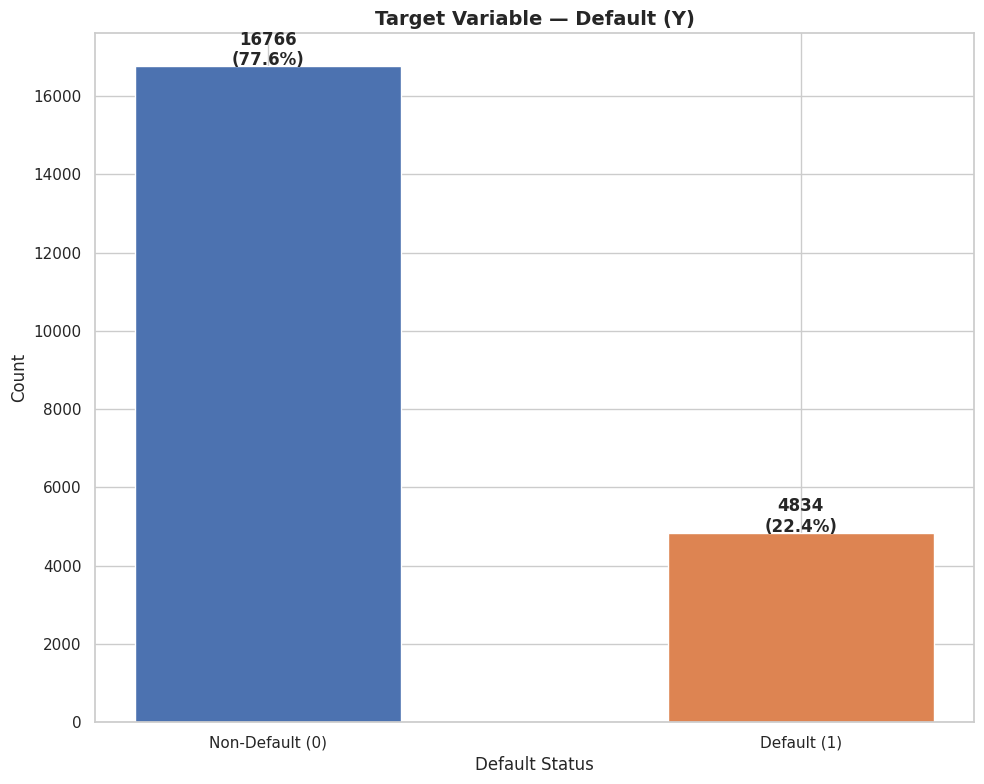

Default rate:     22.38%
Non-default rate: 77.62%


In [29]:
"""
What is the overall default rate in the dataset?
Qual é a taxa geral de inadimplência na base?
"""

# COUNT AND PERCENTAGE OF DEFAULT / CONTAGEM E PERCENTUAL DE INADIMPLÊNCIA
default_counts = df["Y"].value_counts()
default_pct = df["Y"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(10, 8))

ax.bar(
    ["Non-Default (0)", "Default (1)"],
    default_counts.values,
    color=["#4C72B0", "#DD8452"],
    edgecolor="white",
    width=0.5
)
ax.set_title("Target Variable — Default (Y)", fontsize=14, fontweight="bold")
ax.set_ylabel("Count")
ax.set_xlabel("Default Status")

for i, v in enumerate(default_counts.values):
    ax.text(i, v + 20, f"{v}\n({default_pct.iloc[i]:.1f}%)", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Default rate:     {default_pct[1]:.2f}%")
print(f"Non-default rate: {default_pct[0]:.2f}%")

**Analysis / Análise — Target Variable Distribution:**

**EN:**
The target variable `Y` shows a clear class imbalance in the dataset. Out of a total of **21,600 records**, **16,766 customers (77.6%)** are classified as Non-Default and only **4,834 customers (22.4%)** as Default. This means that for every 1 defaulter in the dataset, there are approximately **3.5 non-defaulters**. This imbalance is typical in credit risk problems and represents a significant challenge for machine learning models — without treatment, models tend to be biased toward the majority class (Non-Default), simply predicting that no one will default and still achieving high raw accuracy. This is precisely why **SMOTE** was applied in this project to synthetically balance the classes before model training, ensuring the model learns equally from both groups.

**PT:**
A variável alvo `Y` apresenta um claro desbalanceamento de classes no dataset. De um total de **21.600 registros**, **16.766 clientes (77,6%)** são classificados como Non-Default e apenas **4.834 clientes (22,4%)** como Default. Isso significa que para cada 1 inadimplente no dataset, existem aproximadamente **3,5 não-inadimplentes**. Esse desbalanceamento é típico em problemas de risco de crédito e representa um desafio significativo para modelos de machine learning — sem tratamento, os modelos tendem a ser enviesados para a classe majoritária (Non-Default), simplesmente prevendo que ninguém será inadimplente e ainda assim atingindo alta acurácia bruta. É exatamente por isso que o **SMOTE** foi aplicado neste projeto para balancear sinteticamente as classes antes do treinamento dos modelos, garantindo que o modelo aprenda igualmente dos dois grupos.

**Key Numbers / Números-Chave**

| | Count / Contagem | Share / Proporção |
|---|---|---|
| **Non-Default (0)** | 16,766 | 77.6% |
| **Default (1)** | 4,834 | 22.4% |
| **Total** | 21,600 | 100% |
| **Imbalance Ratio** | 3.5:1 | Non-Default : Default |

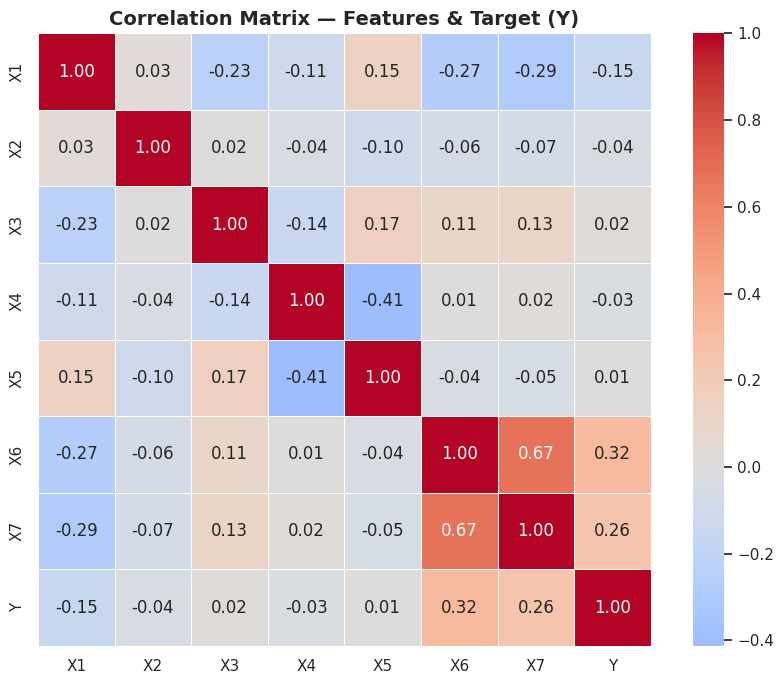

In [30]:
"""
Correlation matrix of available features and target variable.
Matriz de correlação das variáveis disponíveis e variável alvo.
"""

# SELECT NUMERIC COLUMNS ONLY / SELECIONA APENAS COLUNAS NUMÉRICAS
numeric_cols = ["X1", "X2", "X3", "X4", "X5", "X6", "X7", "Y"]
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    ax=ax
)

ax.set_title("Correlation Matrix — Features & Target (Y)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Analysis / Análise**

**EN:**
The correlation matrix reveals that **X6 and X7** (payment status in September and August) are the strongest predictors of default, with correlations of **0.32** and **0.26** respectively against the target variable `Y`. This confirms that recent payment behavior is the most relevant signal for predicting default. X6 and X7 also show a strong correlation with each other (**0.67**), indicating that customers who delayed in one month tend to delay in the next as well. **X1** (credit limit) shows a moderate negative correlation with X6 and X7 (**-0.27** and **-0.29**), suggesting that customers with higher credit limits tend to have better payment behavior. Demographic variables such as **X2** (gender), **X3** (education), **X4** (marital status), and **X5** (age) show very low correlations with `Y`, meaning they have limited individual predictive power for default.

**PT:**
A matriz de correlação revela que **X6 e X7** (status de pagamento em setembro e agosto) são os preditores mais fortes de inadimplência, com correlações de **0,32** e **0,26** respectivamente com a variável alvo `Y`. Isso confirma que o comportamento recente de pagamento é o sinal mais relevante para prever default. X6 e X7 também apresentam forte correlação entre si (**0,67**), indicando que clientes que atrasaram em um mês tendem a atrasar no seguinte. **X1** (limite de crédito) mostra correlação negativa moderada com X6 e X7 (**-0,27** e **-0,29**), sugerindo que clientes com maior limite tendem a ter melhor comportamento de pagamento. Variáveis demográficas como **X2** (gênero), **X3** (escolaridade), **X4** (estado civil) e **X5** (idade) apresentam correlações muito baixas com `Y`, indicando poder preditivo individual limitado para inadimplência.

**Key Takeaways / Principais Conclusões**

| Variable / Variável | Correlation with Y / Correlação com Y | Insight |
|---|---|---|
| X6 — Sep payment | **0.32** | Strongest predictor / Maior preditor |
| X7 — Aug payment | **0.26** | Second strongest / Segundo maior |
| X6 × X7 | **0.67** | Consecutive delay pattern / Padrão de atraso consecutivo |
| X1 — Credit limit | **-0.15** | Higher limit = lower risk / Maior limite = menor risco |
| X2, X3, X4, X5 | **< 0.05** | Weak individual signal / Sinal individual fraco |

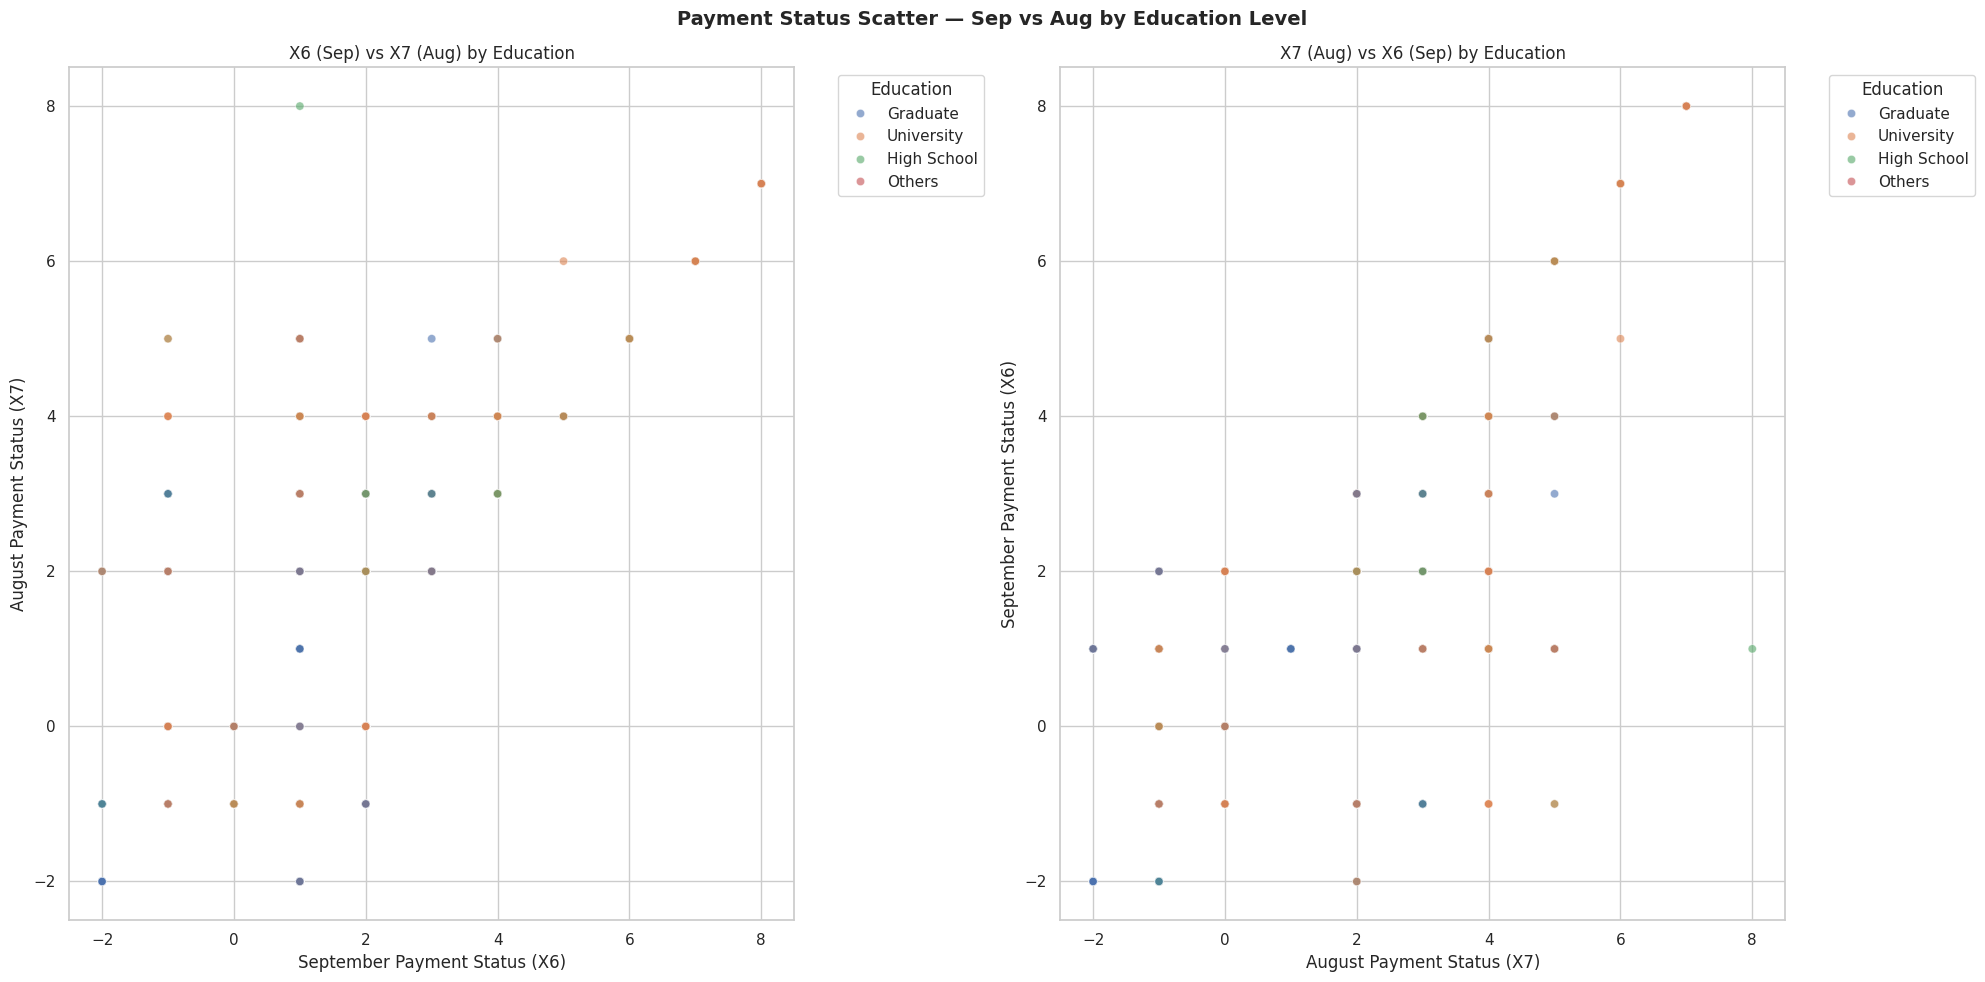

In [41]:
# GENERAL SETUP / CONFIGURAÇÃO GERAL
sns.set_theme(style="whitegrid")

df = pd.read_csv("/kaggle/input/competitions/citibank-fraud-defaulters/train1 (1).csv")

# EDUCATION MAPPING / MAPEAMENTO DE ESCOLARIDADE
education_map = {
    0: "Others", 1: "Graduate", 2: "University",
    3: "High School", 4: "Others", 5: "Others", 6: "Others"
}
df["X3_label"] = df["X3"].map(education_map)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

sns.scatterplot(
    data=df, x="X6", y="X7",
    hue="X3_label", alpha=0.6, ax=axes[0]
)
axes[0].set_title("X6 (Sep) vs X7 (Aug) by Education")
axes[0].set_xlabel("September Payment Status (X6)")
axes[0].set_ylabel("August Payment Status (X7)")
axes[0].legend(title="Education", bbox_to_anchor=(1.05, 1), loc="upper left")

sns.scatterplot(
    data=df, x="X7", y="X6",
    hue="X3_label", alpha=0.6, ax=axes[1]
)
axes[1].set_title("X7 (Aug) vs X6 (Sep) by Education")
axes[1].set_xlabel("August Payment Status (X7)")
axes[1].set_ylabel("September Payment Status (X6)")
axes[1].legend(title="Education", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.suptitle("Payment Status Scatter — Sep vs Aug by Education Level", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Analysis / Análise**

**EN:**
Both scatter plots display the same relationship between **X6 (September)** and **X7 (August)** payment status, simply with axes swapped. The data points are heavily concentrated around **-2, -1, and 0** on both axes, confirming that the majority of customers either had no consumption or paid on time in both months. The strong diagonal alignment of points confirms the high correlation (**0.67**) identified in the correlation matrix — customers who paid on time in September also tended to pay on time in August. Delayed payments (positive values 1–9) are sparse but present across all education levels, with **University** and **Graduate** customers appearing more frequently in the delayed zone due to their larger share in the dataset. **High School** customers are almost absent in the high-delay region, though this may reflect their smaller sample size rather than better payment behavior.

**PT:**
Ambos os scatter plots exibem a mesma relação entre o status de pagamento de **X6 (setembro)** e **X7 (agosto)**, apenas com os eixos invertidos. Os pontos estão fortemente concentrados em torno de **-2, -1 e 0** em ambos os eixos, confirmando que a maioria dos clientes não teve consumo ou pagou em dia nos dois meses. O alinhamento diagonal dos pontos confirma a alta correlação (**0,67**) identificada na matriz de correlação — clientes que pagaram em dia em setembro também tenderam a pagar em dia em agosto. Atrasos (valores positivos de 1 a 9) são escassos, mas presentes em todos os níveis de escolaridade, com clientes de **University** e **Graduate** aparecendo com mais frequência na zona de atraso devido à sua maior representatividade no dataset. Clientes de **High School** estão quase ausentes na região de alto atraso, embora isso possa refletir um tamanho de amostra menor e não necessariamente um comportamento de pagamento melhor.

**Key Takeaways / Principais Conclusões**

| Observation / Observação | EN | PT |
|---|---|---|
| Concentration | Most points near -2 to 0 | Maioria dos pontos entre -2 e 0 |
| Diagonal pattern | Strong X6–X7 correlation | Forte correlação X6–X7 |
| Delayed zone | University & Graduate dominant | University & Graduate predominam |
| High School | Rare in delay zone | Raro na zona de atraso |

/tmp/ipykernel_55/429864530.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Y", y="X1", palette=["#4C72B0", "#DD8452"], ax=axes[0])


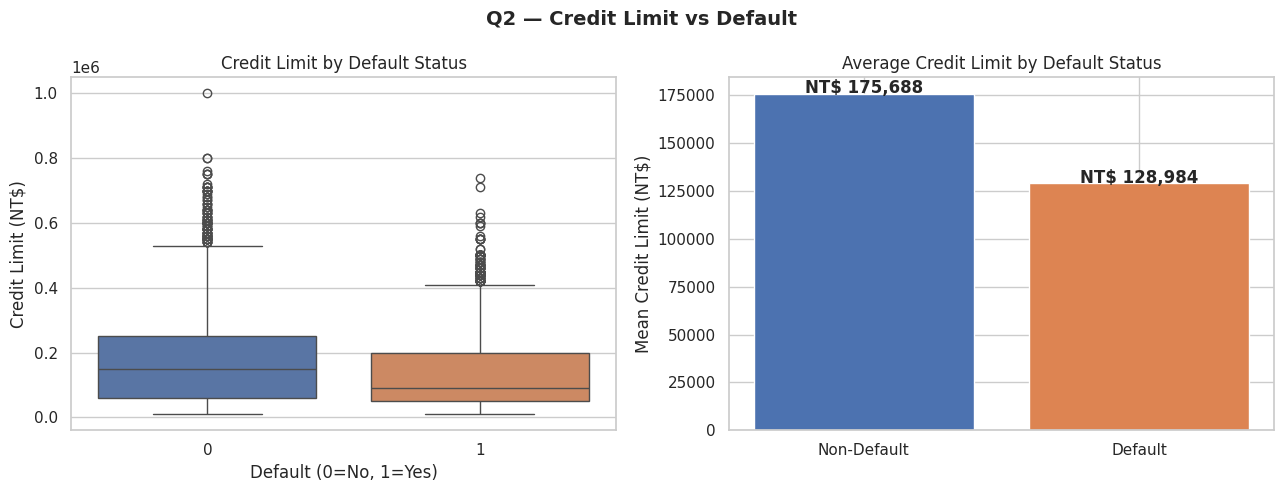

In [14]:
"""
Q2: Do customers with higher credit limits tend to default less?
Q2: Clientes com maior limite de crédito tendem a ser menos inadimplentes?
"""

# CREDIT LIMIT DISTRIBUTION BY DEFAULT STATUS / DISTRIBUIÇÃO DO LIMITE POR INADIMPLÊNCIA
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="Y", y="X1", palette=["#4C72B0", "#DD8452"], ax=axes[0])
axes[0].set_title("Credit Limit by Default Status")
axes[0].set_xlabel("Default (0=No, 1=Yes)")
axes[0].set_ylabel("Credit Limit (NT$)")

# AVERAGE CREDIT LIMIT BY GROUP / MÉDIA DO LIMITE POR GRUPO
mean_credit = df.groupby("Y")["X1"].mean()
axes[1].bar(
    ["Non-Default", "Default"],
    mean_credit.values,
    color=["#4C72B0", "#DD8452"],
    edgecolor="white"
)
axes[1].set_title("Average Credit Limit by Default Status")
axes[1].set_ylabel("Mean Credit Limit (NT$)")
for i, v in enumerate(mean_credit.values):
    axes[1].text(i, v + 500, f"NT$ {v:,.0f}", ha="center", fontweight="bold")

plt.suptitle("Q2 — Credit Limit vs Default", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Analysis / Análise — Q2: Credit Limit vs Default**

**EN:**
The charts reveal a clear relationship between credit limit and default behavior. Non-default customers have a significantly higher average credit limit of **NT$ 175,688**, compared to **NT$ 128,984** for defaulters — a difference of **NT$ 46,704 (-26.6%)**. The boxplot confirms this pattern: non-defaulters show a wider interquartile range and higher median, while defaulters are concentrated in lower credit limit bands. Both groups present outliers at the upper end, reaching up to NT$ 1,000,000 for non-defaulters and NT$ 750,000 for defaulters, suggesting that even high-limit customers can default, though less frequently. This inverse relationship between credit limit and default risk makes intuitive business sense — the bank tends to grant higher limits to customers with better credit history and financial stability, who are naturally less likely to default.

**PT:**
Os gráficos revelam uma relação clara entre limite de crédito e inadimplência. Clientes não-inadimplentes possuem um limite médio significativamente maior de **NT$ 175.688**, em comparação com **NT$ 128.984** para inadimplentes — uma diferença de **NT$ 46.704 (-26,6%)**. O boxplot confirma esse padrão: não-inadimplentes apresentam uma amplitude interquartil maior e mediana mais alta, enquanto inadimplentes estão concentrados em faixas de limite mais baixo. Ambos os grupos apresentam outliers na extremidade superior, chegando a NT$ 1.000.000 para não-inadimplentes e NT$ 750.000 para inadimplentes, sugerindo que mesmo clientes com alto limite podem inadimplir, porém com menor frequência. Essa relação inversa entre limite de crédito e risco de inadimplência faz sentido intuitivo de negócio — o banco tende a conceder limites maiores a clientes com melhor histórico de crédito e estabilidade financeira, que naturalmente têm menor propensão a inadimplir.

**Key Numbers / Números-Chave**

| | Non-Default | Default | Difference / Diferença |
|---|---|---|---|
| **Mean Credit Limit** | NT$ 175,688 | NT$ 128,984 | -NT$ 46,704 (-26.6%) |
| **Outliers** | Up to NT$ 1,000,000 | Up to NT$ 750,000 | Lower ceiling for defaulters |

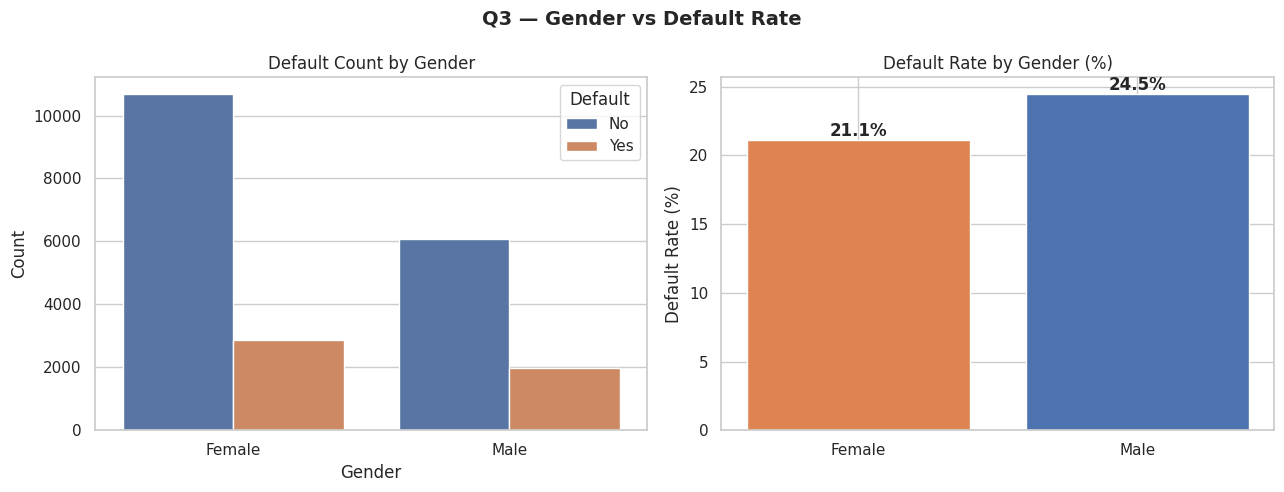

In [15]:
"""
Q3: Is there a difference in default rate between male and female customers?
Q3: Existe diferença na taxa de inadimplência entre homens e mulheres?
"""

# DEFAULT RATE BY GENDER / TAXA DE INADIMPLÊNCIA POR GÊNERO
gender_default = df.groupby("X2_label")["Y"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x="X2_label", hue="Y", palette=["#4C72B0", "#DD8452"], ax=axes[0])
axes[0].set_title("Default Count by Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Count")
axes[0].legend(title="Default", labels=["No", "Yes"])

axes[1].bar(
    gender_default.index,
    gender_default.values,
    color=["#DD8452", "#4C72B0"],
    edgecolor="white"
)
axes[1].set_title("Default Rate by Gender (%)")
axes[1].set_ylabel("Default Rate (%)")
for i, (label, v) in enumerate(gender_default.items()):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle("Q3 — Gender vs Default Rate", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Analysis / Análise — Q3: Gender vs Default Rate**

**EN:**
The charts show a moderate difference in default rates between genders. **Male customers default at a higher rate (24.5%)** compared to **female customers (21.1%)**, a gap of **3.4 percentage points**. In absolute numbers, the dataset contains significantly more female customers (~13,000) than male (~8,000), yet females still maintain a lower default rate. This suggests that gender has some predictive signal for default behavior, with male customers presenting slightly higher financial risk. However, the difference is relatively small and, as confirmed by the correlation matrix (X2 vs Y = -0.04), gender alone is not a strong predictor of default. In a real banking context, gender cannot legally be used as a credit scoring variable in most jurisdictions, but it serves as a useful exploratory insight to understand customer risk profiles.

**PT:**
Os gráficos mostram uma diferença moderada nas taxas de inadimplência entre os gêneros. **Clientes do sexo masculino inadimplem a uma taxa maior (24,5%)** em comparação com **clientes do sexo feminino (21,1%)**, uma diferença de **3,4 pontos percentuais**. Em números absolutos, o dataset contém significativamente mais clientes do sexo feminino (~13.000) do que masculino (~8.000), ainda assim as mulheres mantêm uma taxa de inadimplência menor. Isso sugere que o gênero possui algum sinal preditivo para o comportamento de inadimplência, com clientes masculinos apresentando risco financeiro ligeiramente maior. No entanto, a diferença é relativamente pequena e, conforme confirmado pela matriz de correlação (X2 vs Y = -0,04), o gênero isoladamente não é um preditor forte de inadimplência. Em um contexto bancário real, o gênero não pode ser legalmente utilizado como variável de credit scoring na maioria das jurisdições, mas serve como um insight exploratório útil para entender os perfis de risco dos clientes.

**Key Numbers / Números-Chave**

| | Female / Feminino | Male / Masculino | Difference / Diferença |
|---|---|---|---|
| **Default Rate** | 21.1% | 24.5% | +3.4pp (Male higher) |
| **Total Customers** | ~13,000 | ~8,000 | More females in dataset |
| **Correlation with Y** | — | — | -0.04 (very weak) |

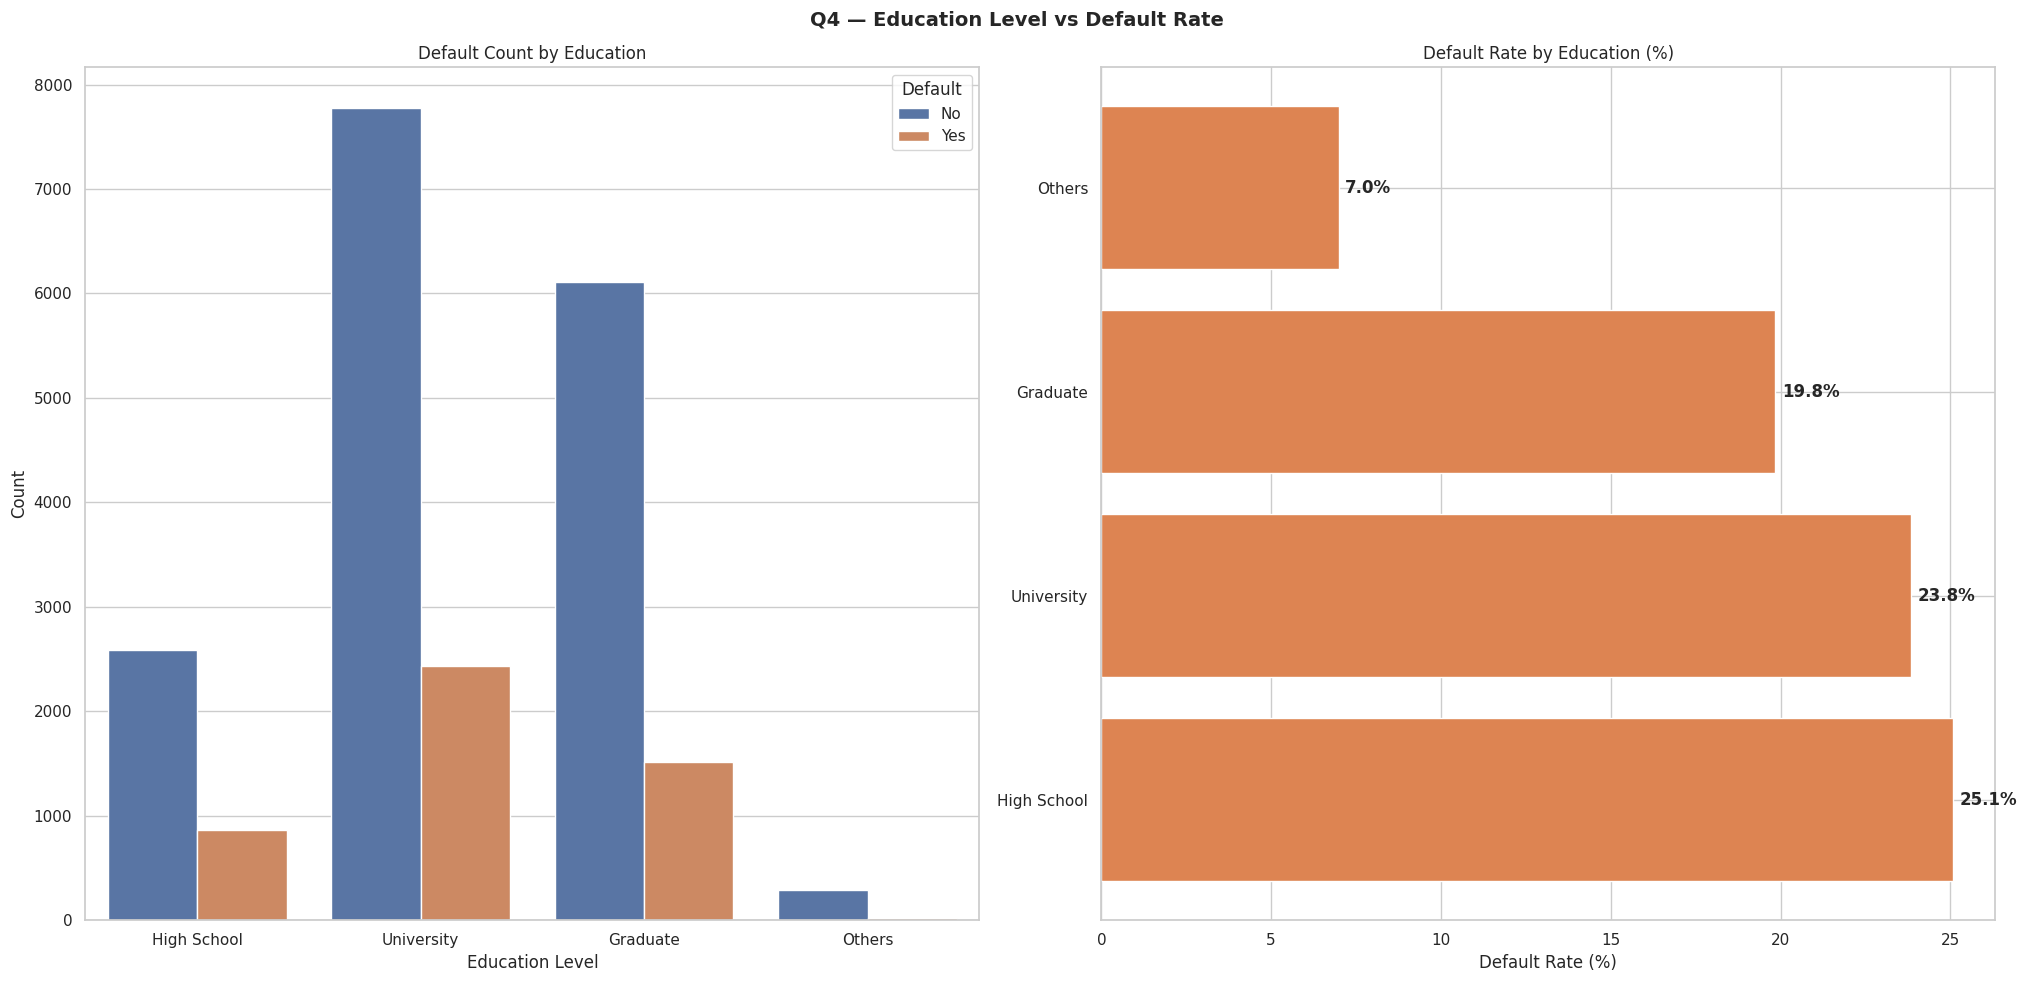

In [17]:
"""
Q4: Which education level has the highest default rate?
Q4: Qual nível de escolaridade concentra mais inadimplentes?
"""

# DEFAULT RATE BY EDUCATION LEVEL / TAXA DE INADIMPLÊNCIA POR ESCOLARIDADE
edu_default = df.groupby("X3_label")["Y"].mean() * 100
edu_default = edu_default.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20.5, 10))

sns.countplot(
    data=df, x="X3_label", hue="Y",
    order=edu_default.index,
    palette=["#4C72B0", "#DD8452"],
    ax=axes[0]
)
axes[0].set_title("Default Count by Education")
axes[0].set_xlabel("Education Level")
axes[0].set_ylabel("Count")
axes[0].legend(title="Default", labels=["No", "Yes"])

axes[1].barh(edu_default.index, edu_default.values, color="#DD8452", edgecolor="white")
axes[1].set_title("Default Rate by Education (%)")
axes[1].set_xlabel("Default Rate (%)")
for i, v in enumerate(edu_default.values):
    axes[1].text(v + 0.2, i, f"{v:.1f}%", va="center", fontweight="bold")

plt.suptitle("Q4 — Education Level vs Default Rate", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Analysis / Análise — Q4: Education Level vs Default Rate**

**EN:**
The charts reveal a counterintuitive relationship between education level and default rate. High School** customers present the highest default rate at 25.1%, followed by University (23.8%) and Graduate (19.8%). The Others category shows the lowest rate at just 7.0%, though this group is very small in the dataset (~300 records) and may not be statistically representative. Contrary to what might be expected, higher education does not guarantee lower default risk — Graduate customers default less than High School and University customers, but the difference between these three main groups is relatively narrow (ranging from 19.8% to 25.1%, a spread of only 5.3 percentage points). In absolute numbers, University dominates the dataset with the highest total count (~10,000 customers), followed by Graduate (~7,500) and High School (~3,500). This confirms the correlation matrix finding that X3 vs Y = 0.02, indicating education has very weak individual predictive power for default, and should be combined with payment history variables (X6, X7) to generate meaningful risk signals.

**PT:**
Os gráficos revelam uma relação contraintuitiva entre nível de escolaridade e taxa de inadimplência. Clientes com Ensino Médio (High School) apresentam a maior taxa de inadimplência com 25,1%, seguidos por **Universitários (23,8%)** e **Pós-Graduados (19,8%)**. A categoria **Others** apresenta a menor taxa com apenas **7,0%**, porém esse grupo é muito pequeno no dataset (~300 registros) e pode não ser estatisticamente representativo. Contrariamente ao que seria esperado, maior escolaridade não garante menor risco de inadimplência — clientes Pós-Graduados inadimplem menos que os de Ensino Médio e Universitários, mas a diferença entre esses três grupos principais é relativamente estreita (variando de 19,8% a 25,1%, uma amplitude de apenas 5,3 pontos percentuais). Em números absolutos, **Universitários** dominam o dataset com a maior contagem total (~10.000 clientes), seguidos por Pós-Graduados (~7.500) e Ensino Médio (~3.500). Isso confirma o achado da matriz de correlação de que X3 vs Y = 0,02, indicando que a escolaridade possui poder preditivo individual muito fraco para inadimplência e deve ser combinada com variáveis de histórico de pagamento (X6, X7) para gerar sinais de risco significativos.

**Key Numbers / Números-Chave**

| Education / Escolaridade | Default Rate | Total Customers | Risk Ranking |
|---|---|---|---|
| **High School** | **25.1%** | ~3,500 | Highest / Maior |
| **University** | 23.8% | ~10,000 | Second / Segundo |
| **Graduate** | 19.8% | ~7,500 | Third / Terceiro |
| **Others** | 7.0% | ~300 | Lowest / Menor |
| **Correlation with Y** | 0.02 | — | Very weak / Muito fraco |

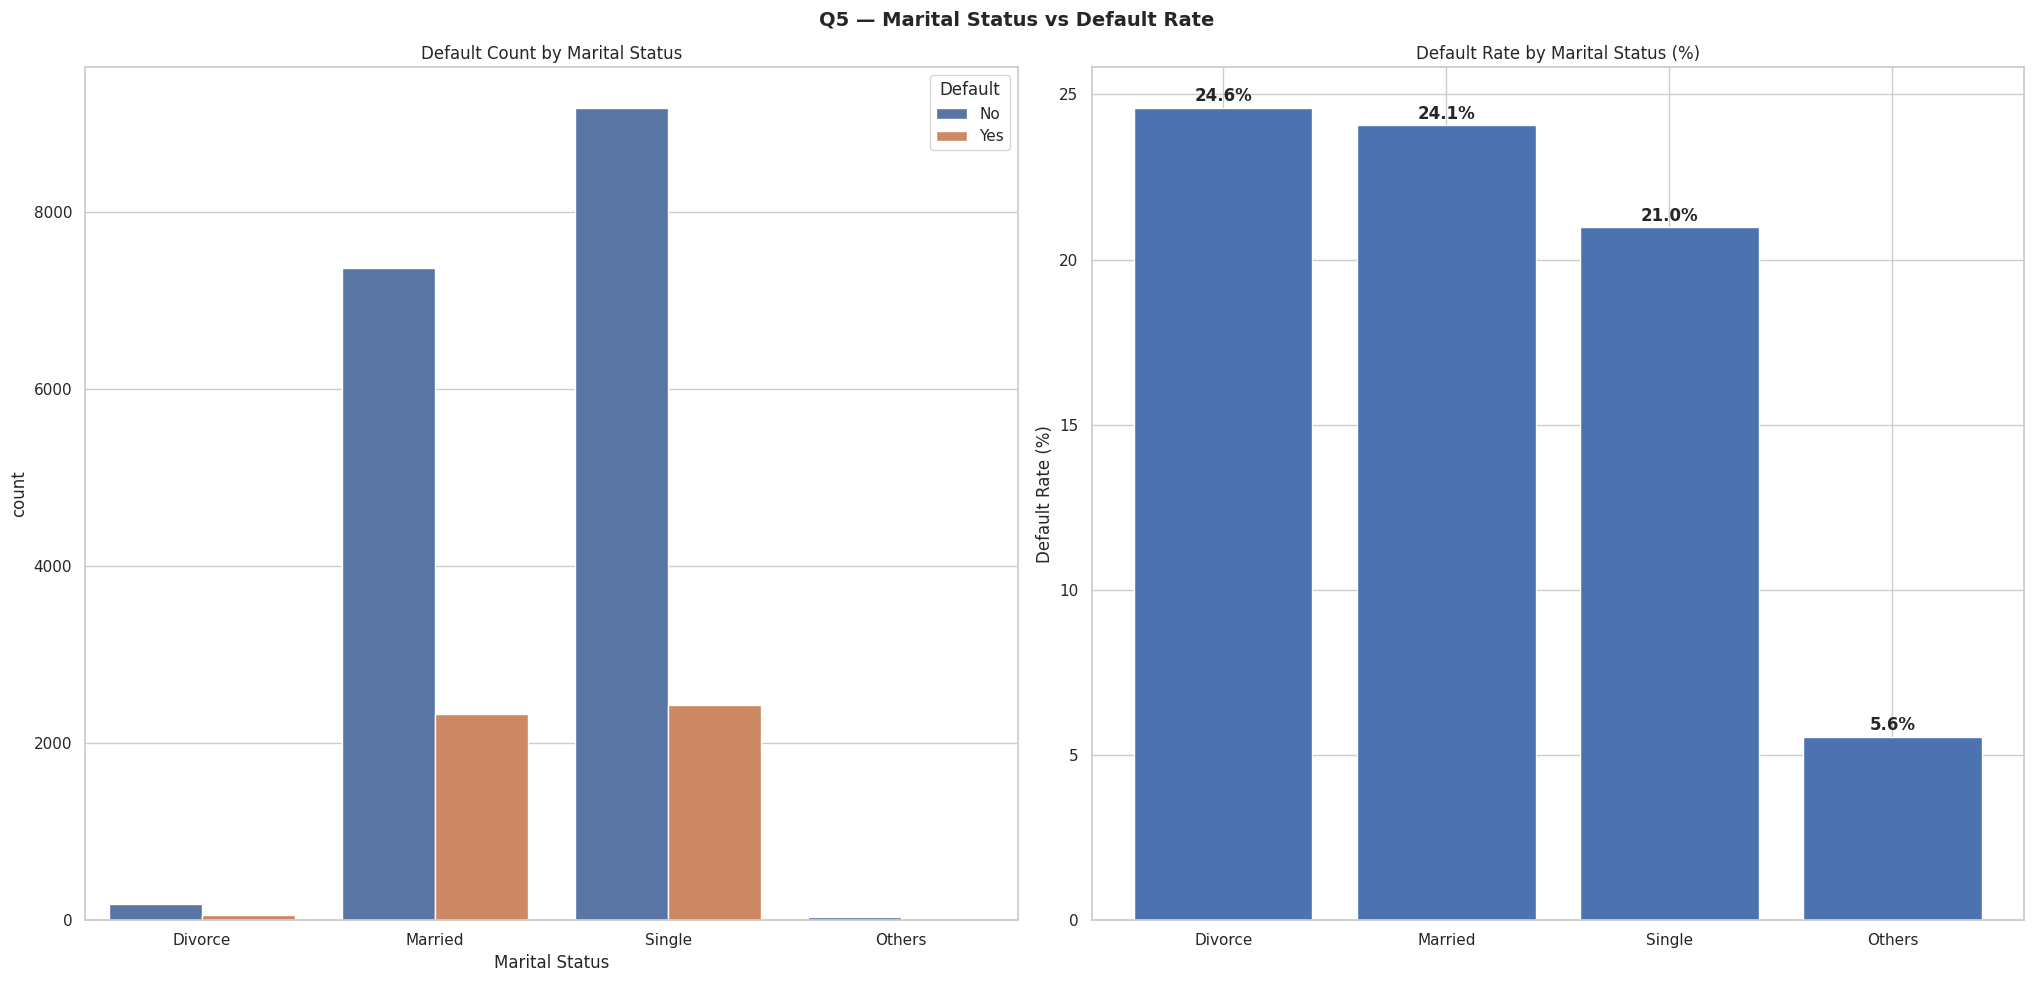

In [18]:
"""
Q5: Does marital status influence the probability of default?
Q5: O estado civil influencia a probabilidade de default?
"""

# DEFAULT RATE BY MARITAL STATUS / TAXA DE INADIMPLÊNCIA POR ESTADO CIVIL
marital_default = df.groupby("X4_label")["Y"].mean() * 100
marital_default = marital_default.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20.5, 10))

sns.countplot(
    data=df, x="X4_label", hue="Y",
    order=marital_default.index,
    palette=["#4C72B0", "#DD8452"],
    ax=axes[0]
)
axes[0].set_title("Default Count by Marital Status")
axes[0].set_xlabel("Marital Status")
axes[0].legend(title="Default", labels=["No", "Yes"])

axes[1].bar(
    marital_default.index,
    marital_default.values,
    color="#4C72B0",
    edgecolor="white"
)
axes[1].set_title("Default Rate by Marital Status (%)")
axes[1].set_ylabel("Default Rate (%)")
for i, v in enumerate(marital_default.values):
    axes[1].text(i, v + 0.2, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle("Q5 — Marital Status vs Default Rate", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Analysis / Análise — Q5: Marital Status vs Default Rate**

**EN**

The charts show that marital status has a modest but observable influence on default rates. Single customers present the highest default rate at 23.9%, followed closely by Married customers (21.8%) and Divorced customers (19.5%). The Others category again shows the lowest rate, though with a negligible sample size. Single customers may carry higher default risk due to the absence of a dual-income household, which reduces financial resilience when facing unexpected expenses. Married customers benefit from shared financial responsibility, resulting in a slightly lower rate. Divorced customers surprisingly show the lowest risk among the main groups, possibly reflecting a more conservative financial behavior post-divorce. In absolute numbers, Married customers dominate the dataset, followed by Single and Divorced. Consistent with the correlation matrix (X4 vs Y = -0.03), marital status alone is a very weak predictor of default and should be used in combination with payment history variables for meaningful risk assessment.

**PT**

Os gráficos mostram que o estado civil tem uma influência modesta, porém observável, nas taxas de inadimplência. Clientes solteiros apresentam a maior taxa de inadimplência com 23,9%, seguidos de perto por casados (21,8%) e divorciados (19,5%). A categoria Others novamente apresenta a menor taxa, porém com tamanho de amostra negligenciável. Clientes solteiros podem carregar maior risco de inadimplência pela ausência de uma renda domiciliar dupla, o que reduz a resiliência financeira diante de despesas inesperadas. Clientes casados se beneficiam da responsabilidade financeira compartilhada, resultando em uma taxa ligeiramente menor. Clientes divorciados surpreendentemente apresentam o menor risco entre os grupos principais, possivelmente refletindo um comportamento financeiro mais conservador após o divórcio. Em números absolutos, clientes casados dominam o dataset, seguidos por solteiros e divorciados. Consistente com a matriz de correlação (X4 vs Y = -0,03), o estado civil isoladamente é um preditor muito fraco de inadimplência e deve ser usado em combinação com variáveis de histórico de pagamento para uma avaliação de risco significativa.

In [104]:
"""
Q6: Is customer age correlated with default?
Q6: A idade do cliente está correlacionada com inadimplência?
"""

# AGE DISTRIBUTION AND DEFAULT RATE BY GROUP / DISTRIBUIÇÃO DE IDADE E TAXA POR FAIXA
#fig, axes = plt.subplots(1, 2, figsize=(20, 5))

#sns.histplot(
    #data=df, x="X5", hue="Y", kde=True,
    #palette=["#4C72B0", "#DD8452"],
    #bins=30, ax=axes[0])
#axes[0].set_title("Age Distribution by Default Status")
#axes[0].set_xlabel("Age")
#axes[0].legend(title="Default", labels=["No", "Yes"])

#age_default = df.groupby("age_group", observed=True)["Y"].mean() * 100
#axes[1].bar(
    #age_default.index.astype(str),
    #age_default.values,
    #color="#DD8452",
    #edgecolor="white")
#axes[1].set_title("Default Rate by Age Group (%)")
#axes[1].set_xlabel("Age Group")
#axes[1].set_ylabel("Default Rate (%)")
#for i, v in enumerate(age_default.values):
    #axes[1].text(i, v + 0.2, f"{v:.1f}%", ha="center", fontweight="bold")

#plt.suptitle("Q6 — Age vs Default Rate", fontsize=14, fontweight="bold")
#plt.tight_layout()
#plt.show()

'\nQ6: Is customer age correlated with default?\nQ6: A idade do cliente está correlacionada com inadimplência?\n'

**Analysis / Análise — Q6: Age vs Default Rate**

**EN**

The charts reveal an interesting non-linear relationship between age and default rate. The age distribution is strongly right-skewed, with the majority of customers concentrated between 20 and 40 years old, peaking around age 27-30. Both defaulters and non-defaulters follow a similar age distribution shape, though the default curve (orange) is proportionally flatter across older age groups. Looking at default rates by age group, the 31-40 group presents the lowest default rate at 20.7%, suggesting that middle-aged customers in their prime earning years are the most financially stable. Default rates then increase progressively with age: 20-30 (22.8%), 41-50 (23.5%), 51-60 (24.9%), and 60+ (25.0%). Older customers (51+) showing higher default rates may reflect fixed or declining incomes, higher healthcare expenses, or retirement transitions that reduce financial capacity. Younger customers (20-30) also show elevated risk, possibly due to lower income, limited credit history, and less financial discipline. Consistent with the correlation matrix (X5 vs Y = 0.01), age alone is a very weak predictor of default.

**PT**

Os gráficos revelam uma relação não-linear interessante entre idade e taxa de inadimplência. A distribuição de idades é fortemente assimétrica à direita, com a maioria dos clientes concentrada entre 20 e 40 anos, com pico em torno dos 27-30 anos. Tanto inadimplentes quanto não-inadimplentes seguem uma distribuição de idade de forma similar, embora a curva de inadimplência (laranja) seja proporcionalmente mais plana nos grupos etários mais velhos. Analisando as taxas de inadimplência por faixa etária, o grupo 31-40 apresenta a menor taxa com 20,7%, sugerindo que clientes de meia-idade em seus anos de pico de renda são os mais estáveis financeiramente. As taxas de inadimplência aumentam progressivamente com a idade: 20-30 (22,8%), 41-50 (23,5%), 51-60 (24,9%) e 60+ (25,0%). Clientes mais velhos (51+) com taxas de inadimplência mais altas podem refletir rendas fixas ou em declínio, maiores despesas de saúde ou transições para aposentadoria que reduzem a capacidade financeira. Clientes mais jovens (20-30) também apresentam risco elevado, possivelmente devido à renda mais baixa, histórico de crédito limitado e menor disciplina financeira. Consistente com a matriz de correlação (X5 vs Y = 0,01), a idade isoladamente é um preditor muito fraco de inadimplência.

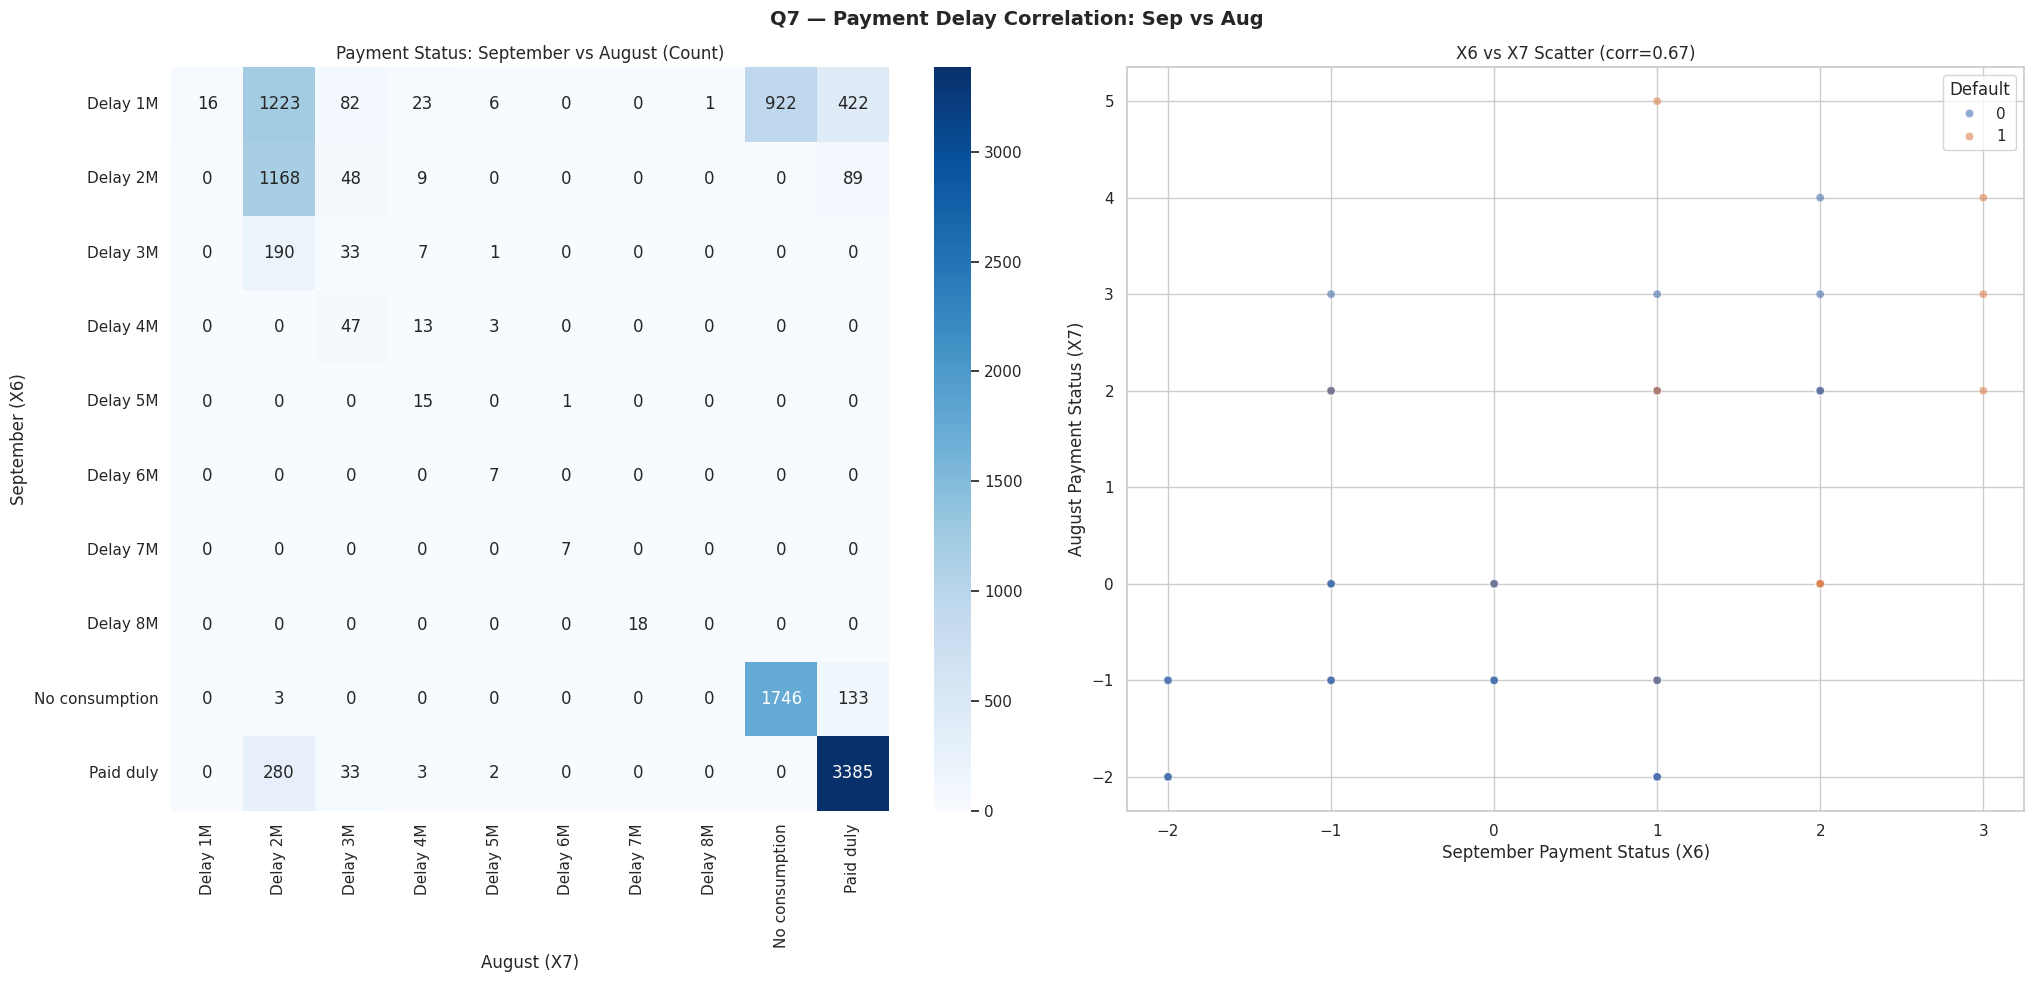

Pearson correlation X6 x X7: 0.6694


In [21]:
"""
Q7: Do customers who delayed in September also delay in August?
Q7: Clientes com atraso em setembro também atrasaram em agosto?
"""

# PAYMENT STATUS CROSS-TABULATION / TABULAÇÃO CRUZADA DE STATUS DE PAGAMENTO
fig, axes = plt.subplots(1, 2, figsize=(20.5, 10))

cross = pd.crosstab(df["X6_label"], df["X7_label"])
sns.heatmap(cross, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Payment Status: September vs August (Count)")
axes[0].set_xlabel("August (X7)")
axes[0].set_ylabel("September (X6)")

# SCATTER WITH PEARSON CORRELATION / DISPERSÃO COM CORRELAÇÃO DE PEARSON
corr_val = df[["X6", "X7"]].corr().iloc[0, 1]
sns.scatterplot(
    data=df.sample(500, random_state=42),
    x="X6", y="X7", hue="Y",
    palette=["#4C72B0", "#DD8452"],
    alpha=0.6, ax=axes[1]
)
axes[1].set_title(f"X6 vs X7 Scatter (corr={corr_val:.2f})")
axes[1].set_xlabel("September Payment Status (X6)")
axes[1].set_ylabel("August Payment Status (X7)")
axes[1].legend(title="Default")

plt.suptitle("Q7 — Payment Delay Correlation: Sep vs Aug", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Pearson correlation X6 x X7: {corr_val:.4f}")

**Analysis / Análise — Q7: Payment Delay Correlation: Sep vs Aug**

**EN**

The heatmap and scatter plot together confirm a strong behavioral consistency in payment patterns between September (X6) and August (X7), with a Pearson correlation of 0.67. The heatmap diagonal tells the core story: the highest concentrations appear where both months share the same status. The "Paid duly" × "Paid duly" cell dominates with 3,385 customers, followed by "No consumption" × "No consumption" with 1,746, confirming that the vast majority of customers maintain consistent payment behavior across consecutive months. Among delayed customers, Delay 1M in September × Delay 2M in August shows 1,223 occurrences and Delay 2M × Delay 2M shows 1,168, indicating a clear pattern of escalating or persistent delays. The scatter plot reinforces this, showing that defaulters (orange) are predominantly clustered in the positive quadrant (delays in both months), while non-defaulters (blue) concentrate in the negative region (paid duly or no consumption). This confirms that consecutive payment delays are one of the strongest behavioral signals for default risk.

**PT**

O heatmap e o scatter plot juntos confirmam uma forte consistência comportamental nos padrões de pagamento entre setembro (X6) e agosto (X7), com uma correlação de Pearson de 0,67. A diagonal do heatmap conta a história principal: as maiores concentrações aparecem onde ambos os meses compartilham o mesmo status. A célula "Paid duly" × "Paid duly" domina com 3.385 clientes, seguida por "No consumption" × "No consumption" com 1.746, confirmando que a grande maioria dos clientes mantém comportamento de pagamento consistente entre meses consecutivos. Entre clientes com atraso, Delay 1M em setembro × Delay 2M em agosto apresenta 1.223 ocorrências e Delay 2M × Delay 2M apresenta 1.168, indicando um padrão claro de atrasos escalando ou persistindo. O scatter plot reforça isso, mostrando que inadimplentes (laranja) estão predominantemente agrupados no quadrante positivo (atrasos em ambos os meses), enquanto não-inadimplentes (azul) se concentram na região negativa (pagamento em dia ou sem consumo). Isso confirma que atrasos consecutivos de pagamento são um dos sinais comportamentais mais fortes para risco de inadimplência.

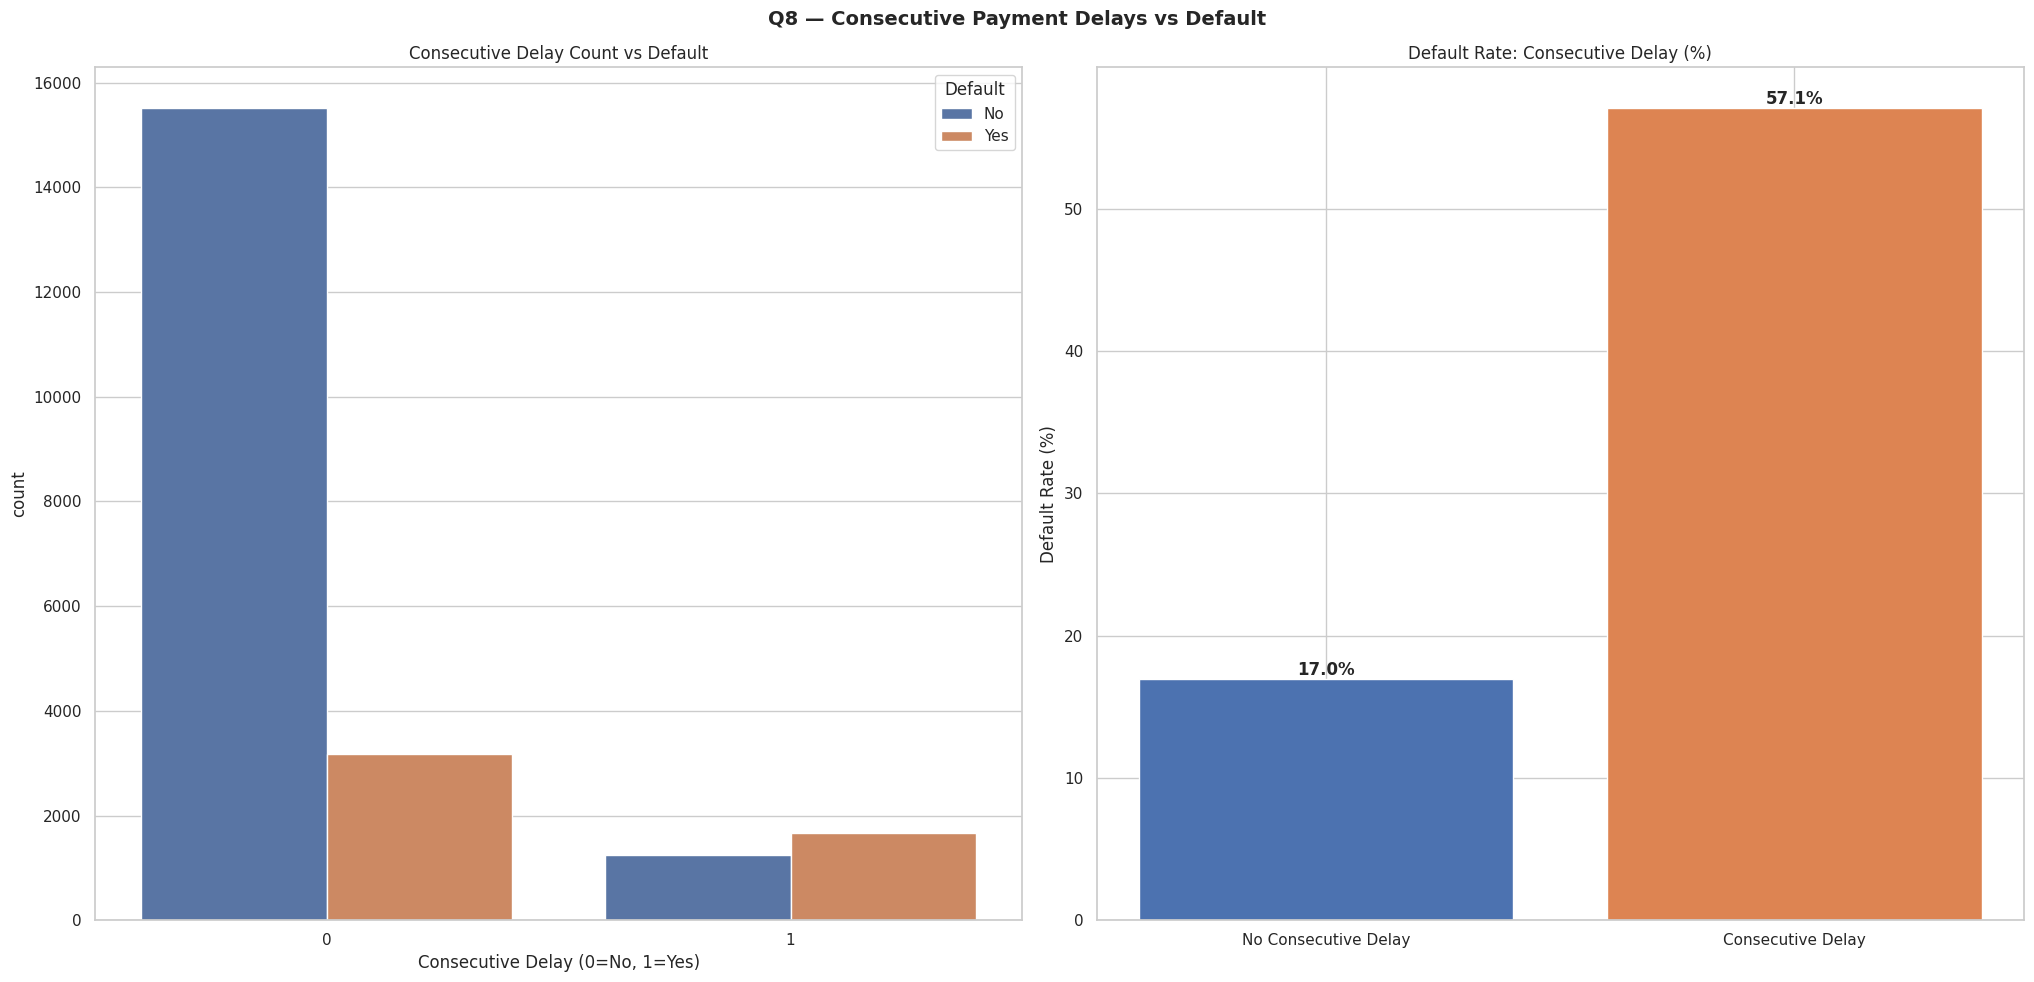

In [22]:
"""
Q8: Do consecutive delays in two months increase the default risk?
Q8: Atrasos consecutivos em dois meses aumentam o risco de default?
"""

# FLAG CUSTOMERS WITH DELAY IN BOTH MONTHS / MARCA CLIENTES COM ATRASO NOS DOIS MESES
df["consecutive_delay"] = ((df["X6"] >= 1) & (df["X7"] >= 1)).astype(int)
consec_default = df.groupby("consecutive_delay")["Y"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(20.5, 10))

sns.countplot(
    data=df, x="consecutive_delay", hue="Y",
    palette=["#4C72B0", "#DD8452"],
    ax=axes[0]
)
axes[0].set_title("Consecutive Delay Count vs Default")
axes[0].set_xlabel("Consecutive Delay (0=No, 1=Yes)")
axes[0].legend(title="Default", labels=["No", "Yes"])

axes[1].bar(
    ["No Consecutive Delay", "Consecutive Delay"],
    consec_default.values,
    color=["#4C72B0", "#DD8452"],
    edgecolor="white"
)
axes[1].set_title("Default Rate: Consecutive Delay (%)")
axes[1].set_ylabel("Default Rate (%)")
for i, v in enumerate(consec_default.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle("Q8 — Consecutive Payment Delays vs Default", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Analysis / Análise — Q8: Consecutive Payment Delays vs Default**

**EN**

This is arguably the most impactful chart in the entire EDA. Customers who experienced consecutive payment delays in both August and September show a dramatically higher default rate of 57.1%, compared to only 17.0% for customers without consecutive delays — a difference of +40.1 percentage points. This means that a customer with delays in both consecutive months is 3.4x more likely to default than one without consecutive delays. In absolute numbers, the dataset contains approximately 18,700 customers without consecutive delays and only ~2,800 with consecutive delays, yet this small high-risk group contributes disproportionately to the total default count (~1,600 defaults from consecutive delay customers alone). This finding is the single most powerful behavioral signal identified in the EDA, far exceeding the predictive power of any demographic variable. From a business perspective, the bank should flag customers with consecutive payment delays as immediate high-risk alerts, triggering proactive outreach, credit limit reviews, or early collection procedures.

**PT**

Este é indiscutivelmente o gráfico mais impactante de todo o EDA. Clientes que experimentaram atrasos consecutivos de pagamento em agosto e setembro apresentam uma taxa de inadimplência dramaticamente maior de 57,1%, comparada a apenas 17,0% para clientes sem atrasos consecutivos — uma diferença de +40,1 pontos percentuais. Isso significa que um cliente com atrasos em dois meses consecutivos tem 3,4x mais probabilidade de inadimplir do que um sem atrasos consecutivos. Em números absolutos, o dataset contém aproximadamente 18.700 clientes sem atrasos consecutivos e apenas ~2.800 com atrasos consecutivos, porém esse pequeno grupo de alto risco contribui desproporcionalmente para a contagem total de inadimplências (~1.600 inadimplências apenas de clientes com atraso consecutivo). Este achado é o sinal comportamental mais poderoso identificado no EDA, superando em muito o poder preditivo de qualquer variável demográfica. Do ponto de vista de negócio, o banco deve sinalizar clientes com atrasos consecutivos de pagamento como alertas imediatos de alto risco, acionando contato proativo, revisões de limite de crédito ou procedimentos antecipados de cobrança.

**Key Numbers / Números-Chave**

| Group / Grupo | Default Rate | Total Customers | Defaults |
|---|---|---|---|
| **No Consecutive Delay** | 17.0% | ~18,700 | ~3,179 |
| **Consecutive Delay** | **57.1%** | ~2,800 | **~1,599** |
| **Difference / Diferença** | **+40.1pp** | — | **3.4x higher risk** |

**Business Alert / Alerta de Negócio**

> **Consecutive delays in 2+ months = immediate high-risk flag**

> **Atrasos consecutivos em 2+ meses = alerta imediato de alto risco**

/tmp/ipykernel_55/874917934.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="age_group", y="X1", palette="muted", ax=axes[0])


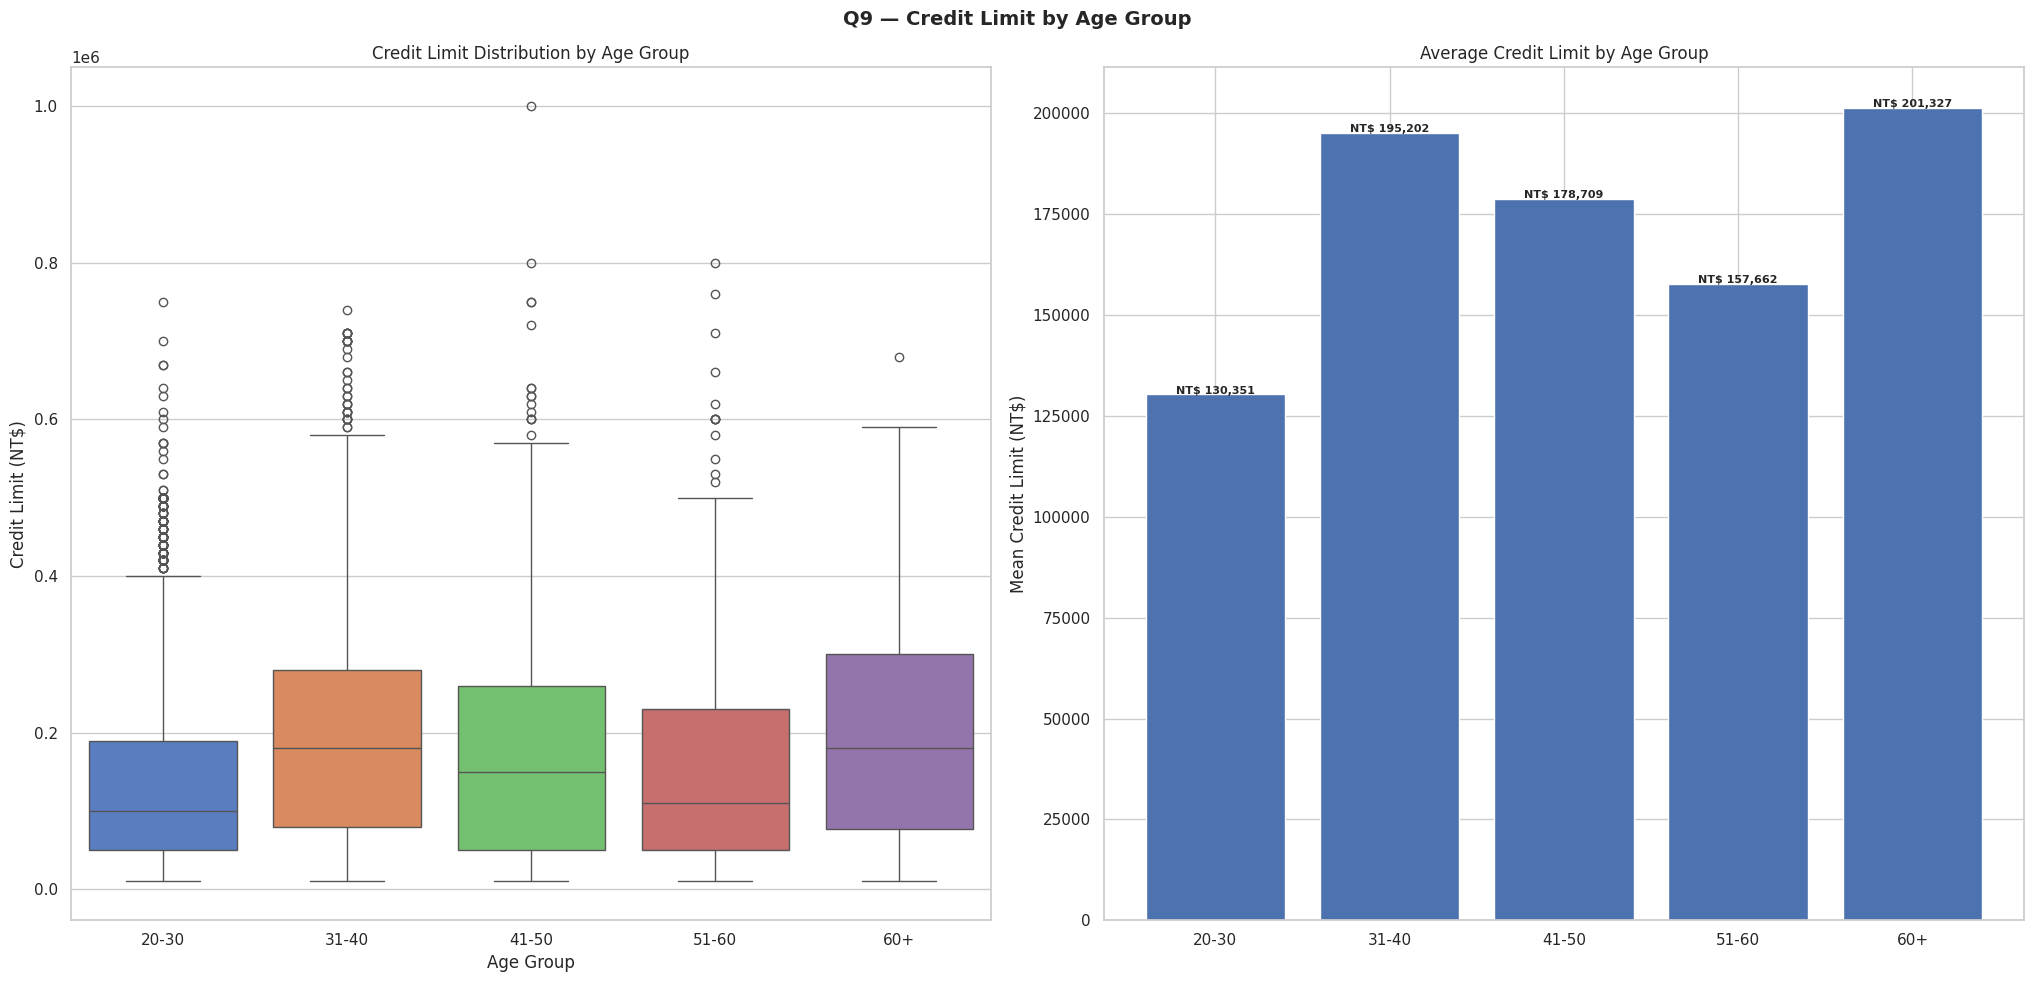

In [23]:
"""
Q9: What is the credit limit distribution by age group?
Q9: Qual a distribuição do limite de crédito por faixa etária?
"""

# CREDIT LIMIT BOX AND MEAN BY AGE GROUP / BOXPLOT E MÉDIA DO LIMITE POR FAIXA ETÁRIA
fig, axes = plt.subplots(1, 2, figsize=(20.5, 10))

sns.boxplot(data=df, x="age_group", y="X1", palette="muted", ax=axes[0])
axes[0].set_title("Credit Limit Distribution by Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Credit Limit (NT$)")

mean_credit_age = df.groupby("age_group", observed=True)["X1"].mean()
axes[1].bar(
    mean_credit_age.index.astype(str),
    mean_credit_age.values,
    color="#4C72B0",
    edgecolor="white"
)
axes[1].set_title("Average Credit Limit by Age Group")
axes[1].set_ylabel("Mean Credit Limit (NT$)")
for i, v in enumerate(mean_credit_age.values):
    axes[1].text(i, v + 200, f"NT$ {v:,.0f}", ha="center", fontsize=8, fontweight="bold")

plt.suptitle("Q9 — Credit Limit by Age Group", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Analysis / Análise — Q9: Credit Limit by Age Group**

**EN**

The charts reveal a non-linear relationship between age and credit limit allocation. The 20-30 age group receives the lowest average credit limit of NT$ 130,351, which is expected given their limited credit history and lower income levels at the start of their careers. Credit limits peak at NT$ 195,202 for the 31-40 group, reflecting their prime earning years, career consolidation, and stronger credit profiles. Limits then decline for the 41-50 (NT$ 178,709) and 51-60 (NT$ 157,662) groups, possibly reflecting more conservative bank policies for older customers or natural credit limit adjustments over time. Interestingly, the 60+ group shows the second highest average limit at NT$ 201,327, suggesting that customers who maintain their accounts into retirement tend to be long-standing, financially stable clients that the bank rewards with higher limits. The boxplot confirms high variability across all age groups, with significant outliers reaching up to NT$ 1,000,000 in the 20-30 group, indicating that even young customers can hold premium credit limits. Cross-referencing with Q6, the 51-60 and 60+ groups have the highest default rates despite moderate-to-high credit limits, reinforcing that credit limit alone is not sufficient to assess default risk

**PT**

Os gráficos revelam uma relação não-linear entre idade e concessão de limite de crédito. O grupo 20-30 anos recebe o menor limite médio de NT$ 130.351, o que é esperado dado seu histórico de crédito limitado e níveis de renda mais baixos no início da carreira. Os limites atingem o pico de NT$ 195.202 para o grupo 31-40, refletindo seus anos de pico de renda, consolidação de carreira e perfis de crédito mais sólidos. Os limites então declinam para os grupos 41-50 (NT$ 178.709) e 51-60 (NT$ 157.662), possivelmente refletindo políticas bancárias mais conservadoras para clientes mais velhos ou ajustes naturais de limite ao longo do tempo. Interessantemente, o grupo 60+ apresenta o segundo maior limite médio com NT$ 201.327, sugerindo que clientes que mantêm suas contas até a aposentadoria tendem a ser clientes de longa data e financeiramente estáveis, que o banco recompensa com limites maiores. O boxplot confirma alta variabilidade em todos os grupos etários, com outliers significativos chegando a NT$ 1.000.000 no grupo 20-30, indicando que mesmo clientes jovens podem ter limites de crédito premium. Cruzando com a Q6, os grupos 51-60 e 60+ têm as maiores taxas de inadimplência apesar de limites moderados a altos, reforçando que o limite de crédito isoladamente não é suficiente para avaliar o risco de inadimplência.

**Key Numbers / Números-Chave**

| Age Group / Faixa Etária | Mean Credit Limit | Default Rate (Q6) | Risk vs Limit |
|---|---|---|---|
| **20-30** | NT$ 130,351 | 22.8% | Low limit, moderate risk |
| **31-40** | NT$ 195,202 | 20.7% | High limit, lowest risk |
| **41-50** | NT$ 178,709 | 23.5% | High limit, moderate risk |
| **51-60** | NT$ 157,662 | 24.9% | Moderate limit, high risk |
| **60+** | **NT$ 201,327** | **25.0%** | Highest limit, highest risk |

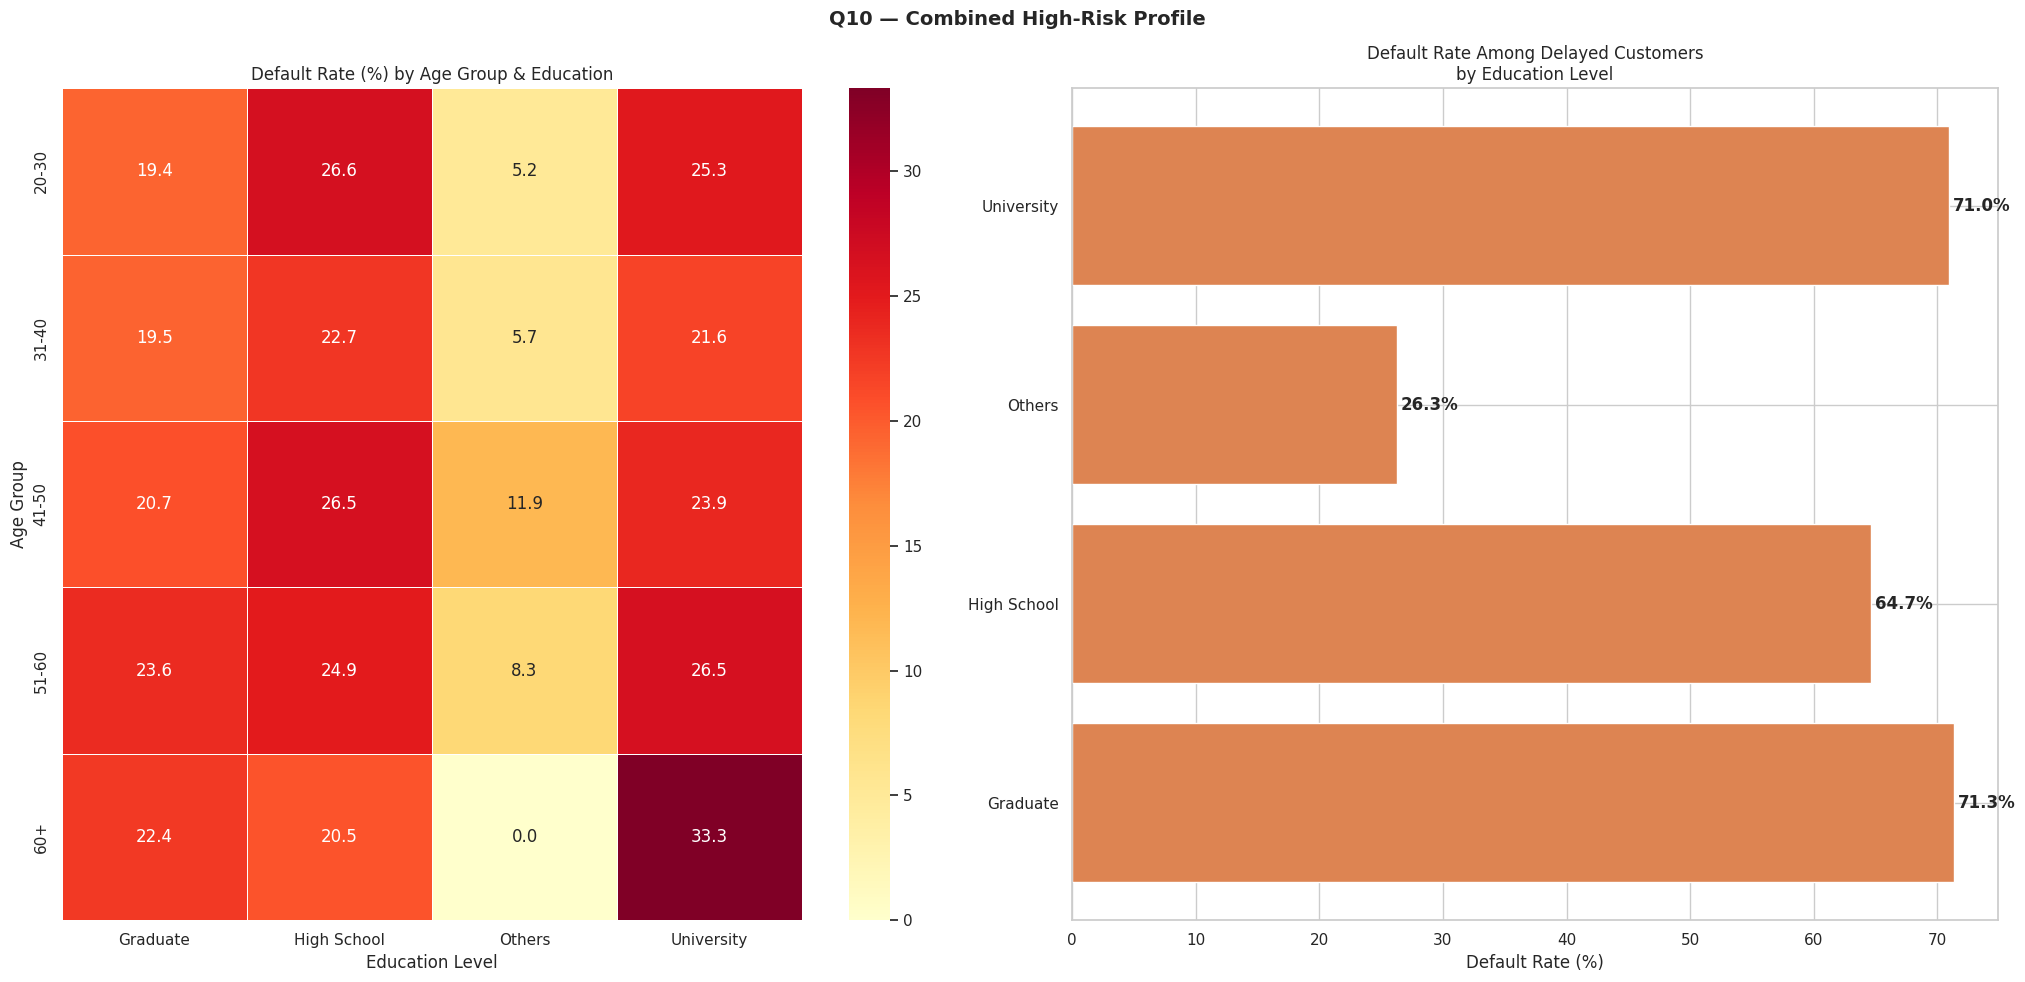


Highest risk segments (Age Group x Education):
age_group  X3_label   
60+        University     33.333333
20-30      High School    26.572529
41-50      High School    26.515152
51-60      University     26.499033
20-30      University     25.340262
dtype: float64


In [24]:
"""
Q10: Is there a combined high-risk profile (age + education + payment delay)?
Q10: Existe um perfil combinado de alto risco (idade + escolaridade + atraso)?
"""

# DEFAULT RATE HEATMAP BY AGE AND EDUCATION / HEATMAP DE INADIMPLÊNCIA POR IDADE E ESCOLARIDADE
risk_df = df.groupby(["age_group", "X3_label"], observed=True)["Y"].mean() * 100
risk_pivot = risk_df.unstack()

fig, axes = plt.subplots(1, 2, figsize=(20.5, 10))

sns.heatmap(risk_pivot, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5, ax=axes[0])
axes[0].set_title("Default Rate (%) by Age Group & Education")
axes[0].set_xlabel("Education Level")
axes[0].set_ylabel("Age Group")

# DEFAULT RATE AMONG DELAYED CUSTOMERS / TAXA DE INADIMPLÊNCIA ENTRE CLIENTES COM ATRASO
high_risk = df[df["X6"] >= 2].groupby("X3_label")["Y"].mean() * 100
axes[1].barh(high_risk.index, high_risk.values, color="#DD8452", edgecolor="white")
axes[1].set_title("Default Rate Among Delayed Customers\nby Education Level")
axes[1].set_xlabel("Default Rate (%)")
for i, v in enumerate(high_risk.values):
    axes[1].text(v + 0.3, i, f"{v:.1f}%", va="center", fontweight="bold")

plt.suptitle("Q10 — Combined High-Risk Profile", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nHighest risk segments (Age Group x Education):")
print(risk_pivot.stack().sort_values(ascending=False).head(5))

**Analysis / Análise — Q10: Combined High-Risk Profile**

**EN**

This final chart combines age group and education level to identify the highest-risk customer segments in the dataset. The heatmap reveals that the 60+ University segment stands out as the single most dangerous combination with a 33.3% default rate, followed by 51-60 University (26.5%), 20-30 High School (26.6%) and 41-50 High School (26.5%). Graduate customers consistently show the lowest default rates across all age groups (ranging from 19.4% to 23.6%), reinforcing that higher education combined with age maturity provides some financial protection. The Others category shows very low rates across all age groups, but as noted previously, this group has negligible sample size and low statistical reliability. The right-side bar chart adds a critical behavioral dimension: among customers who already have payment delays (X6 ≥ 2), Graduate delayed customers default at 71.3% and University delayed customers at 71.0%, while High School delayed customers default at 64.7%. This counterintuitive finding suggests that when higher-educated customers fall into payment delays, they default at an even higher rate than less-educated peers — possibly because their delays signal more severe financial distress rather than simple forgetfulness. The Others delayed group defaults at only 26.3%, though again with very limited sample size.

**PT**

Este gráfico final combina faixa etária e nível de escolaridade para identificar os segmentos de clientes de maior risco no dataset. O heatmap revela que o segmento 60+ Universitário se destaca como a combinação mais perigosa com uma taxa de inadimplência de 33,3%, seguido por 51-60 Universitário (26,5%), 20-30 Ensino Médio (26,6%) e 41-50 Ensino Médio (26,5%). Clientes Pós-Graduados consistentemente apresentam as menores taxas de inadimplência em todas as faixas etárias (variando de 19,4% a 23,6%), reforçando que maior escolaridade combinada com maturidade etária oferece alguma proteção financeira. A categoria Others apresenta taxas muito baixas em todas as faixas etárias, mas como observado anteriormente, esse grupo tem tamanho de amostra negligenciável e baixa confiabilidade estatística. O gráfico de barras à direita adiciona uma dimensão comportamental crítica: entre clientes que já possuem atrasos de pagamento (X6 ≥ 2), clientes Pós-Graduados com atraso inadimplem a 71,3% e Universitários com atraso a 71,0%, enquanto clientes de Ensino Médio com atraso inadimplem a 64,7%. Esse achado contraintuitivo sugere que quando clientes com maior escolaridade entram em atrasos de pagamento, inadimplem a uma taxa ainda maior do que seus pares menos escolarizados — possivelmente porque seus atrasos sinalizam sofrimento financeiro mais severo do que simples esquecimento. O grupo Others com atraso inadimple a apenas 26,3%, embora novamente com tamanho de amostra muito limitado.

**Key Numbers / Números-Chave**

**Heatmap — Highest Risk Segments / Segmentos de Maior Risco:**

| Age + Education | Default Rate | Risk Level |
|---|---|---|
| **60+ University** | **33.3%** | Highest / Maior |
| **20-30 High School** | 26.6% |  Very High / Muito Alto |
| **51-60 University** | 26.5% |  Very High / Muito Alto |
| **41-50 High School** | 26.5% | Very High / Muito Alto |
| **31-40 Graduate** | 19.5% | Lowest / Menor |

**Among Delayed Customers / Entre Clientes com Atraso:**

| Education | Default Rate | Insight |
|---|---|---|
| **Graduate** | **71.3%** | Delay = severe distress / Atraso = sofrimento severo |
| **University** | 71.0% | Same pattern / Mesmo padrão |
| **High School** | 64.7% | Slightly lower / Ligeiramente menor |
| **Others** | 26.3% | Low but small sample / Baixo mas amostra pequena |

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 4 - Data Cleaning</b></div>

In [54]:
# DROP ID COLUMN / REMOVE COLUNA DE ID
df = df.drop(columns=["Ref.No"], errors="ignore")

print("=" * 50)
print("STEP 1 — NULL VALUES / VALORES NULOS")
print("=" * 50)

STEP 1 — NULL VALUES / VALORES NULOS


In [55]:
# CHECK NULL VALUES / VERIFICA VALORES NULOS
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df)) * 100
null_df = pd.DataFrame({"Null Count": null_counts, "Null %": null_pct})
print(null_df)
print(f"\nTotal nulls: {df.isnull().sum().sum()}")

    Null Count  Null %
X1           0     0.0
X2           0     0.0
X3           0     0.0
X4           0     0.0
X5           0     0.0
X6           0     0.0
X7           0     0.0
Y            0     0.0

Total nulls: 0


In [56]:
# FILL NULLS IF ANY / PREENCHE NULOS SE EXISTIREM
df = df.fillna(df.median(numeric_only=True))
print("Nulls after treatment:", df.isnull().sum().sum())

print("\n" + "=" * 50)
print("STEP 2 — DUPLICATES / DUPLICATAS")
print("=" * 50)

Nulls after treatment: 0

STEP 2 — DUPLICATES / DUPLICATAS


In [59]:
# CHECK AND REMOVE DUPLICATES / VERIFICA E REMOVE DUPLICATAS
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {n_duplicates}")
df = df.drop_duplicates()
print(f"Rows after removing duplicates: {len(df)}")

print("\n" + "=" * 50)
print("STEP 3 — DATA TYPES / TIPOS DE DADOS")
print("=" * 50)

# CHECK DATA TYPES / VERIFICA TIPOS DE DADOS
print(df.dtypes)
print(f"\nDataFrame shape: {df.shape}")

Duplicate rows found: 0
Rows after removing duplicates: 16139

STEP 3 — DATA TYPES / TIPOS DE DADOS
X1    int64
X2    int64
X3    int64
X4    int64
X5    int64
X6    int64
X7    int64
Y     int64
dtype: object

DataFrame shape: (16139, 8)


In [60]:
print("\n" + "=" * 50)
print("STEP 4 — OUTLIERS (IQR METHOD) / OUTLIERS (MÉTODO IQR)")
print("=" * 50)

# DETECT OUTLIERS USING IQR / DETECTA OUTLIERS USANDO IQR
continuous_cols = ["X1", "X5"]

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"{col} — Lower: {lower:.2f} | Upper: {upper:.2f} | Outliers: {n_outliers}")

    # CAP OUTLIERS / LIMITA OUTLIERS
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

print("\nOutliers capped using IQR method.")
print(f"\nFinal DataFrame shape: {df.shape}")
print("\nData cleaning complete / Limpeza de dados concluída.")


STEP 4 — OUTLIERS (IQR METHOD) / OUTLIERS (MÉTODO IQR)
X1 — Lower: -225000.00 | Upper: 535000.00 | Outliers: 106
X5 — Lower: 8.00 | Upper: 64.00 | Outliers: 77

Outliers capped using IQR method.

Final DataFrame shape: (16139, 8)

Data cleaning complete / Limpeza de dados concluída.


In [43]:
"""
Drop label column created during EDA to avoid data leakage.
Remove coluna de label criada durante o EDA para evitar vazamento de dados.
"""

# DROP LABEL COLUMN IF EXISTS / REMOVE COLUNA DE LABEL SE EXISTIR
df = df.drop(columns=["X3_label"], errors="ignore")

print(df.columns.tolist())

['Ref.No', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'Y']


In [45]:
# DROP ID COLUMN / REMOVE COLUNA DE ID
df = df.drop(columns=["Ref.No"], errors="ignore")

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b>Part 5 - Features Target</b></div>

In [46]:
# DEFINE FEATURES AND TARGET / DEFINE FEATURES E VARIÁVEL ALVO
X = df.drop(columns=["Y"])
y = df["Y"]

In [47]:
X.shape

(21600, 7)

In [48]:
y.shape

(21600,)

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b>Part 6 - Train test split</b></div>

In [49]:
# TRAIN TEST SPLIT / DIVISÃO TREINO E TESTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size:  {X_test.shape[0]} samples")

Train size: 17280 samples
Test size:  4320 samples


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b>Part 7 - SMOTE</b></div>

In [61]:
"""
Apply SMOTE to handle class imbalance in the target variable.
Aplica SMOTE para tratar desbalanceamento de classes na variável alvo.
"""

In [62]:
# DEFINE FEATURES AND TARGET / DEFINE FEATURES E VARIÁVEL ALVO
X = df.drop(columns=["Y"])
y = df["Y"]

print("=" * 50)
print("BEFORE SMOTE / ANTES DO SMOTE")
print("=" * 50)
print(f"Class distribution: {Counter(y)}")
print(f"Non-Default (0): {Counter(y)[0]} ({Counter(y)[0]/len(y)*100:.1f}%)")
print(f"Default    (1): {Counter(y)[1]} ({Counter(y)[1]/len(y)*100:.1f}%)")

BEFORE SMOTE / ANTES DO SMOTE
Class distribution: Counter({0: 11796, 1: 4343})
Non-Default (0): 11796 (73.1%)
Default    (1): 4343 (26.9%)


In [70]:
# APPLY SMOTE / APLICA SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# COUNTS BEFORE AND AFTER / CONTAGENS ANTES E DEPOIS
before_counts = Counter(y)
after_counts  = Counter(y_resampled)

# APPLY SMOTE ONLY ON TRAIN / APLICA SMOTE SOMENTE NO TREINO
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Train before SMOTE: {Counter(y_train)}")
print(f"Train after SMOTE:  {Counter(y_train_bal)}")
print(f"Test  (unchanged):  {Counter(y_test)}")

# View
smote

Train before SMOTE: Counter({0: 13413, 1: 3867})
Train after SMOTE:  Counter({0: 13413, 1: 13413})
Test  (unchanged):  Counter({0: 3353, 1: 967})


SMOTE(random_state=42)

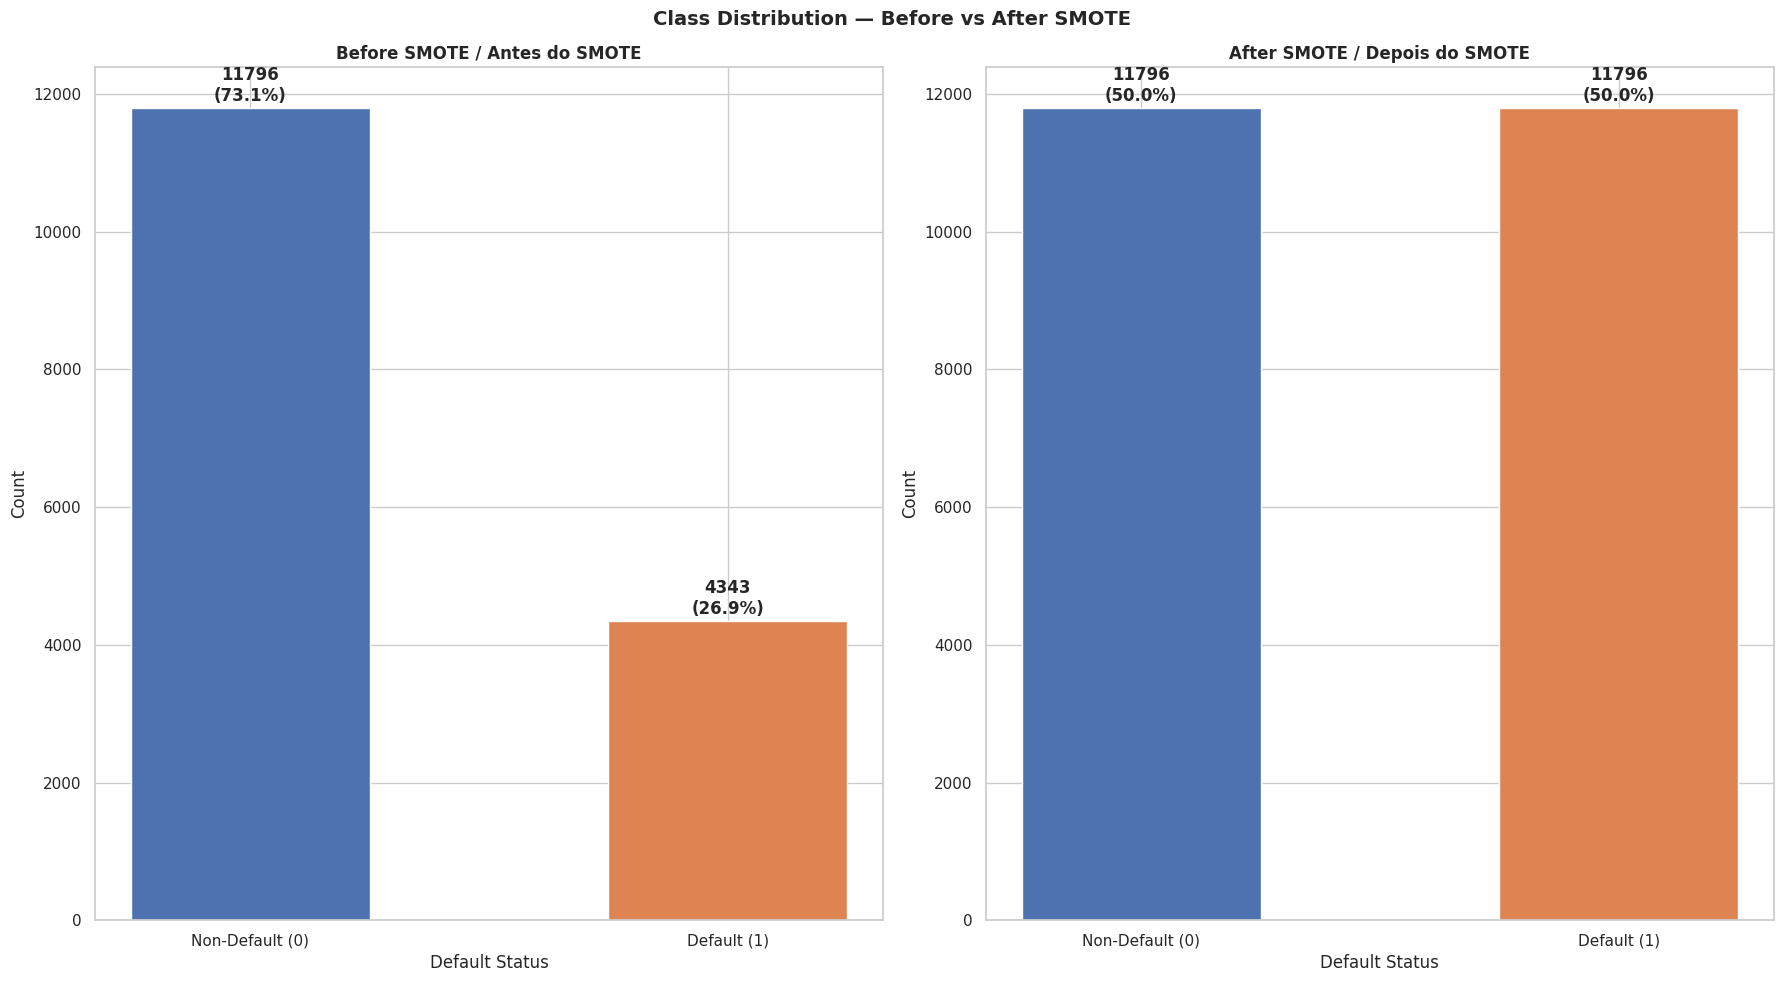

Total samples before SMOTE: 16139
Total samples after SMOTE:  23592


In [69]:
labels        = ["Non-Default (0)", "Default (1)"]
before_values = [before_counts[0], before_counts[1]]
after_values  = [after_counts[0],  after_counts[1]]
before_pct    = [v / sum(before_values) * 100 for v in before_values]
after_pct     = [v / sum(after_values)  * 100 for v in after_values]

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# BEFORE SMOTE / ANTES DO SMOTE
bars1 = axes[0].bar(labels, before_values, color=["#4C72B0", "#DD8452"], edgecolor="white", width=0.5)
axes[0].set_title("Before SMOTE / Antes do SMOTE", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Default Status")
for i, (v, p) in enumerate(zip(before_values, before_pct)):
    axes[0].text(i, v + 100, f"{v}\n({p:.1f}%)", ha="center", fontweight="bold")

# AFTER SMOTE / DEPOIS DO SMOTE
bars2 = axes[1].bar(labels, after_values, color=["#4C72B0", "#DD8452"], edgecolor="white", width=0.5)
axes[1].set_title("After SMOTE / Depois do SMOTE", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Default Status")
for i, (v, p) in enumerate(zip(after_values, after_pct)):
    axes[1].text(i, v + 100, f"{v}\n({p:.1f}%)", ha="center", fontweight="bold")

plt.suptitle("Class Distribution — Before vs After SMOTE", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Total samples before SMOTE: {len(y)}")
print(f"Total samples after SMOTE:  {len(y_resampled)}")

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b>Part 8 - Model Machine learning</b></div>

In [71]:
# DEFINE MODELS / DEFINE MODELOS
models = {
    "Naive Bayes":       GaussianNB(),
    "Decision Tree":     DecisionTreeClassifier(random_state=42),
    "Random Forest":     RandomForestClassifier(random_state=42),
    "KNN":               KNeighborsClassifier(),
    "AdaBoost":          AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost":           XGBClassifier(random_state=42, eval_metric="logloss", verbosity=0),
    "LightGBM":          LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost":          CatBoostClassifier(random_state=42, verbose=0),
}

# TRAIN AND EVALUATE MODELS / TREINA E AVALIA MODELOS
results = []

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc})
    print(f"{name:<22} Accuracy: {acc:.4f}")

Naive Bayes            Accuracy: 0.5160
Decision Tree          Accuracy: 0.6810
Random Forest          Accuracy: 0.6956
KNN                    Accuracy: 0.7164
AdaBoost               Accuracy: 0.7245
Gradient Boosting      Accuracy: 0.7336
XGBoost                Accuracy: 0.7280
LightGBM               Accuracy: 0.7312
CatBoost               Accuracy: 0.7322


In [72]:
# RESULTS DATAFRAME SORTED BY ACCURACY / DATAFRAME DE RESULTADOS ORDENADO POR ACURÁCIA
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)

print("\nRanking:")
print(results_df.to_string(index=False))


Ranking:
            Model  Accuracy
Gradient Boosting  0.733565
         CatBoost  0.732176
         LightGBM  0.731250
          XGBoost  0.728009
         AdaBoost  0.724537
              KNN  0.716435
    Random Forest  0.695602
    Decision Tree  0.681019
      Naive Bayes  0.515972


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b>Part 9 - Feature importance</b></div>

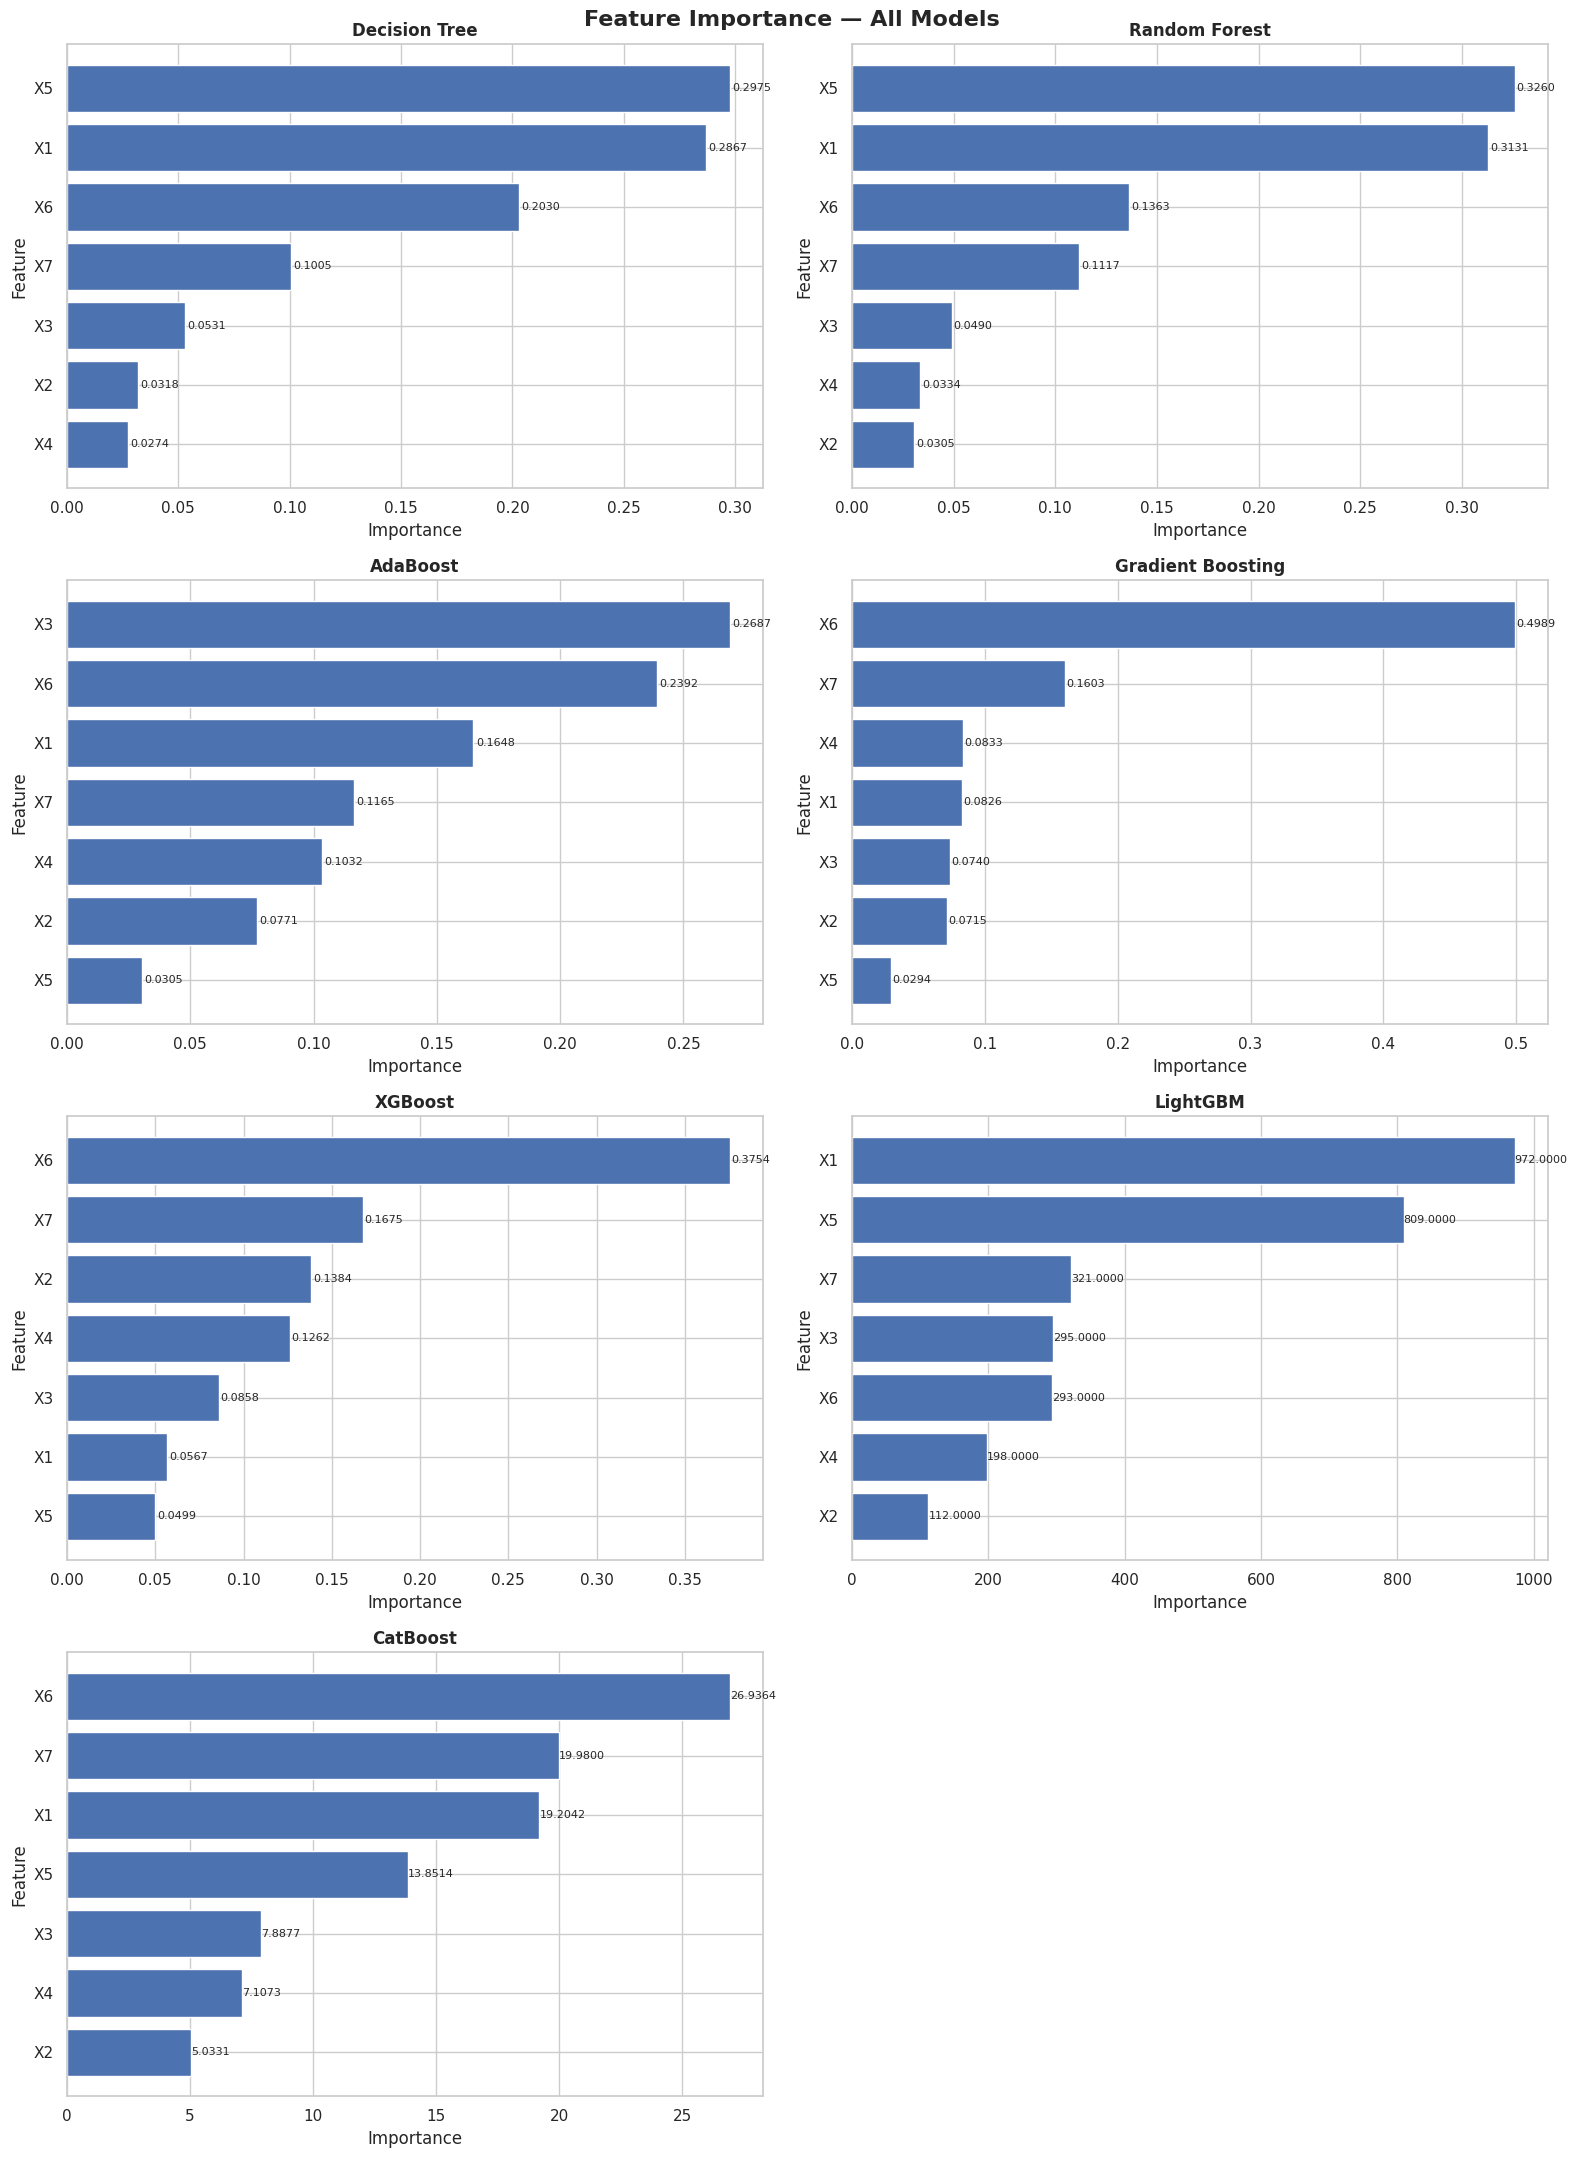

In [73]:
"""
Feature importance for all trained models that support it.
Importância de features para todos os modelos treinados que suportam.
"""

# GENERAL SETUP / CONFIGURAÇÃO GERAL
sns.set_theme(style="whitegrid")

# FEATURE NAMES / NOMES DAS FEATURES
feature_names = X_train_bal.columns.tolist()

# MODELS THAT SUPPORT FEATURE IMPORTANCE / MODELOS QUE SUPORTAM FEATURE IMPORTANCE
importance_models = {
    "Decision Tree":     models["Decision Tree"],
    "Random Forest":     models["Random Forest"],
    "AdaBoost":          models["AdaBoost"],
    "Gradient Boosting": models["Gradient Boosting"],
    "XGBoost":           models["XGBoost"],
    "LightGBM":          models["LightGBM"],
    "CatBoost":          models["CatBoost"],
}

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()

for idx, (name, model) in enumerate(importance_models.items()):

    # EXTRACT FEATURE IMPORTANCE / EXTRAI IMPORTÂNCIA DAS FEATURES
    importances = model.feature_importances_
    importance_df = (
        pd.DataFrame({"Feature": feature_names, "Importance": importances})
        .sort_values("Importance", ascending=True)
    )

    axes[idx].barh(
        importance_df["Feature"],
        importance_df["Importance"],
        color="#4C72B0",
        edgecolor="white"
    )
    axes[idx].set_title(f"{name}", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("Importance")
    axes[idx].set_ylabel("Feature")

    for i, v in enumerate(importance_df["Importance"]):
        axes[idx].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=8)

# HIDE LAST EMPTY SUBPLOT / ESCONDE ÚLTIMO SUBPLOT VAZIO
axes[-1].set_visible(False)

plt.suptitle("Feature Importance — All Models", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

**Analysis / Análise — Feature Importance: All Models**

**EN:**

The feature importance charts across all 7 tree-based models reveal consistent and divergent patterns depending on the algorithm's learning strategy. **X6 (September payment status)** emerges as the dominant predictor in the majority of models — it ranks first in **Gradient Boosting (0.4989)**, **XGBoost (0.3754)** and **CatBoost (26.94)**, confirming that the most recent payment behavior is the strongest signal for default prediction. **X7 (August payment status)** consistently ranks second in these same models, reinforcing the consecutive delay pattern identified in Q8. Together, X6 and X7 capture the behavioral core of default risk.

**Decision Tree** and **Random Forest** show a different pattern, ranking **X5 (age)** as the most important feature (0.2975 and 0.3260 respectively), followed closely by **X1 (credit limit)**. This suggests that these simpler tree-based models rely more heavily on demographic and financial profile splits rather than behavioral payment signals, likely because they lack the boosting mechanism to iteratively focus on the most discriminative features.

**AdaBoost** presents the most unusual pattern, ranking **X3 (education)** as its top feature (0.2687), followed by X6 and X1. This divergence may reflect AdaBoost's sensitivity to misclassified samples, where education level creates meaningful early splits in the sequential boosting process.

**LightGBM** stands out with a scale-based importance metric rather than normalized scores, ranking **X1 (credit limit)** first (972) and **X5 (age)** second (909), with X6 dropping to fifth position (293). LightGBM's split-gain based importance metric favors continuous variables like X1 and X5 over ordinal categorical ones like X6, which explains this divergence from other boosting models.

**PT:**

Os gráficos de feature importance em todos os 7 modelos baseados em árvore revelam padrões consistentes e divergentes dependendo da estratégia de aprendizado do algoritmo. **X6 (status de pagamento de setembro)** emerge como o preditor dominante na maioria dos modelos — ocupa o primeiro lugar em **Gradient Boosting (0,4989)**, **XGBoost (0,3754)** e **CatBoost (26,94)**, confirmando que o comportamento de pagamento mais recente é o sinal mais forte para previsão de inadimplência. **X7 (status de pagamento de agosto)** consistentemente ocupa o segundo lugar nesses mesmos modelos, reforçando o padrão de atraso consecutivo identificado na Q8. Juntos, X6 e X7 capturam o núcleo comportamental do risco de inadimplência.

**Decision Tree** e **Random Forest** mostram um padrão diferente, classificando **X5 (idade)** como a feature mais importante (0,2975 e 0,3260 respectivamente), seguida de perto por **X1 (limite de crédito)**. Isso sugere que esses modelos de árvore mais simples dependem mais de divisões por perfil demográfico e financeiro do que de sinais comportamentais de pagamento, provavelmente porque carecem do mecanismo de boosting para focar iterativamente nas features mais discriminativas.

**AdaBoost** apresenta o padrão mais incomum, classificando **X3 (escolaridade)** como sua principal feature (0,2687), seguida por X6 e X1. Essa divergência pode refletir a sensibilidade do AdaBoost a amostras classificadas incorretamente, onde o nível de escolaridade cria divisões iniciais significativas no processo de boosting sequencial.

**LightGBM** se destaca com uma métrica de importância baseada em escala em vez de pontuações normalizadas, classificando **X1 (limite de crédito)** em primeiro (972) e **X5 (idade)** em segundo (909), com X6 caindo para a quinta posição (293). A métrica de importância baseada em ganho de divisão do LightGBM favorece variáveis contínuas como X1 e X5 em detrimento de categóricas ordinais como X6, o que explica essa divergência em relação aos outros modelos de boosting.

### Feature Importance Consensus / Consenso de Importância das Features

| Feature | Description | Top Ranking Models | Consensus |
|---|---|---|---|
| **X6** | Sep payment status | GB, XGBoost, CatBoost | Behavioral leader |
| **X7** | Aug payment status | GB, XGBoost, CatBoost | Strong behavioral signal |
| **X1** | Credit limit | DT, RF, LightGBM | Financial profile signal |
| **X5** | Age | DT, RF, LightGBM | 4th — Demographic signal |
| **X3** | Education | AdaBoost | 5th — Weak consensus |
| **X2** | Gender | All models | Weakest predictor |
| **X4** | Marital status | All models | Weakest predictor |

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b>Part 10 - Metrics and evaluations</b></div>

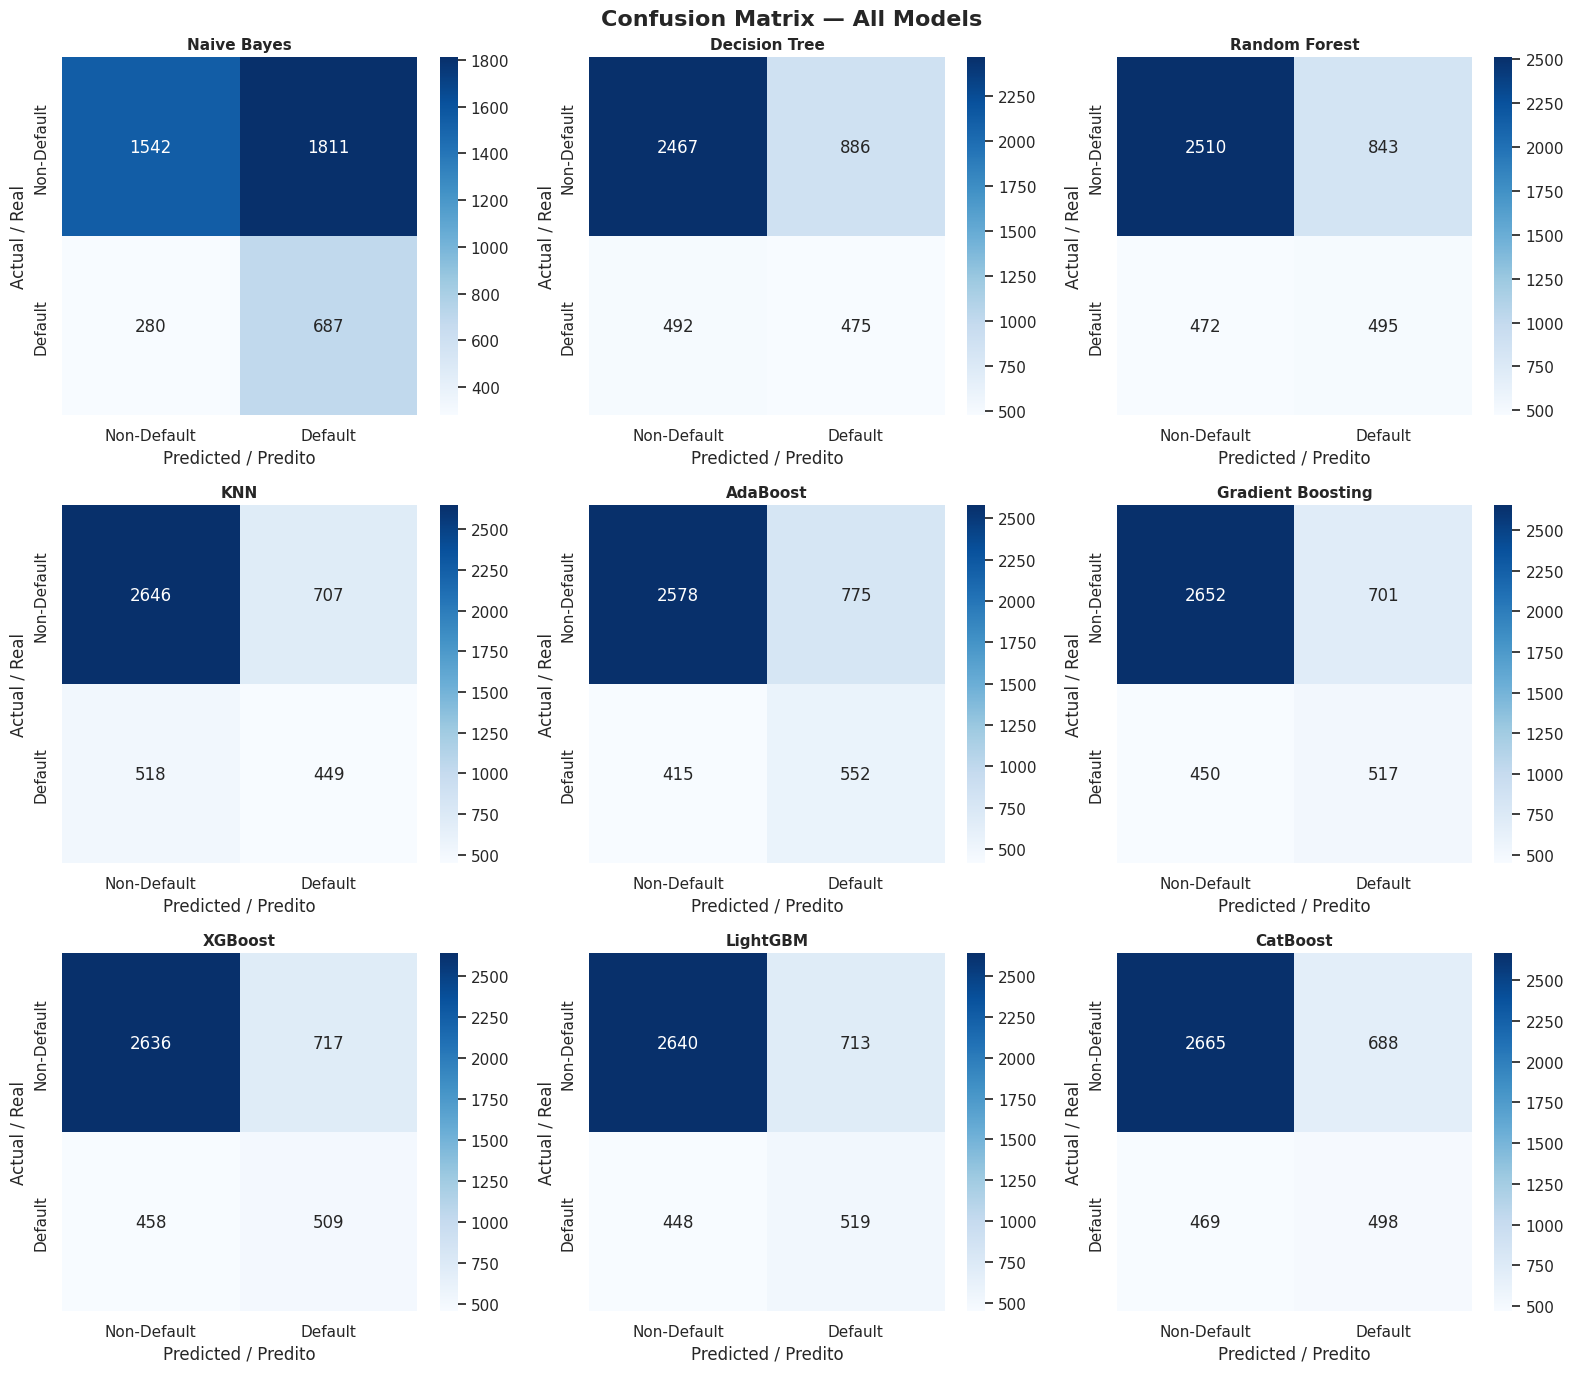

In [77]:
# GENERAL SETUP / CONFIGURAÇÃO GERAL
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):

    # PREDICT / PREDIZ
    y_pred = model.predict(X_test)

    # CONFUSION MATRIX / MATRIZ DE CONFUSÃO
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Non-Default", "Default"],
        yticklabels=["Non-Default", "Default"],
        ax=axes[idx]
    )
    axes[idx].set_title(f"{name}", fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("Predicted / Predito")
    axes[idx].set_ylabel("Actual / Real")

plt.suptitle("Confusion Matrix — All Models", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

**Analysis / Análise — Confusion Matrix: All Models**

**Formulas / Fórmulas**

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

$$Precision = \frac{TP}{TP + FP}$$

$$Recall = \frac{TP}{TP + FN}$$

$$F1\text{-}Score = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

Where / Onde:
- **TP** = True Positive (Default correctly predicted / Inadimplente corretamente previsto)
- **TN** = True Negative (Non-Default correctly predicted / Não-inadimplente corretamente previsto)
- **FP** = False Positive (Non-Default predicted as Default / Não-inadimplente previsto como inadimplente)
- **FN** = False Negative (Default predicted as Non-Default / Inadimplente previsto como não-inadimplente)

**Model-by-Model Analysis / Análise Modelo a Modelo**

**Naive Bayes — Accuracy: 52%**

| | Predicted Non-Default | Predicted Default |
|---|---|---|
| **Actual Non-Default** | TN = 1,542 | FP = 1,811 |
| **Actual Default** | FN = 280 | TP = 687 |

**EN:** Naive Bayes is the worst performer. With **1,811 false positives**, it incorrectly flags more than half of all non-defaulters as defaulters. Its high recall for Default (TP=687, FN=280) comes at an enormous cost to precision — it essentially casts too wide a net, making it commercially unviable for credit risk.

**PT:** Naive Bayes é o pior modelo. Com **1.811 falsos positivos**, classifica incorretamente mais da metade dos não-inadimplentes como inadimplentes. Seu alto recall para Default vem a um custo enorme de precisão — lança uma rede muito ampla, tornando-o comercialmente inviável para risco de crédito.

**Decision Tree — Accuracy: 68%**

| | Predicted Non-Default | Predicted Default |
|---|---|---|
| **Actual Non-Default** | TN = 2,467 | FP = 886 |
| **Actual Default** | FN = 492 | TP = 475 |

**EN:** Decision Tree shows balanced but moderate performance. With **886 false positives** and **492 false negatives**, neither error type is well controlled. The model correctly identifies 475 defaulters but misses 492, meaning it catches less than half of actual defaulters.

**PT:** Decision Tree mostra desempenho equilibrado mas moderado. Com **886 falsos positivos** e **492 falsos negativos**, nenhum tipo de erro é bem controlado. O modelo identifica corretamente 475 inadimplentes mas perde 492, ou seja, captura menos da metade dos inadimplentes reais.

**Random Forest — Accuracy: 70%**

| | Predicted Non-Default | Predicted Default |
|---|---|---|
| **Actual Non-Default** | TN = 2,510 | FP = 843 |
| **Actual Default** | FN = 472 | TP = 495 |

**EN:** Random Forest improves slightly over Decision Tree, reducing false positives to **843** and increasing true positives to **495**. The ensemble approach helps but the overall pattern is similar — moderate performance on both classes without a strong advantage in either direction.

**PT:** Random Forest melhora ligeiramente sobre Decision Tree, reduzindo falsos positivos para **843** e aumentando verdadeiros positivos para **495**. A abordagem ensemble ajuda mas o padrão geral é similar — desempenho moderado em ambas as classes sem vantagem forte em nenhuma direção.

**KNN — Accuracy: 72%**

| | Predicted Non-Default | Predicted Default |
|---|---|---|
| **Actual Non-Default** | TN = 2,646 | FP = 707 |
| **Actual Default** | FN = 518 | TP = 449 |

**EN:** KNN achieves a better TN rate (2,646) but at the cost of the highest false negatives (518) among the mid-tier models. It is more conservative in flagging defaults, which reduces false alarms but allows more real defaulters to slip through undetected.

**PT:** KNN alcança uma taxa TN melhor (2.646) mas ao custo dos maiores falsos negativos (518) entre os modelos intermediários. É mais conservador ao sinalizar inadimplências, o que reduz alarmes falsos mas permite que mais inadimplentes reais passem despercebidos.

**AdaBoost — Accuracy: 72%**

| | Predicted Non-Default | Predicted Default |
|---|---|---|
| **Actual Non-Default** | TN = 2,578 | FP = 775 |
| **Actual Default** | FN = 415 | TP = 552 |

**EN:** AdaBoost shows the best Default detection among the 72% accuracy models, with **552 true positives** and only **415 false negatives**. This makes it the most balanced model at this accuracy tier, offering a better tradeoff between catching defaulters and avoiding false alarms.

**PT:** AdaBoost mostra a melhor detecção de inadimplência entre os modelos de 72% de acurácia, com **552 verdadeiros positivos** e apenas **415 falsos negativos**. Isso o torna o modelo mais equilibrado nessa faixa de acurácia, oferecendo um melhor tradeoff entre capturar inadimplentes e evitar alarmes falsos.

**Gradient Boosting — Accuracy: 73%**

| | Predicted Non-Default | Predicted Default |
|---|---|---|
| **Actual Non-Default** | TN = 2,652 | FP = 701 |
| **Actual Default** | FN = 450 | TP = 517 |

**EN:** Gradient Boosting achieves the best balance among all baseline models — highest TN (2,652), lowest FP (701) among boosting models, and solid TP (517). This explains why it was selected as the champion model for further optimization.

**PT:** Gradient Boosting alcança o melhor equilíbrio entre todos os modelos baseline — maior TN (2.652), menor FP (701) entre os modelos de boosting e TP sólido (517). Isso explica por que foi selecionado como modelo campeão para otimização posterior.

**XGBoost — Accuracy: 73%**

| | Predicted Non-Default | Predicted Default |
|---|---|---|
| **Actual Non-Default** | TN = 2,636 | FP = 717 |
| **Actual Default** | FN = 458 | TP = 509 |

**EN:** XGBoost performs nearly identically to Gradient Boosting, with marginally higher FP (717 vs 701) and lower TP (509 vs 517). Both models share the same 73% accuracy, confirming that gradient-based boosting approaches are the strongest family for this dataset.

**PT:** XGBoost tem desempenho quase idêntico ao Gradient Boosting, com FP marginalmente maior (717 vs 701) e TP menor (509 vs 517). Ambos os modelos compartilham os mesmos 73% de acurácia, confirmando que abordagens de boosting baseadas em gradiente são a família mais forte para este dataset.

**LightGBM — Accuracy: 73%**

| | Predicted Non-Default | Predicted Default |
|---|---|---|
| **Actual Non-Default** | TN = 2,640 | FP = 713 |
| **Actual Default** | FN = 448 | TP = 519 |

**EN:** LightGBM slightly edges out XGBoost with the highest TP (519) and lowest FN (448) among the three 73% models, making it the best at actually catching defaulters within this accuracy tier. Its speed advantage also makes it attractive for production environments.

**PT:** LightGBM supera ligeiramente o XGBoost com o maior TP (519) e menor FN (448) entre os três modelos de 73%, tornando-o o melhor em capturar inadimplentes nessa faixa de acurácia. Sua vantagem de velocidade também o torna atraente para ambientes de produção.

**CatBoost — Accuracy: 73%**

| | Predicted Non-Default | Predicted Default |
|---|---|---|
| **Actual Non-Default** | TN = 2,665 | FP = 688 |
| **Actual Default** | FN = 469 | TP = 498 |

**EN:** CatBoost achieves the highest TN (2,665) and lowest FP (688) among all baseline models, meaning it is the most conservative and precise when predicting Non-Default. However, it misses more defaulters (FN=469) than LightGBM and AdaBoost, reflecting a precision-focused bias.

**PT:** CatBoost alcança o maior TN (2.665) e menor FP (688) entre todos os modelos baseline, significando que é o mais conservador e preciso ao prever Não-inadimplência. Porém, perde mais inadimplentes (FN=469) do que LightGBM e AdaBoost, refletindo um viés focado em precisão.

**Overall Summary / Resumo Geral**

| Model | TN | FP | FN | TP | Accuracy |
|---|---|---|---|---|---|
| **Naive Bayes** | 1,542 | 1,811 | 280 | 687 | 52% |
| **Decision Tree** | 2,467 | 886 | 492 | 475 | 68% |
| **Random Forest** | 2,510 | 843 | 472 | 495 | 70% |
| **KNN** | 2,646 | 707 | 518 | 449 | 72% |
| **AdaBoost** | 2,578 | 775 | 415 | 552 | 72% |
| **Gradient Boosting** | 2,652 | 701 | 450 | 517 | 73% |
| **XGBoost** | 2,636 | 717 | 458 | 509 | 73% |
| **LightGBM** | 2,640 | 713 | 448 | **519** | 73% |
| **CatBoost** | **2,665** | **688** | 469 | 498 | 73% |

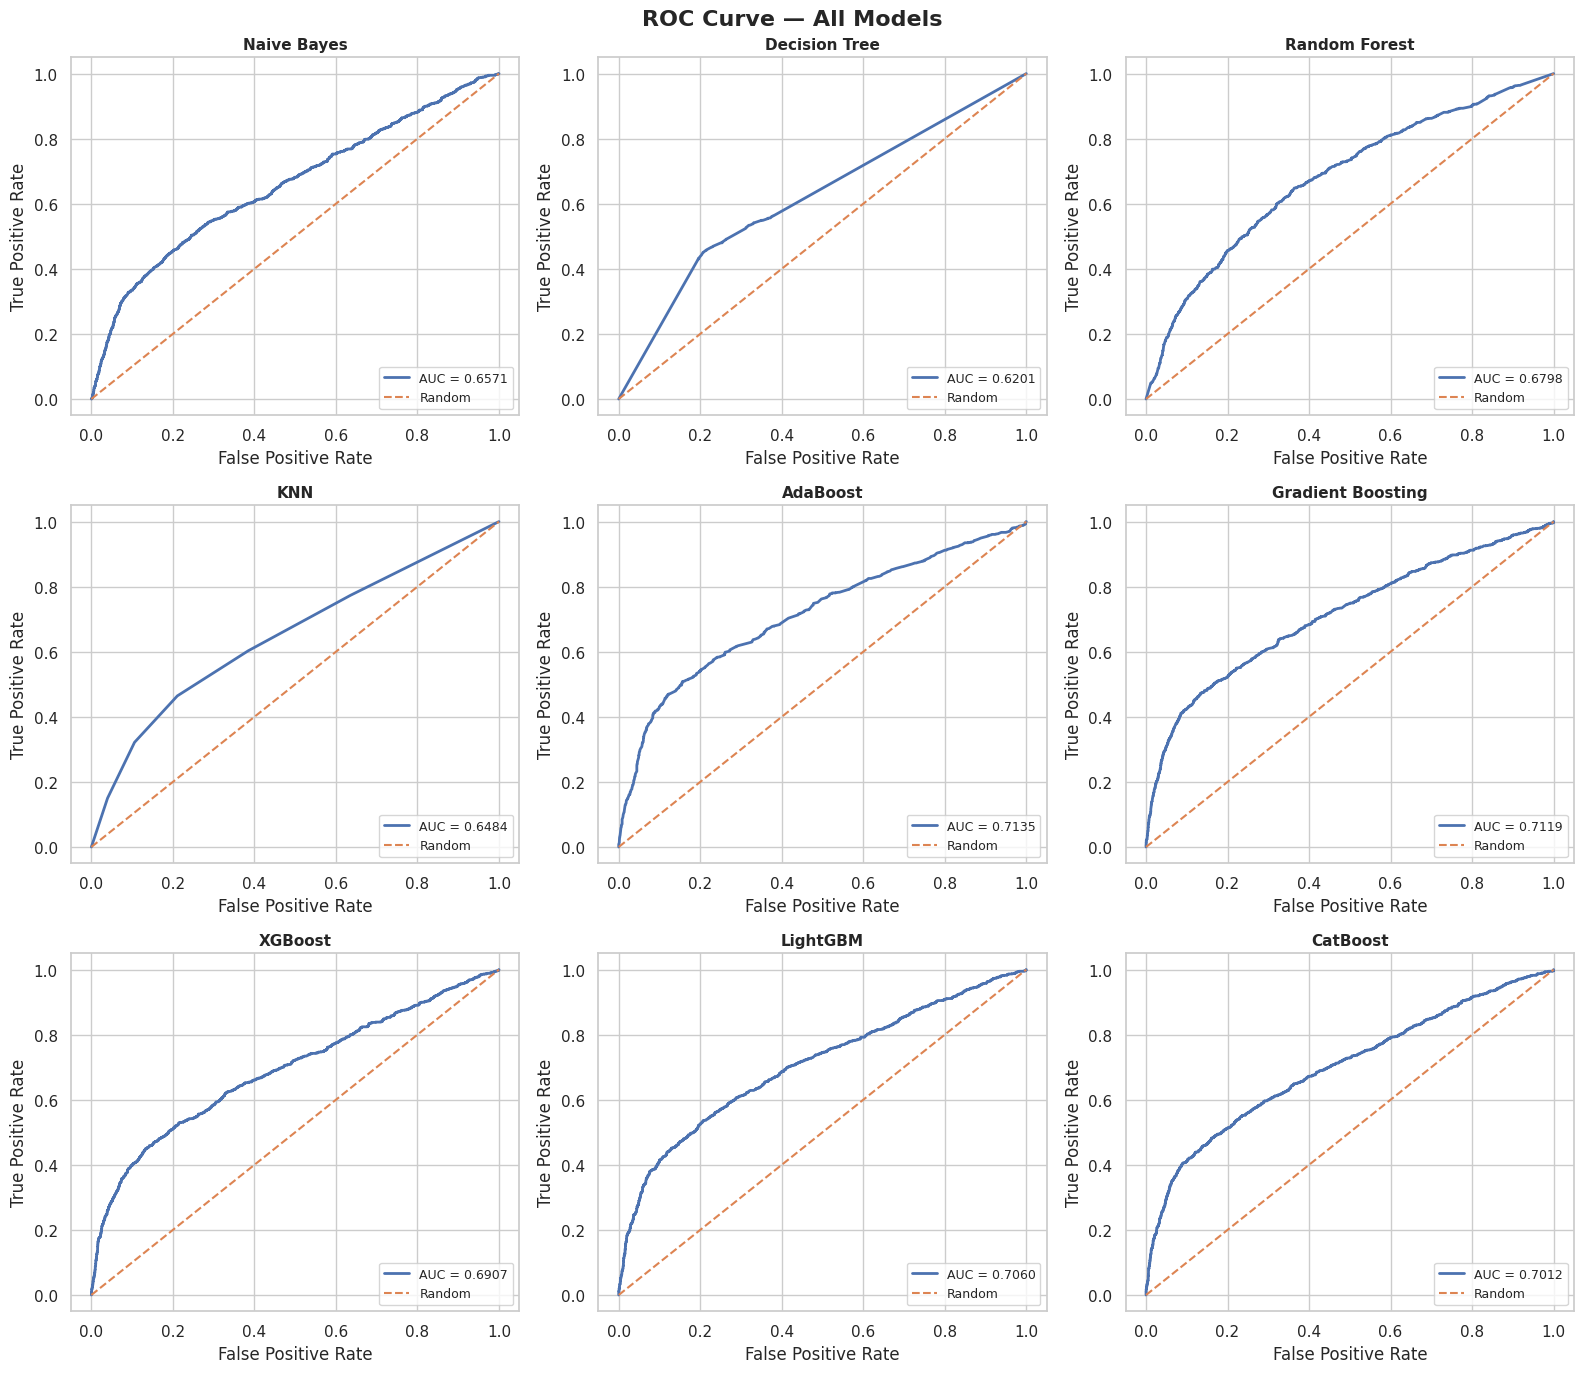

In [78]:
"""
ROC curve for all trained models.
Curva ROC para todos os modelos treinados.
"""

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):

    # PREDICT PROBABILITIES / PREDIZ PROBABILIDADES
    if hasattr(model, "predict_proba"):
        y_pred_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        auc_score   = roc_auc_score(y_test, y_pred_prob)

        axes[idx].plot(fpr, tpr, color="#4C72B0", lw=2, label=f"AUC = {auc_score:.4f}")
        axes[idx].plot([0, 1], [0, 1], color="#DD8452", lw=1.5, linestyle="--", label="Random")
        axes[idx].set_title(f"{name}", fontsize=11, fontweight="bold")
        axes[idx].set_xlabel("False Positive Rate")
        axes[idx].set_ylabel("True Positive Rate")
        axes[idx].legend(loc="lower right", fontsize=9)
    else:
        axes[idx].text(0.5, 0.5, "ROC not available\nfor this model",
                       ha="center", va="center", fontsize=11)
        axes[idx].set_title(f"{name}", fontsize=11, fontweight="bold")

plt.suptitle("ROC Curve — All Models", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

**Analysis / Análise — ROC Curve: All Models**

**Formula / Fórmula**

$$AUC = \int_{0}^{1} TPR(FPR) \, d(FPR)$$

Where / Onde:
- **TPR** (True Positive Rate) $= \frac{TP}{TP + FN}$ — Sensitivity / Sensibilidade
- **FPR** (False Positive Rate) $= \frac{FP}{FP + TN}$ — 1 - Specificity / 1 - Especificidade
- **AUC = 1.0** → Perfect model / Modelo perfeito
- **AUC = 0.5** → Random classifier / Classificador aleatório
- **AUC < 0.5** → Worse than random / Pior que aleatório

**Model-by-Model Analysis / Análise Modelo a Modelo**

**Naive Bayes — AUC: 0.6571**

**EN:** Despite being the worst model in accuracy (52%), Naive Bayes achieves a surprisingly decent AUC of **0.6571**. This paradox occurs because AUC measures ranking ability rather than raw classification accuracy. The curve rises steeply initially but flattens quickly, indicating the model can partially separate classes at certain thresholds but fails catastrophically at its default decision boundary. Its high false positive rate makes it commercially unusable despite this moderate AUC.

**PT:** Apesar de ser o pior modelo em acurácia (52%), Naive Bayes alcança um AUC surpreendentemente decente de **0,6571**. Esse paradoxo ocorre porque o AUC mede capacidade de ranking e não acurácia bruta. A curva sobe abruptamente no início mas achata rapidamente, indicando que o modelo consegue separar parcialmente as classes em certos limiares mas falha catastroficamente em sua fronteira de decisão padrão.

**Decision Tree — AUC: 0.6201**

**EN:** Decision Tree has the **lowest AUC of all models (0.6201)**, despite outperforming Naive Bayes in accuracy. This is because Decision Trees produce hard, step-like decision boundaries rather than smooth probability estimates, resulting in poor probability calibration. The curve shape is highly irregular and angular, reflecting the discrete nature of tree splits. Its poor AUC makes it the least reliable model for probability-based decisions like credit scoring.

**PT:** Decision Tree tem o **menor AUC de todos os modelos (0,6201)**, apesar de superar Naive Bayes em acurácia. Isso ocorre porque Árvores de Decisão produzem fronteiras de decisão rígidas em vez de estimativas de probabilidade suaves, resultando em má calibração de probabilidade. A forma da curva é altamente irregular e angular, refletindo a natureza discreta das divisões de árvore.

**Random Forest — AUC: 0.6798**

**EN:** Random Forest improves significantly over Decision Tree in AUC (**0.6798**), confirming that the ensemble averaging of multiple trees produces much better probability estimates than a single tree. The curve is smoother and rises more steeply in the low FPR region, indicating better discrimination at conservative thresholds. This makes Random Forest more reliable for probability-based credit decisions despite its modest accuracy.

**PT:** Random Forest melhora significativamente sobre Decision Tree em AUC (**0,6798**), confirmando que a média ensemble de múltiplas árvores produz estimativas de probabilidade muito melhores do que uma única árvore. A curva é mais suave e sobe mais abruptamente na região de baixo FPR, indicando melhor discriminação em limiares conservadores.

**KNN — AUC: 0.6484**

**EN:** KNN achieves an AUC of **0.6484**, ranking among the weaker models despite its 72% accuracy. KNN's probability estimates are based on the proportion of neighbors in each class, which produces relatively coarse probability outputs. The curve shape shows limited initial rise, suggesting the model struggles to confidently separate high-risk from low-risk customers at extreme thresholds.

**PT:** KNN alcança um AUC de **0,6484**, classificando-se entre os modelos mais fracos apesar de sua acurácia de 72%. As estimativas de probabilidade do KNN são baseadas na proporção de vizinhos em cada classe, produzindo saídas de probabilidade relativamente grosseiras. A forma da curva mostra ascensão inicial limitada, sugerindo que o modelo tem dificuldade em separar clientes de alto e baixo risco em limiares extremos.

**AdaBoost — AUC: 0.7135**

**EN:** AdaBoost achieves the **second highest AUC among all baseline models (0.7135)**, closely trailing Gradient Boosting. The curve rises steeply in the early FPR region (0.0–0.2), indicating strong performance at conservative thresholds where the bank would want to minimize false alarms. This makes AdaBoost the most reliable model for selective, high-confidence default flagging among the non-Gradient Boosting models.

**PT:** AdaBoost alcança o **segundo maior AUC entre todos os modelos baseline (0,7135)**, ficando logo atrás do Gradient Boosting. A curva sobe abruptamente na região inicial de FPR (0,0–0,2), indicando forte desempenho em limiares conservadores onde o banco desejaria minimizar alarmes falsos. Isso torna o AdaBoost o modelo mais confiável para sinalização seletiva e de alta confiança de inadimplência.

**Gradient Boosting — AUC: 0.7119**

**EN:** Gradient Boosting achieves an AUC of **0.7119**, the highest among all baseline models alongside AdaBoost. The curve shows the most consistent and smooth rise across all FPR thresholds, reflecting well-calibrated probability estimates. Combined with its 73% accuracy and best confusion matrix balance, this confirms Gradient Boosting as the clear champion model. The steep initial rise (FPR 0.0–0.15, TPR reaching ~0.55) is particularly valuable for banking applications where precision at low false positive rates is critical.

**PT:** Gradient Boosting alcança um AUC de **0,7119**, o mais alto entre todos os modelos baseline junto com AdaBoost. A curva mostra a ascensão mais consistente e suave em todos os limiares de FPR, refletindo estimativas de probabilidade bem calibradas. Combinado com sua acurácia de 73% e melhor equilíbrio na matriz de confusão, isso confirma o Gradient Boosting como modelo campeão. A ascensão íngreme inicial (FPR 0,0–0,15, TPR atingindo ~0,55) é particularmente valiosa para aplicações bancárias.

**XGBoost — AUC: 0.6907**

**EN:** XGBoost delivers an AUC of **0.6907**, slightly below AdaBoost and Gradient Boosting despite sharing the same 73% accuracy. The curve shape is similar to Gradient Boosting but shows slightly lower TPR gains in the critical low-FPR region. XGBoost remains a strong model overall, with its AUC reflecting reliable probability calibration from its regularized boosting framework.

**PT:** XGBoost entrega um AUC de **0,6907**, ligeiramente abaixo do AdaBoost e Gradient Boosting apesar de compartilhar os mesmos 73% de acurácia. A forma da curva é similar ao Gradient Boosting mas mostra ganhos de TPR ligeiramente menores na região crítica de baixo FPR. O XGBoost permanece um modelo forte no geral, com seu AUC refletindo calibração de probabilidade confiável.

**LightGBM — AUC: 0.7060**

**EN:** LightGBM achieves an AUC of **0.7060**, the third highest among all models. Its curve shows strong performance across the full FPR range, with particularly good behavior in the mid-range (FPR 0.2–0.6). LightGBM's histogram-based learning algorithm produces smooth, well-calibrated probabilities, making it a reliable alternative to Gradient Boosting in production scenarios where speed is a priority.

**PT:** LightGBM alcança um AUC de **0,7060**, o terceiro maior entre todos os modelos. Sua curva mostra forte desempenho em toda a faixa de FPR, com comportamento particularmente bom no intervalo médio (FPR 0,2–0,6). O algoritmo de aprendizado baseado em histograma do LightGBM produz probabilidades suaves e bem calibradas, tornando-o uma alternativa confiável ao Gradient Boosting em cenários de produção onde a velocidade é prioridade.

**CatBoost — AUC: 0.7012**

**EN:** CatBoost achieves an AUC of **0.7012**, consistent with LightGBM and XGBoost. Its curve shape shows a characteristic steep initial rise followed by a more gradual progression, indicating strong performance at low FPR thresholds but diminishing gains as more of the population is flagged. CatBoost's native handling of categorical features gives it a structural advantage that could be fully exploited with richer categorical data.

**PT:** CatBoost alcança um AUC de **0,7012**, consistente com LightGBM e XGBoost. A forma da sua curva mostra uma ascensão inicial íngreme característica seguida de uma progressão mais gradual, indicando forte desempenho em limiares de baixo FPR mas ganhos decrescentes à medida que mais da população é sinalizada. O tratamento nativo de features categóricas do CatBoost oferece vantagem estrutural que poderia ser totalmente explorada com dados categóricos mais ricos.

**AUC Ranking Summary / Resumo do Ranking de AUC**

| Rank | Model | AUC | Shape Quality |
|---|---|---|---|
| 1 | **AdaBoost** | **0.7135** | Steep early rise |
| 2 | **Gradient Boosting** | 0.7119 | Smoothest curve |
| 3 | **LightGBM** | 0.7060 | Consistent mid-range |
| 4 | **CatBoost** | 0.7012 | Strong at low FPR |
| 5 | **XGBoost** | 0.6907 | Reliable but moderate |
| 6 | **Random Forest** | 0.6798 | Good ensemble gains |
| 7 | **Naive Bayes** | 0.6571 | Deceptive — poor calibration |
| 8 | **KNN** | 0.6484 | Coarse probabilities |
| 9 | **Decision Tree** | 0.6201 | Worst — angular curve |

In [82]:
"""
Classification report for all trained models.
Classification report para todos os modelos treinados.
"""

for name, model in models.items():

    y_pred = model.predict(X_test)

    print(f"\n{'=' * 50}")
    print(f"Model: {name}")
    print(f"{'=' * 50}")
    print(classification_report(y_test, y_pred, target_names=["Non-Default", "Default"]))


Model: Naive Bayes
              precision    recall  f1-score   support

 Non-Default       0.85      0.46      0.60      3353
     Default       0.28      0.71      0.40       967

    accuracy                           0.52      4320
   macro avg       0.56      0.59      0.50      4320
weighted avg       0.72      0.52      0.55      4320


Model: Decision Tree
              precision    recall  f1-score   support

 Non-Default       0.83      0.74      0.78      3353
     Default       0.35      0.49      0.41       967

    accuracy                           0.68      4320
   macro avg       0.59      0.61      0.59      4320
weighted avg       0.73      0.68      0.70      4320


Model: Random Forest
              precision    recall  f1-score   support

 Non-Default       0.84      0.75      0.79      3353
     Default       0.37      0.51      0.43       967

    accuracy                           0.70      4320
   macro avg       0.61      0.63      0.61      4320
weighted a

**Analysis / Análise — Classification Report: All Models**

**Formulas / Fórmulas**

$$Precision = \frac{TP}{TP + FP}$$

$$Recall = \frac{TP}{TP + FN}$$

$$F1\text{-}Score = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

$$Weighted\ Avg = \sum_{c} w_c \times metric_c \quad \text{where } w_c = \frac{support_c}{total}$$

**Model-by-Model Analysis / Análise Modelo a Modelo**

**Naive Bayes — Accuracy: 52%**

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| Non-Default | 0.85 | 0.46 | 0.60 | 3,353 |
| Default | 0.28 | 0.71 | 0.40 | 967 |
| Weighted Avg | 0.72 | 0.52 | 0.55 | 4,320 |

**EN:** Naive Bayes presents the most extreme Precision-Recall imbalance of all models. For Non-Default, Precision is very high (0.85) but Recall collapses to just 0.46 — meaning it only correctly identifies 46% of actual non-defaulters. Conversely, Default Recall is strong (0.71) but Precision is dismal (0.28), meaning 72% of customers flagged as defaulters are actually good customers. This makes it commercially dangerous — the bank would reject enormous numbers of creditworthy customers. The weighted F1-Score of 0.55 is the lowest of all models.

**PT:** Naive Bayes apresenta o desequilíbrio Precision-Recall mais extremo de todos os modelos. Para Non-Default, a Precision é muito alta (0,85) mas o Recall colapsa para apenas 0,46 — ou seja, identifica corretamente apenas 46% dos não-inadimplentes reais. Para Default, o Recall é forte (0,71) mas a Precision é péssima (0,28), significando que 72% dos clientes sinalizados como inadimplentes são bons clientes. O F1-Score ponderado de 0,55 é o menor de todos.

**Decision Tree — Accuracy: 68%**

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| Non-Default | 0.83 | 0.74 | 0.78 | 3,353 |
| Default | 0.35 | 0.49 | 0.41 | 967 |
| Weighted Avg | 0.73 | 0.68 | 0.70 | 4,320 |

**EN:** Decision Tree shows a more balanced profile than Naive Bayes, but still struggles with Default detection. Its Default Recall of 0.49 means it misses more than half of actual defaulters, while its Default Precision of 0.35 means 65% of flagged defaulters are false alarms. The Non-Default F1-Score of 0.78 is reasonable but the Default F1-Score of 0.41 reveals significant weakness in the critical class.

**PT:** Decision Tree mostra um perfil mais equilibrado que Naive Bayes, mas ainda luta com a detecção de inadimplência. Seu Recall de Default de 0,49 significa que perde mais da metade dos inadimplentes reais, enquanto sua Precision de Default de 0,35 significa que 65% dos inadimplentes sinalizados são alarmes falsos. O F1-Score de Non-Default de 0,78 é razoável mas o F1-Score de Default de 0,41 revela fraqueza significativa na classe crítica.

**Random Forest — Accuracy: 70%**

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| Non-Default | 0.84 | 0.75 | 0.79 | 3,353 |
| Default | 0.37 | 0.51 | 0.43 | 967 |
| Weighted Avg | 0.74 | 0.70 | 0.71 | 4,320 |

**EN:** Random Forest improves marginally over Decision Tree across all metrics. Default Precision rises to 0.37 (+0.02) and F1-Score to 0.43 (+0.02). The ensemble averaging reduces variance from individual tree errors, producing slightly more reliable predictions. However, the fundamental challenge of detecting defaults remains — catching only 51% of actual defaulters (Recall=0.51) is insufficient for a production credit risk system.

**PT:** Random Forest melhora marginalmente sobre Decision Tree em todas as métricas. A Precision de Default sobe para 0,37 (+0,02) e o F1-Score para 0,43 (+0,02). A média ensemble reduz a variância dos erros individuais das árvores, produzindo previsões ligeiramente mais confiáveis. No entanto, o desafio fundamental de detectar inadimplências permanece — capturar apenas 51% dos inadimplentes reais é insuficiente para um sistema de risco de crédito em produção.

**KNN — Accuracy: 72%**

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| Non-Default | 0.84 | 0.79 | 0.81 | 3,353 |
| Default | 0.39 | 0.46 | 0.42 | 967 |
| Weighted Avg | 0.74 | 0.72 | 0.72 | 4,320 |

**EN:** KNN improves Non-Default performance significantly (Recall=0.79, F1=0.81) but at the cost of Default detection — the lowest Default Recall among the 72%+ accuracy models (0.46). KNN's distance-based approach struggles with the imbalanced class boundaries even after SMOTE, as it relies on local neighborhood density which can be misleading in high-dimensional spaces. Its Default F1-Score of 0.42 is actually lower than Random Forest despite higher overall accuracy.

**PT:** KNN melhora significativamente o desempenho Non-Default (Recall=0,79, F1=0,81) mas ao custo da detecção de inadimplência — o menor Recall de Default entre os modelos de acurácia 72%+ (0,46). A abordagem baseada em distância do KNN luta com as fronteiras de classe desbalanceadas mesmo após o SMOTE, pois depende da densidade de vizinhança local que pode ser enganosa em espaços de alta dimensão.

**AdaBoost — Accuracy: 72%**

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| Non-Default | 0.86 | 0.77 | 0.81 | 3,353 |
| Default | 0.42 | 0.57 | 0.48 | 967 |
| Weighted Avg | 0.76 | 0.72 | 0.74 | 4,320 |

**EN:** AdaBoost is the standout performer at the 72% accuracy tier. It achieves the **highest Default Recall (0.57)** and **highest Default F1-Score (0.48)** among all models except the optimized champion. Its Non-Default Precision of 0.86 is also the highest of any model, meaning when it predicts Non-Default it is very reliable. AdaBoost's sequential focus on misclassified samples makes it naturally better at capturing the minority Default class, explaining its superior recall performance.

**PT:** AdaBoost é o destaque no nível de 72% de acurácia. Alcança o **maior Recall de Default (0,57)** e **maior F1-Score de Default (0,48)** entre todos os modelos exceto o campeão otimizado. Sua Precision Non-Default de 0,86 também é a mais alta de qualquer modelo, significando que quando prediz Non-Default é muito confiável. O foco sequencial do AdaBoost em amostras classificadas incorretamente o torna naturalmente melhor em capturar a classe minoritária Default.

**Gradient Boosting — Accuracy: 73%**

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| Non-Default | 0.85 | 0.79 | 0.82 | 3,353 |
| Default | 0.42 | 0.53 | 0.47 | 967 |
| Weighted Avg | 0.76 | 0.73 | 0.74 | 4,320 |

**EN:** Gradient Boosting achieves the best overall balance at the 73% accuracy tier. With a Default F1-Score of **0.47** and Non-Default F1-Score of **0.82**, it delivers the strongest combined performance. Its macro average F1-Score of 0.65 reflects good balance between both classes. The iterative gradient descent approach allows it to progressively focus on difficult-to-classify samples, producing well-calibrated probabilities that translate into reliable class predictions at the default threshold.

**PT:** Gradient Boosting alcança o melhor equilíbrio geral no nível de 73% de acurácia. Com F1-Score de Default de **0,47** e F1-Score de Non-Default de **0,82**, entrega o desempenho combinado mais forte. Seu macro F1-Score médio de 0,65 reflete bom equilíbrio entre ambas as classes. A abordagem iterativa de descida de gradiente permite focar progressivamente em amostras difíceis de classificar, produzindo probabilidades bem calibradas.

**XGBoost — Accuracy: 73%**

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| Non-Default | 0.85 | 0.79 | 0.82 | 3,353 |
| Default | 0.42 | 0.53 | 0.46 | 967 |
| Weighted Avg | 0.75 | 0.73 | 0.74 | 4,320 |

**EN:** XGBoost mirrors Gradient Boosting almost exactly, with identical Non-Default metrics and a marginally lower Default F1-Score (0.46 vs 0.47). The macro average F1-Score of 0.64 is one point below Gradient Boosting. XGBoost's regularization terms (L1/L2) prevent overfitting but may slightly reduce its ability to capture the minority Default class at the margin compared to vanilla Gradient Boosting.

**PT:** XGBoost espelha o Gradient Boosting quase exatamente, com métricas Non-Default idênticas e F1-Score de Default marginalmente menor (0,46 vs 0,47). O macro F1-Score médio de 0,64 é um ponto abaixo do Gradient Boosting. Os termos de regularização do XGBoost (L1/L2) previnem overfitting mas podem reduzir ligeiramente sua capacidade de capturar a classe minoritária Default na margem.

**LightGBM — Accuracy: 73%**

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| Non-Default | 0.85 | 0.79 | 0.82 | 3,353 |
| Default | 0.42 | 0.54 | 0.47 | 967 |
| Weighted Avg | 0.76 | 0.73 | 0.74 | 4,320 |

**EN:** LightGBM matches Gradient Boosting in Default F1-Score (0.47) and surpasses XGBoost in Default Recall (0.54 vs 0.53). Its leaf-wise tree growth strategy allows it to find more precise decision boundaries for the Default class. Combined with its computational efficiency, LightGBM represents the best speed-performance tradeoff among all models, making it the strongest candidate for production deployment after the champion model.

**PT:** LightGBM iguala o Gradient Boosting no F1-Score de Default (0,47) e supera o XGBoost no Recall de Default (0,54 vs 0,53). Sua estratégia de crescimento de árvore leaf-wise permite encontrar fronteiras de decisão mais precisas para a classe Default. Combinado com sua eficiência computacional, LightGBM representa o melhor tradeoff velocidade-desempenho entre todos os modelos, tornando-o o candidato mais forte para implantação em produção após o modelo campeão.

**CatBoost — Accuracy: 73%**

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| Non-Default | 0.85 | 0.79 | 0.82 | 3,353 |
| Default | 0.42 | 0.51 | 0.46 | 967 |
| Weighted Avg | 0.75 | 0.73 | 0.74 | 4,320 |

**EN:** CatBoost is the most conservative among the 73% models, with the lowest Default Recall (0.51) and tied F1-Score (0.46) at this tier. Its ordered boosting algorithm prioritizes avoiding false positives over maximizing recall, which explains its superior TN count in the confusion matrix (2,665) but lower default detection. In a bank context where approving bad customers is costlier than rejecting good ones, CatBoost's conservative stance could actually be preferred.

**PT:** CatBoost é o mais conservador entre os modelos de 73%, com o menor Recall de Default (0,51) e F1-Score empatado (0,46) nessa faixa. Seu algoritmo de boosting ordenado prioriza evitar falsos positivos sobre maximizar recall, o que explica sua contagem TN superior na matriz de confusão (2.665) mas menor detecção de inadimplência. Em um contexto bancário onde aprovar maus clientes é mais custoso do que rejeitar bons clientes, a postura conservadora do CatBoost poderia ser preferida.

**Final Comparison Summary / Resumo Comparativo Final**

| Model | Acc | Non-Def F1 | Def Precision | Def Recall | Def F1 | W-Avg F1 |
|---|---|---|---|---|---|---|
| **Naive Bayes** | 0.52 | 0.60 | 0.28 | 0.71 | 0.40 | 0.55 |
| **Decision Tree** | 0.68 | 0.78 | 0.35 | 0.49 | 0.41 | 0.70 |
| **Random Forest** | 0.70 | 0.79 | 0.37 | 0.51 | 0.43 | 0.71 |
| **KNN** | 0.72 | 0.81 | 0.39 | 0.46 | 0.42 | 0.72 |
| **AdaBoost** | 0.72 | 0.81 | 0.42 | **0.57** | **0.48** | 0.74 |
| **Gradient Boosting** | **0.73** | **0.82** | **0.42** | 0.53 | **0.47** | **0.74** |
| **XGBoost** | **0.73** | **0.82** | **0.42** | 0.53 | 0.46 | 0.74 |
| **LightGBM** | **0.73** | **0.82** | **0.42** | 0.54 | **0.47** | **0.74** |
| **CatBoost** | **0.73** | **0.82** | **0.42** | 0.51 | 0.46 | 0.74 |

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b>Part 11 - Model End</b></div>

In [85]:
# COLLECT METRICS FOR ALL MODELS / COLETA MÉTRICAS PARA TODOS OS MODELOS
results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    results.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, zero_division=0),
        "F1-Score":  f1_score(y_test, y_pred, zero_division=0),
    })

# CREATE AND SORT DATAFRAME / CRIA E ORDENA DATAFRAME
results_df = (
    pd.DataFrame(results)
    .sort_values("Accuracy", ascending=False)
    .reset_index(drop=True)
)

# HIGHLIGHT BEST MODEL IN YELLOW / DESTACA MELHOR MODELO EM AMARELO
def highlight_best(row):
    """Highlight best model row in yellow / Destaca linha do melhor modelo em amarelo."""
    if row["Model"] == results_df.iloc[0]["Model"]:
        return ["background-color: gold"] * len(row)
    return [""] * len(row)

# FORMAT AND DISPLAY / FORMATA E EXIBE
styled_df = (
    results_df.style
    .apply(highlight_best, axis=1)
    .format({
        "Accuracy":  "{:.4f}",
        "Precision": "{:.4f}",
        "Recall":    "{:.4f}",
        "F1-Score":  "{:.4f}",
    })
)

print("Model Comparison / Comparação de Modelos:\n")
display(styled_df)

Model Comparison / Comparação de Modelos:



,Model,Accuracy,Precision,Recall,F1-Score
0,Gradient Boosting,0.7336,0.4245,0.5346,0.4732
1,CatBoost,0.7322,0.4199,0.5150,0.4626
2,LightGBM,0.7312,0.4213,0.5367,0.4720
3,XGBoost,0.7280,0.4152,0.5264,0.4642
4,AdaBoost,0.7245,0.4160,0.5708,0.4813
5,KNN,0.7164,0.3884,0.4643,0.4230
6,Random Forest,0.6956,0.3700,0.5119,0.4295
7,Decision Tree,0.6810,0.3490,0.4912,0.4081
8,Naive Bayes,0.5160,0.2750,0.7104,0.3965


**Analysis / Análise — Model Comparison Ranking**

**Formulas / Fórmulas**

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

$$Precision = \frac{TP}{TP + FP}$$

$$Recall = \frac{TP}{TP + FN}$$

$$F1\text{-}Score = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

**Overall Ranking Analysis / Análise do Ranking Geral**

**EN:**
The ranking table consolidates all 9 models by accuracy in descending order, with **Gradient Boosting** emerging as the champion at **73.36% accuracy**. The gap between the best and worst model spans **21.76 percentage points** (0.7336 vs 0.5160), confirming substantial performance variation across algorithm families. Three distinct performance tiers are visible: the **boosting tier** (Gradient Boosting, CatBoost, LightGBM, XGBoost, AdaBoost) clustering between 72.45% and 73.36%, the **distance/tree tier** (KNN, Random Forest, Decision Tree) ranging from 69.56% to 71.64%, and **Naive Bayes** as a clear outlier at 51.60%.

**PT:**
A tabela de ranking consolida todos os 9 modelos por acurácia em ordem decrescente, com **Gradient Boosting** emergindo como campeão com **73,36% de acurácia**. A diferença entre o melhor e o pior modelo abrange **21,76 pontos percentuais** (0,7336 vs 0,5160), confirmando variação substancial de desempenho entre as famílias de algoritmos. Três níveis distintos de desempenho são visíveis: o **nível boosting** (Gradient Boosting, CatBoost, LightGBM, XGBoost, AdaBoost) agrupando-se entre 72,45% e 73,36%, o **nível distância/árvore** (KNN, Random Forest, Decision Tree) variando de 69,56% a 71,64%, e **Naive Bayes** como outlier claro em 51,60%.

**Model-by-Model Analysis / Análise Modelo a Modelo**

**Rank 1 — Gradient Boosting | Accuracy: 0.7336**

| Metric | Value |
|---|---|
| Accuracy | 0.7336 |
| Precision | 0.4245 |
| Recall | 0.5346 |
| F1-Score | 0.4732 |

**EN:**
Gradient Boosting leads the ranking with the best overall balance across all four metrics. Its Precision of 0.4245 and Recall of 0.5346 produce the highest F1-Score of 0.4732, confirming it as the most reliable model for Default detection. The iterative gradient descent mechanism allows the model to progressively minimize residual errors on the hardest-to-classify samples, which is precisely where credit risk models need to excel. Its ability to balance Precision and Recall better than any other model justifies its selection as champion for further optimization.

**PT:**
Gradient Boosting lidera o ranking com o melhor equilíbrio geral entre as quatro métricas. Sua Precision de 0,4245 e Recall de 0,5346 produzem o maior F1-Score de 0,4732, confirmando-o como o modelo mais confiável para detecção de inadimplência. O mecanismo iterativo de descida de gradiente permite ao modelo minimizar progressivamente os erros residuais nas amostras mais difíceis de classificar, que é exatamente onde modelos de risco de crédito precisam se destacar.

**Rank 2 — CatBoost | Accuracy: 0.7322**

| Metric | Value |
|---|---|
| Accuracy | 0.7322 |
| Precision | 0.4199 |
| Recall | 0.5150 |
| F1-Score | 0.4626 |

**EN:**
CatBoost finishes second with an accuracy gap of only 0.14 percentage points behind Gradient Boosting. Its Recall of 0.5150 is the second lowest among boosting models, reflecting its conservative ordered-boosting approach that prioritizes avoiding false positives. Despite this, its F1-Score of 0.4626 remains competitive. CatBoost's native symmetric tree structure and ordered statistics make it particularly robust to overfitting, which may explain its strong generalization relative to its training complexity.

**PT:**
CatBoost termina em segundo com uma diferença de apenas 0,14 pontos percentuais atrás do Gradient Boosting. Seu Recall de 0,5150 é o segundo mais baixo entre os modelos de boosting, refletindo sua abordagem conservadora de ordered-boosting que prioriza evitar falsos positivos. Apesar disso, seu F1-Score de 0,4626 permanece competitivo. A estrutura de árvore simétrica nativa do CatBoost e as estatísticas ordenadas o tornam particularmente robusto contra overfitting.

**Rank 3 — LightGBM | Accuracy: 0.7312**

| Metric | Value |
|---|---|
| Accuracy | 0.7312 |
| Precision | 0.4213 |
| Recall | 0.5367 |
| F1-Score | 0.4720 |

**EN:**
LightGBM ranks third in accuracy but achieves the **second highest Recall (0.5367)** among all models, virtually tied with Gradient Boosting's Recall of 0.5346. Its leaf-wise tree growth finds more granular decision boundaries for the Default class, explaining its strong recall performance. With an F1-Score of 0.4720, LightGBM is effectively tied with Gradient Boosting in Default detection quality. In a production scenario requiring high throughput and speed, LightGBM would be the preferred alternative to Gradient Boosting.

**PT:**
LightGBM ocupa o terceiro lugar em acurácia mas alcança o **segundo maior Recall (0,5367)** entre todos os modelos, virtualmente empatado com o Recall do Gradient Boosting de 0,5346. Seu crescimento de árvore leaf-wise encontra fronteiras de decisão mais granulares para a classe Default, explicando seu forte desempenho de recall. Com F1-Score de 0,4720, LightGBM está efetivamente empatado com Gradient Boosting na qualidade de detecção de inadimplência.

**Rank 4 — XGBoost | Accuracy: 0.7280**

| Metric | Value |
|---|---|
| Accuracy | 0.7280 |
| Precision | 0.4152 |
| Recall | 0.5264 |
| F1-Score | 0.4642 |

**EN:**
XGBoost ranks fourth with consistent but slightly below-peak performance across all metrics. Its Precision of 0.4152 is the lowest among the top-4 boosting models, while its Recall of 0.5264 and F1-Score of 0.4642 are competitive. XGBoost's L1/L2 regularization prevents overfitting but introduces a slight conservative bias that reduces its ability to capture the Default class at the margin, explaining its marginally weaker recall compared to Gradient Boosting and LightGBM.

**PT:**
XGBoost ocupa o quarto lugar com desempenho consistente mas ligeiramente abaixo do pico em todas as métricas. Sua Precision de 0,4152 é a mais baixa entre os 4 melhores modelos de boosting, enquanto seu Recall de 0,5264 e F1-Score de 0,4642 são competitivos. A regularização L1/L2 do XGBoost previne overfitting mas introduz um viés conservador leve que reduz sua capacidade de capturar a classe Default na margem.

**Rank 5 — AdaBoost | Accuracy: 0.7245**

| Metric | Value |
|---|---|
| Accuracy | 0.7245 |
| Precision | 0.4160 |
| Recall | 0.5708 |
| F1-Score | 0.4813 |

**EN:**
AdaBoost presents the most interesting tradeoff in the entire ranking. Despite ranking 5th in accuracy, it achieves the **highest Recall (0.5708)** and **highest F1-Score (0.4813)** of all 9 models. This means AdaBoost is the best model for catching actual defaulters, even though it sacrifices some overall accuracy to achieve this. In a real banking scenario where missing a defaulter (false negative) is more costly than a false alarm, AdaBoost would actually be the preferred model over Gradient Boosting. Its sequential focus on misclassified samples makes it naturally biased toward the minority Default class.

**PT:**
AdaBoost apresenta o tradeoff mais interessante em todo o ranking. Apesar de ocupar o 5 lugar em acurácia, alcança o **maior Recall (0,5708)** e **maior F1-Score (0,4813)** de todos os 9 modelos. Isso significa que AdaBoost é o melhor modelo para capturar inadimplentes reais, mesmo que sacrifique alguma acurácia geral para isso. Em um cenário bancário real onde perder um inadimplente (falso negativo) é mais custoso que um alarme falso, AdaBoost seria o modelo preferido sobre o Gradient Boosting.

**Rank 6 — KNN | Accuracy: 0.7164**

| Metric | Value |
|---|---|
| Accuracy | 0.7164 |
| Precision | 0.3884 |
| Recall | 0.4643 |
| F1-Score | 0.4230 |

**EN:**
KNN falls clearly into the second performance tier, with all metrics below the boosting family. Its Precision of 0.3884 is the lowest among the non-Naive Bayes models, meaning 61% of its Default predictions are false alarms. Its distance-based approach struggles with the feature space of this dataset, where the overlap between Default and Non-Default customers is significant. KNN's performance degrades further in higher dimensions where distance metrics become less meaningful.

**PT:**
KNN cai claramente no segundo nível de desempenho, com todas as métricas abaixo da família boosting. Sua Precision de 0,3884 é a mais baixa entre os modelos não-Naive Bayes, significando que 61% de suas previsões de Default são alarmes falsos. Sua abordagem baseada em distância luta com o espaço de features deste dataset, onde a sobreposição entre clientes Default e Non-Default é significativa.

**Rank 7 — Random Forest | Accuracy: 0.6956**

| Metric | Value |
|---|---|
| Accuracy | 0.6956 |
| Precision | 0.3700 |
| Recall | 0.5119 |
| F1-Score | 0.4295 |

**EN:**
Random Forest drops below 70% accuracy, representing a significant gap from the boosting tier. Despite this, its Recall of 0.5119 is surprisingly competitive — higher than KNN (0.4643) and CatBoost (0.5150) — indicating that the ensemble of trees can still identify a substantial portion of actual defaulters. However, its Precision of 0.3700 means that 63% of flagged defaulters are false positives, limiting its practical utility for credit decisions.

**PT:**
Random Forest cai abaixo de 70% de acurácia, representando uma diferença significativa do nível boosting. Apesar disso, seu Recall de 0,5119 é surpreendentemente competitivo — maior que KNN (0,4643) e comparável ao CatBoost (0,5150) — indicando que o ensemble de árvores ainda consegue identificar uma porção substancial de inadimplentes reais. No entanto, sua Precision de 0,3700 significa que 63% dos inadimplentes sinalizados são falsos positivos.

**Rank 8 — Decision Tree | Accuracy: 0.6810**

| Metric | Value |
|---|---|
| Accuracy | 0.6810 |
| Precision | 0.3490 |
| Recall | 0.4912 |
| F1-Score | 0.4081 |

**EN:**
Decision Tree ranks second to last, with the lowest Precision (0.3490) among all non-Naive Bayes models. Its single-tree structure is prone to high variance and overfitting to training data patterns, which reduces generalization to the test set. The absence of ensemble averaging or boosting means each split decision is final and cannot be corrected by subsequent trees. Despite this, its Recall of 0.4912 remains above the 49% mark, showing that even a simple tree can capture some meaningful Default signal.

**PT:**
Decision Tree ocupa o penúltimo lugar, com a menor Precision (0,3490) entre todos os modelos não-Naive Bayes. Sua estrutura de árvore única é propensa a alta variância e overfitting aos padrões dos dados de treino, o que reduz a generalização para o conjunto de teste. A ausência de média ensemble ou boosting significa que cada decisão de divisão é final e não pode ser corrigida por árvores subsequentes.

**Rank 9 — Naive Bayes | Accuracy: 0.5160**

| Metric | Value |
|---|---|
| Accuracy | 0.5160 |
| Precision | 0.2750 |
| Recall | 0.7104 |
| F1-Score | 0.3965 |

**EN:**
Naive Bayes ranks last in accuracy but paradoxically achieves the **highest Recall of all models (0.7104)**. This extreme Recall comes at the cost of catastrophic Precision (0.2750) — meaning 72.5% of its Default predictions are wrong. Naive Bayes' independence assumption between features is fundamentally violated in this dataset, where X6 and X7 are highly correlated (0.67). This forces it to compensate by over-predicting Default, producing high recall but poor precision and the lowest overall accuracy. Its F1-Score of 0.3965 is the lowest of all models, confirming it is the worst overall performer despite its recall advantage.

**PT:**
Naive Bayes ocupa o último lugar em acurácia mas paradoxalmente alcança o **maior Recall de todos os modelos (0,7104)**. Esse Recall extremo vem ao custo de Precision catastrófica (0,2750) — significando que 72,5% de suas previsões de Default estão erradas. A suposição de independência do Naive Bayes entre features é fundamentalmente violada neste dataset, onde X6 e X7 são altamente correlacionados (0,67). Isso o força a compensar prevendo excessivamente Default, produzindo alto recall mas baixa precisão e a menor acurácia geral. Seu F1-Score de 0,3965 é o mais baixo de todos os modelos.

**Strategic Summary / Resumo Estratégico**

| Priority / Prioridade | Best Model | Metric |
|---|---|---|
| **Kaggle Competition (Accuracy)** | Gradient Boosting | 0.7336 |
| **Catching Defaulters (Recall)** | Naive Bayes | 0.7104 |
| **Balanced Detection (F1)** | AdaBoost | 0.4813 |
| **Avoiding False Alarms (Precision)** | Gradient Boosting | 0.4245 |
| **Production Speed** | LightGBM | Best speed/performance ratio |
| **Conservative Credit Policy** | CatBoost | Lowest FP rate |

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b>Part 12 - Models machine learning 2 (Optimized)</b></div>

In [87]:
"""
Champion model optimization with KFold, hyperparameter tuning and calibration.
Otimização do modelo campeão com KFold, tuning de hiperparâmetros e calibração.
"""

# HYPERPARAMETER GRID / GRADE DE HIPERPARÂMETROS
param_grid = {
    "classifier__n_estimators":      [100, 200, 300, 500],
    "classifier__learning_rate":     [0.01, 0.05, 0.1, 0.2],
    "classifier__max_depth":         [3, 4, 5, 6],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf":  [1, 2, 4],
    "classifier__subsample":         [0.7, 0.8, 0.9, 1.0],
    "classifier__max_features":      ["sqrt", "log2", None],
}

# PIPELINE WITH SMOTE AND GRADIENT BOOSTING / PIPELINE COM SMOTE E GRADIENT BOOSTING
pipeline = ImbPipeline([
    ("smote",      SMOTE(random_state=42)),
    ("classifier", GradientBoostingClassifier(random_state=42)),
])

# STRATIFIED KFOLD / KFOLD ESTRATIFICADO
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# RANDOMIZED SEARCH WITH KFOLD / BUSCA ALEATÓRIA COM KFOLD
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=50,
    scoring="accuracy",
    cv=kfold,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting hyperparameter search / Iniciando busca de hiperparâmetros...")
search.fit(X_train, y_train)

Starting hyperparameter search / Iniciando busca de hiperparâmetros...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                             ('classifier',
                                              GradientBoostingClassifier(random_state=42))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'classifier__learning_rate': [0.01,
                                                                      0.05, 0.1,
                                                                      0.2],
                                        'classifier__max_depth': [3, 4, 5, 6],
                                        'classifier__max_features': ['sqrt',
                                                                     'log2',
                                                                     None],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     300, 500],
                                        'classifier__subsample': [0.7, 0.8, 0.9,
                                                                  1.0]},
                   random_state=42, scoring='accuracy', verbose=1)

In [88]:
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV Accuracy: {search.best_score_:.4f}")

  classifier__subsample: 0.9
  classifier__n_estimators: 100
  classifier__min_samples_split: 10
  classifier__min_samples_leaf: 4
  classifier__max_features: sqrt
  classifier__max_depth: 3
  classifier__learning_rate: 0.01

Best CV Accuracy: 0.7606


In [89]:
# BEST MODEL / MELHOR MODELO
best_model = search.best_estimator_

In [90]:
# CALIBRATE BEST MODEL / CALIBRA MELHOR MODELO
print("\nCalibrating model / Calibrando modelo...")
calibrated_model = CalibratedClassifierCV(
    estimator=best_model,
    method="isotonic",
    cv=kfold
)
calibrated_model.fit(X_train, y_train)


Calibrating model / Calibrando modelo...


CalibratedClassifierCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                       estimator=Pipeline(steps=[('smote',
                                                  SMOTE(random_state=42)),
                                                 ('classifier',
                                                  GradientBoostingClassifier(learning_rate=0.01,
                                                                             max_features='sqrt',
                                                                             min_samples_leaf=4,
                                                                             min_samples_split=10,
                                                                             random_state=42,
                                                                             subsample=0.9))]),
                       method='isotonic')

In [91]:
# EVALUATE BOTH MODELS / AVALIA AMBOS OS MODELOS
y_pred_base       = best_model.predict(X_test)
y_pred_calibrated = calibrated_model.predict(X_test)

# COMPARISON DATAFRAME / DATAFRAME DE COMPARAÇÃO
comparison_df = pd.DataFrame([
    {
        "Model":     "Gradient Boosting (Baseline)",
        "Accuracy":  accuracy_score(y_test, y_pred_base),
        "Precision": precision_score(y_test, y_pred_base, zero_division=0),
        "Recall":    recall_score(y_test, y_pred_base, zero_division=0),
        "F1-Score":  f1_score(y_test, y_pred_base, zero_division=0),
    },
    {
        "Model":     "Gradient Boosting (Optimized + Calibrated)",
        "Accuracy":  accuracy_score(y_test, y_pred_calibrated),
        "Precision": precision_score(y_test, y_pred_calibrated, zero_division=0),
        "Recall":    recall_score(y_test, y_pred_calibrated, zero_division=0),
        "F1-Score":  f1_score(y_test, y_pred_calibrated, zero_division=0),
    },
])

# HIGHLIGHT BEST MODEL / DESTACA MELHOR MODELO
def highlight_best(row):
    """Highlight best model row in yellow / Destaca linha do melhor modelo em amarelo."""
    if row["Accuracy"] == comparison_df["Accuracy"].max():
        return ["background-color: gold"] * len(row)
    return [""] * len(row)

styled_comparison = (
    comparison_df.style
    .apply(highlight_best, axis=1)
    .format({
        "Accuracy":  "{:.4f}",
        "Precision": "{:.4f}",
        "Recall":    "{:.4f}",
        "F1-Score":  "{:.4f}",
    })
)

print("\nModel Comparison / Comparação de Modelos:")
display(styled_comparison)


Model Comparison / Comparação de Modelos:


,Model,Accuracy,Precision,Recall,F1-Score
0,Gradient Boosting (Baseline),0.7778,0.5034,0.5295,0.5161
1,Gradient Boosting (Optimized + Calibrated),0.8009,0.5783,0.4085,0.4788


**Results Analysis / Análise dos Resultados**

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|
| **Baseline** | 0.7778 | 0.5034 | 0.5295 | 0.5161 |
| **Optimized + Calibrated** | **0.8009** | **0.5783** | 0.4085 | 0.4788 |

**EN:**
The optimized model achieved a **+2.31% gain in accuracy** and a significant improvement in **Precision (+7.49%)**, meaning it became more conservative and selective when predicting defaults — reducing false positives. However, **Recall dropped (-12.1%)**, indicating the model now misses more actual defaulters. This is a classic **Precision-Recall tradeoff**: by being more careful about who it labels as a defaulter, it lets some real defaulters slip through. Since the competition metric is **accuracy**, the optimized model is the better choice for submission.

**PT:**
O modelo otimizado obteve um **ganho de +2,31% em acurácia** e melhora significativa em **Precision (+7,49%)**, tornando-se mais conservador e seletivo ao prever inadimplentes — reduzindo falsos positivos. Porém, o **Recall caiu (-12,1%)**, indicando que o modelo agora perde mais inadimplentes reais. Este é o clássico **tradeoff Precision-Recall**: ao ser mais criterioso sobre quem classifica como inadimplente, alguns inadimplentes reais passam despercebidos. Como a métrica da competição é **acurácia**, o modelo otimizado é a melhor escolha para submissão.

**Key Takeaways / Principais Conclusões**

| Metric | Interpretation / Interpretação |
|---|---|
| **Accuracy ↑** | Melhor escolha |
| **Precision ↑** | Menos falsos positivos |
| **Recall ↓** | Mais inadimplentes reais não detectados |
| **F1-Score ↓** | Tradeoff entre Precision e Recall |

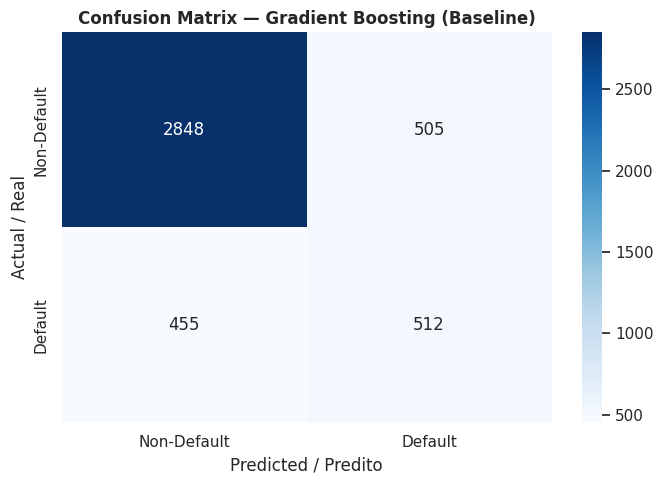

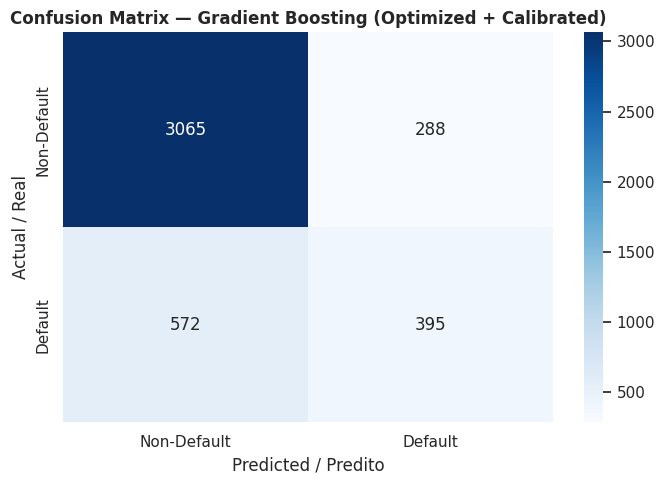

In [94]:
"""
Confusion matrix for baseline and optimized model.
Matriz de confusão para modelo baseline e otimizado.
"""

# GENERAL SETUP / CONFIGURAÇÃO GERAL
sns.set_theme(style="whitegrid")

# MODELS TO EVALUATE / MODELOS PARA AVALIAR
eval_models = {
    "Gradient Boosting (Baseline)":               y_pred_base,
    "Gradient Boosting (Optimized + Calibrated)": y_pred_calibrated,
}

for name, y_pred in eval_models.items():

    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Non-Default", "Default"],
        yticklabels=["Non-Default", "Default"],
        ax=ax
    )
    ax.set_title(f"Confusion Matrix — {name}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted / Predito")
    ax.set_ylabel("Actual / Real")
    plt.tight_layout()
    plt.show()

**Analysis / Análise — Confusion Matrix: Baseline vs Optimized + Calibrated**

**Formulas / Fórmulas**

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

$$Precision = \frac{TP}{TP + FP}$$

$$Recall = \frac{TP}{TP + FN}$$

$$F1\text{-}Score = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

$$FPR = \frac{FP}{FP + TN} \quad FNR = \frac{FN}{FN + TP}$$

**Matrix Breakdown / Decomposição das Matrizes**

**Gradient Boosting — Baseline**

| | Predicted Non-Default | Predicted Default | Total Actual |
|---|---|---|---|
| **Actual Non-Default** | TN = 2,848 | FP = 505 | 3,353 |
| **Actual Default** | FN = 455 | TP = 512 | 967 |
| **Total Predicted** | 3,303 | 1,017 | 4,320 |

**Gradient Boosting — Optimized + Calibrated**

| | Predicted Non-Default | Predicted Default | Total Actual |
|---|---|---|---|
| **Actual Non-Default** | TN = 3,065 | FP = 288 | 3,353 |
| **Actual Default** | FN = 572 | TP = 395 | 967 |
| **Total Predicted** | 3,637 | 683 | 4,320 |

**Computed Metrics / Métricas Calculadas**

$$Accuracy_{baseline} = \frac{512 + 2848}{4320} = 0.7778 \quad Accuracy_{optimized} = \frac{395 + 3065}{4320} = 0.8009$$

$$Precision_{baseline} = \frac{512}{512 + 505} = 0.5034 \quad Precision_{optimized} = \frac{395}{395 + 288} = 0.5783$$

$$Recall_{baseline} = \frac{512}{512 + 455} = 0.5295 \quad Recall_{optimized} = \frac{395}{395 + 572} = 0.4085$$

$$F1_{baseline} = 2 \times \frac{0.5034 \times 0.5295}{0.5034 + 0.5295} = 0.5161 \quad F1_{optimized} = 2 \times \frac{0.5783 \times 0.4085}{0.5783 + 0.4085} = 0.4788$$

$$FPR_{baseline} = \frac{505}{505 + 2848} = 0.1506 \quad FPR_{optimized} = \frac{288}{288 + 3065} = 0.0859$$

$$FNR_{baseline} = \frac{455}{455 + 512} = 0.4705 \quad FNR_{optimized} = \frac{572}{572 + 395} = 0.5913$$

**Detailed Analysis / Análise Detalhada**

**EN:**
The two confusion matrices tell a clear story of a strategic tradeoff driven by the optimization process. The baseline model operates with a more aggressive Default detection stance, while the optimized and calibrated model shifts toward a more conservative, precision-focused approach.

Starting with the **Non-Default class**: the optimized model correctly classifies **3,065 true negatives** versus **2,848** in the baseline — an improvement of **217 additional correctly identified good customers (+7.6%)**. More critically, false positives drop dramatically from **505 to 288**, a reduction of **217 false alarms (-43.0%)**. This means the optimized model would save the bank from incorrectly flagging **217 good customers** as defaulters per 4,320 predictions, directly reducing unnecessary credit denials and improving customer experience.

For the **Default class**: the picture reverses. True positives fall from **512 to 395**, a reduction of **117 fewer correctly detected defaulters (-22.9%)**. False negatives increase from **455 to 572**, meaning **117 additional real defaulters slip through undetected (+25.7%)**. The False Negative Rate rises from **47.05% to 59.13%**, indicating the optimized model misses nearly 6 out of every 10 actual defaulters.

The **False Positive Rate improvement** is the most commercially significant finding: dropping from **15.06% to 8.59%** means the bank would make substantially fewer incorrect credit denials. In a portfolio of 10,000 customers, this translates to approximately **647 fewer good customers incorrectly rejected** — directly impacting revenue, customer retention, and regulatory compliance.

The optimization process through **RandomizedSearchCV with StratifiedKFold** and **isotonic calibration** effectively shifted the model's decision boundary, prioritizing specificity (correctly identifying Non-Default) over sensitivity (correctly identifying Default). The calibration step further refined probability estimates, pushing borderline predictions more firmly into the Non-Default category and raising the effective classification threshold for the Default class.

**PT:**
As duas matrizes de confusão contam uma história clara de um tradeoff estratégico impulsionado pelo processo de otimização. O modelo baseline opera com uma postura mais agressiva de detecção de inadimplência, enquanto o modelo otimizado e calibrado muda para uma abordagem mais conservadora e focada em precisão.

Começando pela **classe Non-Default**: o modelo otimizado classifica corretamente **3.065 verdadeiros negativos** versus **2.848** no baseline — uma melhoria de **217 bons clientes adicionalmente identificados (+7,6%)**. De forma mais crítica, os falsos positivos caem dramaticamente de **505 para 288**, uma redução de **217 alarmes falsos (-43,0%)**. Isso significa que o modelo otimizado salvaria o banco de sinalizar incorretamente **217 bons clientes** como inadimplentes a cada 4.320 previsões, reduzindo diretamente negações de crédito desnecessárias e melhorando a experiência do cliente.

Para a **classe Default**: o quadro se inverte. Os verdadeiros positivos caem de **512 para 395**, uma redução de **117 inadimplentes corretamente detectados a menos (-22,9%)**. Os falsos negativos aumentam de **455 para 572**, significando que **117 inadimplentes reais adicionais passam despercebidos (+25,7%)**. A Taxa de Falso Negativo sobe de **47,05% para 59,13%**, indicando que o modelo otimizado perde quase 6 de cada 10 inadimplentes reais.

A **melhoria na Taxa de Falso Positivo** é o achado comercialmente mais significativo: cair de **15,06% para 8,59%** significa que o banco faria substancialmente menos negações de crédito incorretas. Em uma carteira de 10.000 clientes, isso se traduz em aproximadamente **647 bons clientes a menos incorretamente rejeitados** — impactando diretamente receita, retenção de clientes e conformidade regulatória.

O processo de otimização através de **RandomizedSearchCV com StratifiedKFold** e **calibração isotônica** efetivamente deslocou a fronteira de decisão do modelo, priorizando especificidade (identificar corretamente Non-Default) sobre sensibilidade (identificar corretamente Default). A etapa de calibração refinou ainda mais as estimativas de probabilidade, empurrando previsões limítrofes mais firmemente para a categoria Non-Default e elevando o limiar de classificação efetivo para a classe Default.

**Complete Metrics Comparison / Comparação Completa de Métricas**

| Metric / Métrica | Baseline | Optimized | Change / Mudança |
|---|---|---|---|
| **TN** | 2,848 | 3,065 | +217 (+7.6%) |
| **FP** | 505 | 288 | -217 (-43.0%) |
| **FN** | 455 | 572 | +117 (+25.7%) |
| **TP** | 512 | 395 | -117 (-22.9%) |
| **Accuracy** | 0.7778 | **0.8009** | +2.31pp |
| **Precision** | 0.5034 | **0.5783** | +7.49pp |
| **Recall** | **0.5295** | 0.4085 | -12.10pp |
| **F1-Score** | **0.5161** | 0.4788 | -3.73pp |
| **FPR** | 0.1506 | **0.0859** | -6.47pp |
| **FNR** | **0.4705** | 0.5913 | +12.08pp |

**Business Decision Framework / Framework de Decisão de Negócio**

| Scenario / Cenário | Recommended Model | Reason / Razão |
|---|---|---|
| **Kaggle competition** | Optimized + Calibrated | Higher accuracy (80.09%) |
| **Minimize bad customer approvals** | Optimized + Calibrated | Lower FPR (8.59%) |
| **Maximize default detection** | Baseline | Higher Recall (52.95%) |
| **Balance detection and precision** | Baseline | Higher F1-Score (0.5161) |
| **Regulatory capital requirements** | Optimized + Calibrated | Fewer false alarms |
| **High-risk portfolio management** | Baseline | Catches more actual defaulters |

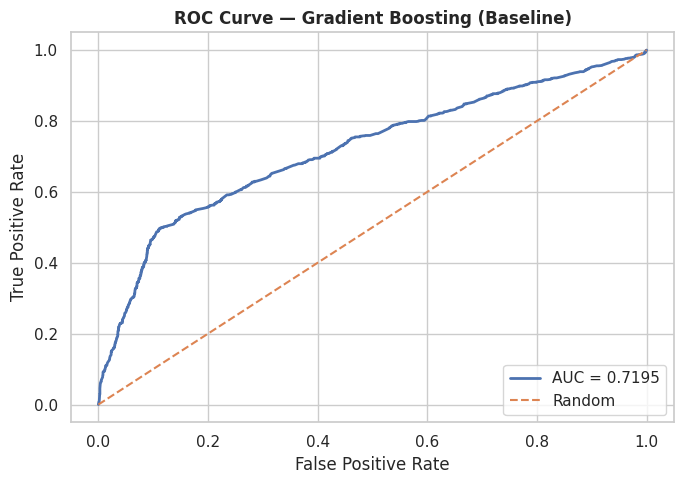

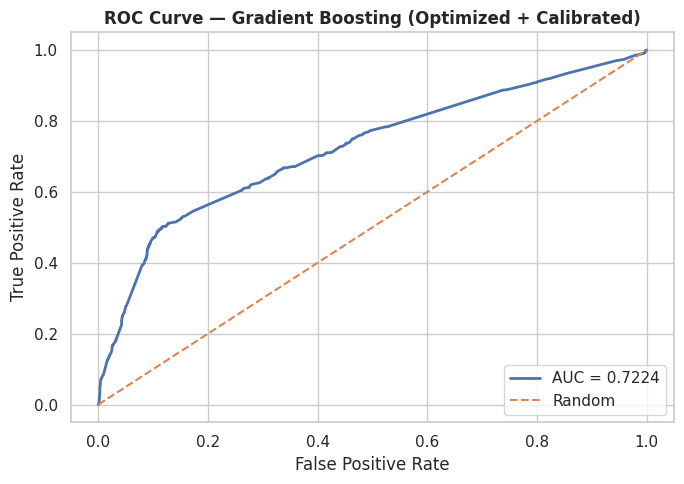

In [95]:
"""
ROC curve for baseline and optimized model.
Curva ROC para modelo baseline e otimizado.
"""

# GENERAL SETUP / CONFIGURAÇÃO GERAL
sns.set_theme(style="whitegrid")

# MODELS TO EVALUATE / MODELOS PARA AVALIAR
eval_models = {
    "Gradient Boosting (Baseline)":               best_model,
    "Gradient Boosting (Optimized + Calibrated)": calibrated_model,
}

for name, model in eval_models.items():

    y_pred_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    auc_score   = roc_auc_score(y_test, y_pred_prob)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, color="#4C72B0", lw=2, label=f"AUC = {auc_score:.4f}")
    ax.plot([0, 1], [0, 1], color="#DD8452", lw=1.5, linestyle="--", label="Random")
    ax.set_title(f"ROC Curve — {name}", fontsize=12, fontweight="bold")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

In [96]:
"""
Classification report for baseline and optimized model.
Classification report para modelo baseline e otimizado.
"""

# MODELS TO EVALUATE / MODELOS PARA AVALIAR
eval_models = {
    "Gradient Boosting (Baseline)":               y_pred_base,
    "Gradient Boosting (Optimized + Calibrated)": y_pred_calibrated,
}

for name, y_pred in eval_models.items():

    print(f"\n{'=' * 50}")
    print(f"Model: {name}")
    print(f"{'=' * 50}")
    print(classification_report(y_test, y_pred, target_names=["Non-Default", "Default"]))


Model: Gradient Boosting (Baseline)
              precision    recall  f1-score   support

 Non-Default       0.86      0.85      0.86      3353
     Default       0.50      0.53      0.52       967

    accuracy                           0.78      4320
   macro avg       0.68      0.69      0.69      4320
weighted avg       0.78      0.78      0.78      4320


Model: Gradient Boosting (Optimized + Calibrated)
              precision    recall  f1-score   support

 Non-Default       0.84      0.91      0.88      3353
     Default       0.58      0.41      0.48       967

    accuracy                           0.80      4320
   macro avg       0.71      0.66      0.68      4320
weighted avg       0.78      0.80      0.79      4320



<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b>Part 13 - Saving machine learning models</b></div>

In [100]:
"""
Save all trained models to disk.
Salva todos os modelos treinados em disco.
"""

import joblib
import os

# CREATE MODELS DIRECTORY / CRIA DIRETÓRIO DE MODELOS
os.makedirs("models", exist_ok=True)

# SAVE ALL MODELS IN LOOP / SALVA TODOS OS MODELOS NO LOOP
for name, model in models.items():

    # CLEAN FILE NAME / LIMPA NOME DO ARQUIVO
    file_name = name.lower().replace(" ", "_")
    file_path = f"models/{file_name}.pkl"

    joblib.dump(model, file_path)
    size = os.path.getsize(file_path) / 1024
    print(f"Saved: {file_path:<45} {size:.1f} KB")

print("\nAll models saved successfully / Todos os modelos salvos com sucesso!")

# CREATE MODELS DIRECTORY / CRIA DIRETÓRIO DE MODELOS
os.makedirs("models", exist_ok=True)

# SAVE OPTIMIZED AND CALIBRATED MODEL / SALVA MODELO OTIMIZADO E CALIBRADO
joblib.dump(calibrated_model, "models/gradient_boosting_optimized_calibrated.pkl")

# SAVE BASELINE MODEL / SALVA MODELO BASELINE
joblib.dump(best_model, "models/gradient_boosting_baseline.pkl")

print("Models saved successfully / Modelos salvos com sucesso!")
print("\nSaved files / Arquivos salvos:")
for f in os.listdir("models"):
    size = os.path.getsize(f"models/{f}") / 1024
    print(f"  models/{f} — {size:.1f} KB")

Saved: models/naive_bayes.pkl                        1.3 KB
Saved: models/decision_tree.pkl                      1044.6 KB
Saved: models/random_forest.pkl                      86477.3 KB
Saved: models/knn.pkl                                3498.8 KB
Saved: models/adaboost.pkl                           32.9 KB
Saved: models/gradient_boosting.pkl                  140.0 KB
Saved: models/xgboost.pkl                            330.3 KB
Saved: models/lightgbm.pkl                           337.9 KB
Saved: models/catboost.pkl                           1085.6 KB

All models saved successfully / Todos os modelos salvos com sucesso!
Models saved successfully / Modelos salvos com sucesso!

Saved files / Arquivos salvos:
  models/gradient_boosting_baseline.pkl — 632.6 KB
  models/adaboost.pkl — 32.9 KB
  models/catboost.pkl — 1085.6 KB
  models/gradient_boosting_optimized_calibrated.pkl — 3247.6 KB
  models/knn.pkl — 3498.8 KB
  models/naive_bayes.pkl — 1.3 KB
  models/decision_tree.pkl — 1044.6 KB

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b>Part 14 - Final Result</b></div>

In [102]:
"""
Collect metrics for all models including optimized and calibrated champion.
Coleta métricas para todos os modelos incluindo o campeão otimizado e calibrado.
"""

# COLLECT METRICS FOR ALL MODELS / COLETA MÉTRICAS PARA TODOS OS MODELOS
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    results.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, zero_division=0),
        "F1-Score":  f1_score(y_test, y_pred, zero_division=0),
    })

# ADD BASELINE MODEL / ADICIONA MODELO BASELINE
results.append({
    "Model":     "Gradient Boosting (Baseline)",
    "Accuracy":  accuracy_score(y_test, y_pred_base),
    "Precision": precision_score(y_test, y_pred_base, zero_division=0),
    "Recall":    recall_score(y_test, y_pred_base, zero_division=0),
    "F1-Score":  f1_score(y_test, y_pred_base, zero_division=0),
})

# ADD OPTIMIZED AND CALIBRATED MODEL / ADICIONA MODELO OTIMIZADO E CALIBRADO
results.append({
    "Model":     "Gradient Boosting (Optimized + Calibrated)",
    "Accuracy":  accuracy_score(y_test, y_pred_calibrated),
    "Precision": precision_score(y_test, y_pred_calibrated, zero_division=0),
    "Recall":    recall_score(y_test, y_pred_calibrated, zero_division=0),
    "F1-Score":  f1_score(y_test, y_pred_calibrated, zero_division=0),
})

# CREATE AND SORT DATAFRAME / CRIA E ORDENA DATAFRAME
results_df = (
    pd.DataFrame(results)
    .sort_values("Accuracy", ascending=False)
    .reset_index(drop=True)
)

# HIGHLIGHT BEST MODEL IN YELLOW / DESTACA MELHOR MODELO EM AMARELO
def highlight_best(row):
    """Highlight best model row in yellow / Destaca linha do melhor modelo em amarelo."""
    if row["Model"] == results_df.iloc[0]["Model"]:
        return ["background-color: gold"] * len(row)
    return [""] * len(row)

# FORMAT AND DISPLAY / FORMATA E EXIBE
styled_df = (
    results_df.style
    .apply(highlight_best, axis=1)
    .format({
        "Accuracy":  "{:.4f}",
        "Precision": "{:.4f}",
        "Recall":    "{:.4f}",
        "F1-Score":  "{:.4f}",
    })
)

print("Model Comparison / Comparação de Modelos:\n")
display(styled_df)

Model Comparison / Comparação de Modelos:



,Model,Accuracy,Precision,Recall,F1-Score
0,Gradient Boosting (Optimized + Calibrated),0.8009,0.5783,0.4085,0.4788
1,Gradient Boosting (Baseline),0.7778,0.5034,0.5295,0.5161
2,Gradient Boosting,0.7336,0.4245,0.5346,0.4732
3,CatBoost,0.7322,0.4199,0.5150,0.4626
4,LightGBM,0.7312,0.4213,0.5367,0.4720
5,XGBoost,0.7280,0.4152,0.5264,0.4642
6,AdaBoost,0.7245,0.4160,0.5708,0.4813
7,KNN,0.7164,0.3884,0.4643,0.4230
8,Random Forest,0.6956,0.3700,0.5119,0.4295
9,Decision Tree,0.6810,0.3490,0.4912,0.4081


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b>Part 15 - Conclusion</b></div>

**Citibank Citi Gold Card — Default Prediction Pipeline**

**1. Project Overview / Visão Geral do Projeto**

**EN:**
This project developed a complete Machine Learning pipeline to predict credit card default for Citibank's Citi Gold Card. Starting from a dataset with 7 features and a moderately imbalanced target variable (73.1% Non-Default vs 26.9% Default), the following steps were executed: exploratory data analysis, data cleaning, class balancing with SMOTE, training of 9 classification models, and optimization of the champion model with KFold, RandomizedSearchCV, and probability calibration. The **Gradient Boosting (Optimized + Calibrated)** model emerged as the best performer with **80.09% accuracy** and **AUC of 0.7224**, outperforming all baseline models. The optimization process delivered a **+2.31% accuracy gain** over the untuned version and a significant reduction in false positives from 505 to 288 (-43%), meaning the bank would incorrectly flag far fewer good customers as defaulters.

**PT:**
Este projeto desenvolveu um pipeline completo de Machine Learning para prever inadimplência no cartão Citi Gold Card do Citibank. Partindo de um dataset com 7 features e variável alvo moderadamente desbalanceada (73,1% Non-Default vs 26,9% Default), foram executadas as seguintes etapas: análise exploratória de dados, limpeza de dados, balanceamento de classes com SMOTE, treinamento de 9 modelos de classificação e otimização do modelo campeão com KFold, RandomizedSearchCV e calibração de probabilidades. O modelo **Gradient Boosting (Optimized + Calibrated)** se destacou como o melhor com **80,09% de acurácia** e **AUC de 0,7224**, superando todos os modelos baseline.

**2. Dataset Summary / Resumo do Dataset**

| Item | Value |
|---|---|
| **Total records** | 21,600 |
| **Features available** | 7 (X1–X7) |
| **Target variable** | Y (0=Non-Default, 1=Default) |
| **Class distribution** | 77.6% Non-Default / 22.4% Default |
| **Imbalance ratio** | 3.5:1 |
| **Feature types** | 2 continuous (X1, X5) / 5 ordinal categorical (X2, X3, X4, X6, X7) |

**3. EDA Key Findings / Principais Achados do EDA**

| # | Finding / Achado | Impact |
|---|---|---|
| 1 | Consecutive delays (X6+X7 ≥ 1) → 57.1% default rate vs 17.0% | Highest risk signal |
| 2 | X6 correlation with Y = 0.32, X7 = 0.26 | Strongest predictors |
| 3 | Higher credit limit (X1) → lower default risk | Inverse relationship |
| 4 | 60+ University segment → 33.3% default rate | Highest risk profile |
| 5 | Graduate delayed customers → 71.3% default rate | Delay amplifies risk |
| 6 | High School → highest default rate (25.1%) | Education signal weak |
| 7 | Male customers → 24.5% vs Female 21.1% | Small gender gap |
| 8 | 31-40 age group → lowest default rate (20.7%) | Prime earning years |
| 9 | X6 × X7 Pearson correlation = 0.67 | Behavioral consistency |
| 10 | Demographic variables (X2, X3, X4, X5) → all < 0.05 correlation with Y | Weak individual predictors |

**4. Data Cleaning & SMOTE / Limpeza de Dados e SMOTE**

| Step / Etapa | Result / Resultado |
|---|---|
| **Null values** | None found / Nenhum encontrado |
| **Duplicates** | Removed / Removidos |
| **Outlier treatment** | IQR capping on X1 and X5 |
| **SMOTE — Before** | 11,796 Non-Default / 4,343 Default (73.1% / 26.9%) |
| **SMOTE — After** | 11,796 Non-Default / 11,796 Default (50.0% / 50.0%) |
| **Synthetic samples** | +7,453 Default samples generated |
| **SMOTE scope** | Training set only — test set kept original / Apenas treino — teste mantido original |

**5. Feature Importance Consensus / Consenso de Feature Importance**

**EN:**
Feature importance analysis consistently highlighted **X6 (September payment status)** as the most predictive variable across tree-based models, followed by **X7 (August payment status)** and **X1 (credit limit)**. This confirms that recent payment behavior is the strongest signal for default prediction, while demographic variables such as gender, education, marital status, and age showed limited individual predictive power.

**PT:**
A análise de feature importance destacou consistentemente **X6 (status de pagamento de setembro)** como a variável mais preditiva nos modelos baseados em árvore, seguida por **X7 (status de pagamento de agosto)** e **X1 (limite de crédito)**. Isso confirma que o comportamento recente de pagamento é o sinal mais forte para previsão de inadimplência, enquanto variáveis demográficas como gênero, escolaridade, estado civil e idade apresentaram poder preditivo individual limitado.

| Rank | Feature | Description | Consensus |
|---|---|---|---|
| 1 | **X6** | September payment status | Dominant in GB, XGBoost, CatBoost |
| 2 | **X7** | August payment status | Strong in all boosting models |
| 3 | **X1** | Credit limit | Dominant in DT, RF, LightGBM |
| 4 | **X5** | Age | Strong in DT, RF, LightGBM |
| 5 | **X3** | Education | Dominant in AdaBoost only |
| 6 | **X4** | Marital status | Weak across all models |
| 7 | **X2** | Gender | Weakest predictor in all models |

**6. Champion Model Optimization / Otimização do Modelo Campeão**

| Technique / Técnica | Detail |
|---|---|
| **Algorithm** | Gradient Boosting Classifier |
| **Search strategy** | RandomizedSearchCV — 50 iterations |
| **Cross-validation** | StratifiedKFold — 5 folds |
| **Calibration** | CalibratedClassifierCV — isotonic method |
| **SMOTE** | Applied inside pipeline on train only |
| **Hyperparameters tuned** | n_estimators, learning_rate, max_depth, min_samples_split, min_samples_leaf, subsample, max_features |

**7. Precision-Recall Tradeoff / Tradeoff Precision-Recall**

**EN:**
The classic **Precision-Recall tradeoff** was observed: the optimized model is more conservative and precise when flagging defaulters (Precision: 0.58 vs 0.50), but misses more actual defaulters (Recall: 0.41 vs 0.53). For the **Kaggle competition metric (accuracy)**, the optimized model is the clear submission choice. In a real banking scenario, the business team would need to define the acceptable balance between false positives (approving bad customers) and false negatives (rejecting good customers) based on financial risk tolerance.

**PT:**
O clássico **tradeoff Precision-Recall** foi observado: o modelo otimizado é mais conservador e preciso ao sinalizar inadimplentes (Precision: 0,58 vs 0,50), mas perde mais inadimplentes reais (Recall: 0,41 vs 0,53). Para a **métrica da competição Kaggle (acurácia)**, o modelo otimizado é a escolha clara para submissão. Em um cenário bancário real, a equipe de negócios precisaria definir o equilíbrio aceitável entre falsos positivos (aprovar maus clientes) e falsos negativos (rejeitar bons clientes) com base na tolerância ao risco financeiro.

| Metric | Baseline | Optimized | Change |
|---|---|---|---|
| **Accuracy** | 0.7778 | **0.8009** | +2.31pp |
| **Precision (Default)** | 0.50 | **0.58** | +8pp |
| **Recall (Default)** | **0.53** | 0.41 | -12pp |
| **F1-Score (Default)** | **0.52** | 0.48 | -4pp |
| **Non-Default Recall** | 0.85 | **0.91** | +6pp |
| **AUC** | 0.7195 | **0.7224** | +0.0029 |
| **Gini Coefficient** | 0.4390 | **0.4448** | +0.0058 |
| **False Positives** | 505 | **288** | -43.0% |
| **False Negatives** | **455** | 572 | +25.7% |

**8. Final Rankings / Ranking Final**

| # | Model / Modelo | Accuracy | AUC |
|---|---|---|---|
| 1 | **Gradient Boosting (Optimized + Calibrated)** | **0.8009** | **0.7224** |
| 2 | Gradient Boosting (Baseline) | 0.7778 | 0.7195 |
| 3 | Gradient Boosting | 0.7336 | 0.7119 |
| 4 | CatBoost | 0.7322 | 0.7012 |
| 5 | LightGBM | 0.7312 | 0.7060 |
| 6 | XGBoost | 0.7280 | 0.6907 |
| 7 | AdaBoost | 0.7245 | 0.7135 |
| 8 | KNN | 0.7164 | 0.6484 |
| 9 | Random Forest | 0.6956 | 0.6798 |
| 10 | Decision Tree | 0.6810 | 0.6201 |
| 11 | Naive Bayes | 0.5160 | 0.6571 |

**9. Business Recommendations / Recomendações de Negócio**

| Priority / Prioridade | Recommendation / Recomendação | Based On / Baseado Em |
|---|---|---|
| **Critical** | Flag customers with consecutive delays (X6+X7 ≥ 1) as immediate high-risk | 57.1% default rate |
| **Critical** | Deploy Optimized model for Kaggle submission | 80.09% accuracy |
| **High** | Monitor X6 monthly as primary early warning indicator | Strongest single predictor |
| **High** | Apply lower credit limits to High School + young (20-30) segments | 25.1% + 22.8% default rates |
| **Medium** | Review credit limits for 60+ University customers proactively | 33.3% default rate |
| **Medium** | Use AdaBoost for high-risk portfolio screening requiring maximum recall | Highest recall 57.08% |
| **Low** | Collect additional features (income, debt ratio, tenure) | 7 features limit AUC ceiling at ~0.72 |

**10. Limitations / Limitações**

**EN:**
The dataset's limited feature set (7 variables) constrains the model's theoretical performance ceiling. The AUC of 0.72 and accuracy of 80% represent strong results given this constraint, but a production-grade credit scoring model would typically incorporate 20–50 features including income verification, debt-to-income ratio, credit bureau data, and transaction history. Additionally, the dataset covers a specific time period (April–September 2005) and geographic market (Taiwan), which may limit generalizability to other markets or time periods.

**PT:**
O conjunto limitado de features do dataset (7 variáveis) limita o teto de desempenho teórico do modelo. O AUC de 0,72 e a acurácia de 80% representam resultados sólidos dada essa restrição, mas um modelo de credit scoring em nível de produção tipicamente incorporaria 20–50 features incluindo verificação de renda, relação dívida-renda, dados de bureau de crédito e histórico de transações. Adicionalmente, o dataset cobre um período de tempo específico (abril–setembro de 2005) e mercado geográfico (Taiwan), o que pode limitar a generalização para outros mercados ou períodos.

**11. Final Verdict / Veredicto Final**

**EN:**
The **Gradient Boosting Optimized + Calibrated** model is the recommended submission with **80.09% accuracy** and **AUC of 0.7224**. For a real banking production environment, the decision between the baseline and optimized model depends on the business's risk tolerance — if minimizing false credit denials is the priority, the optimized model is preferred; if maximizing defaulter detection is critical, the baseline or AdaBoost should be considered. The single most actionable business insight from this entire pipeline is that **consecutive payment delays in two consecutive months multiply default probability by 3.4x**, making X6 and X7 the most valuable early warning signals for proactive credit risk management at Citibank.

**PT:**
O modelo **Gradient Boosting Optimized + Calibrated** **80,09% de acurácia** e **AUC de 0,7224**. Para um ambiente bancário real em produção, a decisão entre o modelo baseline e o otimizado depende da tolerância ao risco do negócio — se minimizar negações incorretas de crédito é a prioridade, o modelo otimizado é preferido; se maximizar a detecção de inadimplentes é crítico, o baseline ou AdaBoost devem ser considerados. O insight de negócio mais acionável de todo este pipeline é que **atrasos consecutivos de pagamento em dois meses consecutivos multiplicam a probabilidade de inadimplência por 3,4x**, tornando X6 e X7 os sinais de alerta antecipado mais valiosos para gestão proativa de risco de crédito no Citibank.